In [7]:


from km3astro.coord import local_event
from astropy.time import Time
import astropy.units as u

time = Time(1567036818.2,format='unix')
detector_location = 'arca'
theta = 1.0*u.rad
phi = 1.0*u.rad
event_location = local_event(theta.to_value(),phi.to_value(),time,detector_location)

In [8]:
from h5py import File, Group
from astropy.table import Table
from astropy.time import Time
from astropy.io.misc.hdf5 import read_table_hdf5
import astropy.units as u
from astropy.coordinates import SkyCoord
import km3io.definitions as kd

from km3astro.coord import local_event
from km3astro import sources

def load_hdf5_tables(file_path):
    """
    Load an HDF5 file and assign tables to an object.
    The function expects a file that is generated with astropy_hdf5_from_root() and has the paths 'HEADER','ID','RECO_EVENTS' and optionally 'MC_EVENTS'

    Parameters
    ----------
    file_path : str
        Path to the HDF5 file.

    Returns
    -------
    object
        An object containing attributes header_table, id_table, reco_table, and optionally mc_table.
    """
    tables = type("Tables", (), {})()  # Creating an empty object

    try:
        with File(file_path, "r") as h5file:
            tables.header_table = read_table_hdf5(h5file, path="HEADER")
            tables.id_table = read_table_hdf5(h5file, path="ID")
            if "RECO/RECO_EVENTS" in h5file:
                print("RECO_EVENTS is present")
                tables.reco_table = read_table_hdf5(h5file, path="RECO/RECO_EVENTS")

            else:
                print("RECO_EVENTS is NOT present")
                # tables.reco_table = read_table_hdf5(h5file, path='RECO/RECO_EVENTS')
            if "MC/MC_EVENTS" in h5file:
                tables.mc_table = read_table_hdf5(h5file, path="MC/MC_EVENTS")
                print("MC_EVENTS is present")
            else:
                print("MC_EVENTS is NOT present")
                # tables.mc_table = read_table_hdf5(h5file, path='MC/MC_EVENTS')
                tables.mc_table = None
    except Exception as e:
        print(f"Error loading tables from {file_path}: {e}")

    return tables

/usr/lib64/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [9]:
filepath = "hdf5TestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013767.jchain.aashower.311.h5"
tables = load_hdf5_tables(filepath)

RECO_EVENTS is present
MC_EVENTS is present


In [19]:
import numpy as np
phi = np.array(tables.reco_table['phi_detectorframe'])

print(phi)

[5.43497954 0.26918743 5.7877956  ... 4.66367377 0.89896453 2.00103982]


In [1]:
import psr.src.plens

from astropy.units import day

ModuleNotFoundError: No module named 'psr'

## Creating hdf5 source spec files

In [ ]:
import h5py
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np

# Define the source information
source_name = "Cygnus X-3"
ra = 255.2038 * u.deg  # Right Ascension
dec = -41.6560 * u.deg  # Declination
skycoord = SkyCoord(ra=ra, dec=dec, frame='icrs')

# Other source information
P_orb = 10.447292   # in days
T_pi2 = 2452298.51790 
axsini = 106.157  # light-seconds
e = 0.1075
omega = 92.69

other_info = {
    "Period_Deriv": -9.7400e-08,
    "Egress": 0.07,
    "Ingress": 0.91
}

# Create an HDF5 file and write the data
folder_path = '/home/hpc/capn/capn107h/software/hdf5SourceFiles/'
file_path = folder_path + source_name + '.h5'
with h5py.File(file_path, 'w') as f:
    # Store the source name
    f.create_dataset('source_name', data=source_name)

    # Store the SkyCoord information
    coord_group = f.create_group('skycoord')
    coord_group.create_dataset('ra', data=skycoord.ra.deg)
    coord_group.create_dataset('dec', data=skycoord.dec.deg)
    coord_group.create_dataset('frame', data=skycoord.frame.name)

    # Store the orbital period
    f.create_dataset('P_orb', data=P_orb)
    f.create_dataset('T_pi2', data=T_pi2)
    f.create_dataset('axsini', data=axsini)
    f.create_dataset('e', data=e)
    f.create_dataset('omega', data=omega)
    # Store additional information
    for key, value in other_info.items():
        f.create_dataset(key, data=value)

print(f"Data successfully written to {source_name}.h5"  )

Data successfully written to OAO_1657-415.h5


In [7]:
import h5py
from astropy.coordinates import SkyCoord
from astropy import units as u

# Open the HDF5 file and read the data
with h5py.File('pulsar_data.h5', 'r') as f:
    # Read the source name
    source_name = f['source_name'][()]
    print("Source Name:", source_name)

    # Read the SkyCoord information
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    frame = f['skycoord/frame'][()]
    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    print("SkyCoord:", skycoord)

    # Read the orbital period
    orbital_period = f['orbital_period'][()]
    print("Orbital Period:", orbital_period, "days")

    # Read additional information
    other_info = {key: f[key][()] for key in f.keys() if key not in ['source_name', 'skycoord', 'orbital_period']}
    print("Other Information:", other_info)

Source Name: b'Vela X-1'
SkyCoord: <SkyCoord (ICRS): (ra, dec) in deg
    (135.5286, 40.5547)>
Orbital Period: 8.964214 days
Other Information: {'Tpi2': 2459115.02085, 'axsini': 113.105, 'distance': 4.56, 'e': 0.0872, 'flux': 1.23, 'omega': 162.33}


In [6]:
import h5py
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5


file = h5py.File('/home/hpc/capn/capn107h/software/eventlistTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_jmuon-recotype_0.0-energythreshold_eventlist.hdf5')
timetable = read_table_hdf5(file)
corrected_file = h5py.File('/home/hpc/capn/capn107h/software/correctedeventlistTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_jmuon-recotype_0.0-energythreshold_eventlist_corrected.hdf5')
corrected_timetable = read_table_hdf5(corrected_file)
injected_file = h5py.File('/home/hpc/capn/capn107h/software/injectedsignalTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_jmuon-recotype_0.0-energythreshold_eventlist_corrected_1.-signal_mvm.hdf5')
injected_timetable = read_table_hdf5(injected_file)
combined_file = h5py.File('/home/hpc/capn/capn107h/software/combinedTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013_combined_eventlist.h5')
combined_timetable = read_table_hdf5(combined_file)
combined_injected_file = h5py.File('/home/hpc/capn/capn107h/software/combinedTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013_combined_eventlist_injected.h5')
combined_injected_timetable = read_table_hdf5(combined_injected_file)

OSError: Unable to open file (unable to open file: name = '/home/hpc/capn/capn107h/software/combinedTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013_combined_eventlist.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [8]:
combined_injected_file = h5py.File('/home/hpc/capn/capn107h/software/combinedeventlistTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr0001328_combined_eventlist.h5')
combined_injected_timetable = read_table_hdf5(combined_injected_file)

In [9]:
#print(timetable)
#print(corrected_timetable)
#print(injected_timetable)
#print(combined_timetable)
print(combined_injected_timetable)

       time       
------------------
 1663858450.285938
 1663858451.435483
1663858451.8320198
  1663858454.41879
 1663858454.436413
1663858454.5156977
1663858454.5592012
1663858455.4863026
1663858456.3405101
  1663858457.89233
               ...
1663880031.9072762
 1663880031.964079
 1663880032.178021
1663880033.9243202
 1663880034.635185
  1663880034.66098
1663880036.6407802
1663880036.8715694
1663880037.3832262
 1663880038.712034
 1663880038.961382
Length = 22562 rows


In [21]:
import matplotlib.pyplot as plt
from astropy.visualization import quantity_support, time_support
import numpy as np
quantity_support()
time_support()
#print(timetable['time'])
#plt.plot(timetable['time'])

#counts, bins = np.histogram(timetable['time'])

<astropy.visualization.time.time_support.<locals>.MplTimeConverter at 0x7fad425b0668>

11067
11067


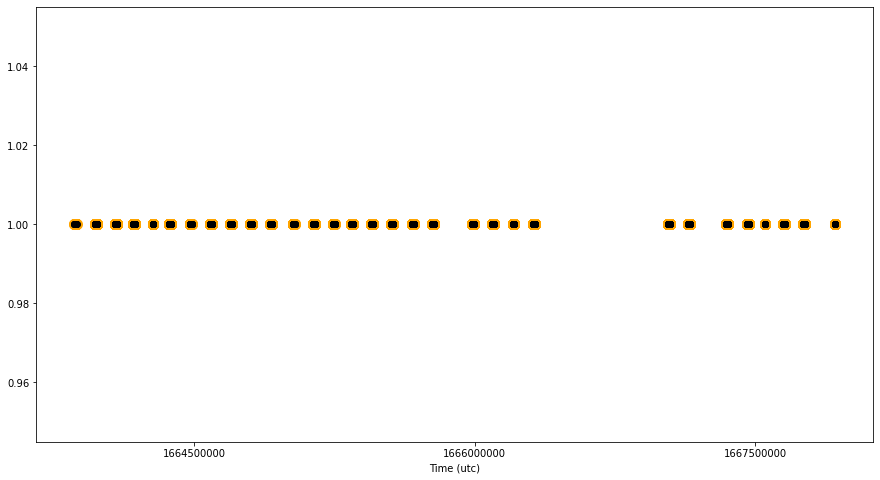

In [22]:
print(len(combined_injected_timetable['time']))
print(len(combined_timetable['time']))

fig, ax = plt.subplots(figsize=(15,8))

#ax.scatter(combined_timetable['time'],np.full_like(np.array(combined_timetable['time']),1),c = 'firebrick')
ax.scatter(combined_injected_timetable['time'],np.full_like(np.array(combined_injected_timetable['time']),1),lw=5,c = 'orange')
ax.scatter(combined_timetable['time'],np.full_like(np.array(combined_timetable['time']),1),c='k')


364
364


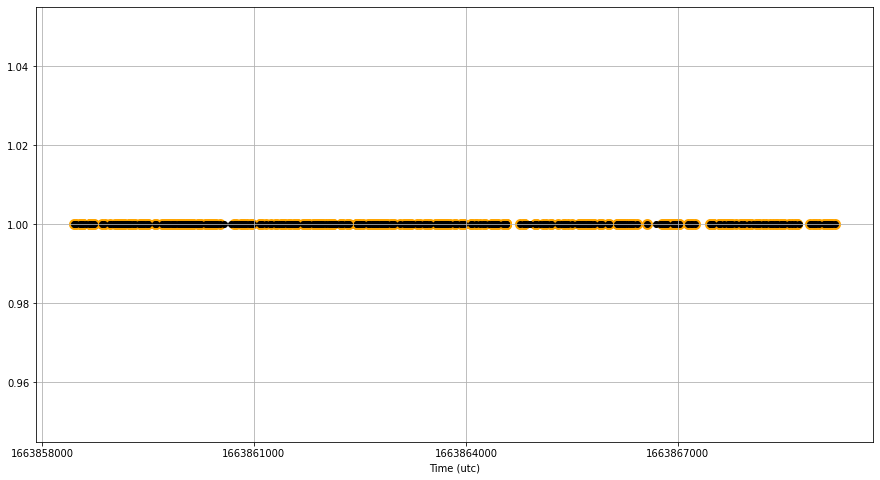

In [24]:
print(len(injected_timetable['time']))
print(len(corrected_timetable['time']))

fig, ax = plt.subplots(figsize=(15,8))

#ax.scatter(combined_timetable['time'],np.full_like(np.array(combined_timetable['time']),1),c = 'firebrick')
ax.scatter(injected_timetable['time'],np.full_like(np.array(injected_timetable['time']),1),lw=5,c = 'orange')
ax.scatter(corrected_timetable['time'],np.full_like(np.array(corrected_timetable['time']),1),c='k')
ax.grid()
#ax.set_xlim([])

In [2]:
import h5py

def inspect_hdf5_file(file_path):
    with h5py.File(file_path, 'r') as f:
        def print_attrs(name, obj):
            print(name)
            for key, val in obj.attrs.items():
                print("    %s: %s" % (key, val))
        f.visititems(print_attrs)

# Example usage
inspect_hdf5_file('../../epochfoldingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11_jmuon-recotype_0.0-energythreshold_eventlist_corrected_1.-signal_mvm_epochfolding_1.001.hdf5')


ef_profile
ef_profile/phase_bins
ef_profile/profile
ef_profile/profile_err


In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_hdf5_data(file_path):
    data = {}
    with h5py.File(file_path, 'r') as f:
        def extract_data(name, obj):
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[()]
        
        f.visititems(extract_data)
    
    return data

def plot_data(data):
    for name, values in data.items():
        plt.figure()
        plt.plot(values)
        plt.title(name)
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.show()

# Example usage
file_path = '../../epochfoldingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11_jmuon-recotype_0.0-energythreshold_eventlist_corrected_1.-signal_mvm_epochfolding_1.0.hdf5'
data = load_hdf5_data(file_path)

# Print available datasets
for name in data:
    print(f"Dataset: {name}, Shape: {data[name].shape}")

# Plot data
plot_data(data)


OSError: Unable to open file (unable to open file: name = '../../epochfoldingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11_jmuon-recotype_0.0-energythreshold_eventlist_corrected_1.-signal_mvm_epochfolding_1.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [10]:
import numpy as np
from stingray.pulse.search import epoch_folding_search, z_n_search
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (10, 6)

In [11]:
def sinusoid(times, frequency, baseline, amplitude, phase):
    return baseline + amplitude * np.sin(2 * np.pi * (frequency * times + phase))

In [3]:
from stingray import Lightcurve

period = 1.203501
mean_countrate = 50
pulsed_fraction = 0.2
bin_time = 0.1
obs_length = 3000

t = np.arange(0, obs_length, bin_time)

# The continuous light curve
counts = sinusoid(t, 1 / period, mean_countrate,
                  0.5 * mean_countrate * pulsed_fraction, 0) * bin_time
lc = Lightcurve(t, counts, gti=[[-bin_time / 2, obs_length + bin_time / 2]],
                dt=bin_time)

In [4]:
from stingray.events import EventList

# use the light curve above to simulate an event list for this pulsar.
events = EventList()
events.simulate_times(lc)

print(len(events.time))

149871


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/stingray/pulse/search.py:332: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.subplot()


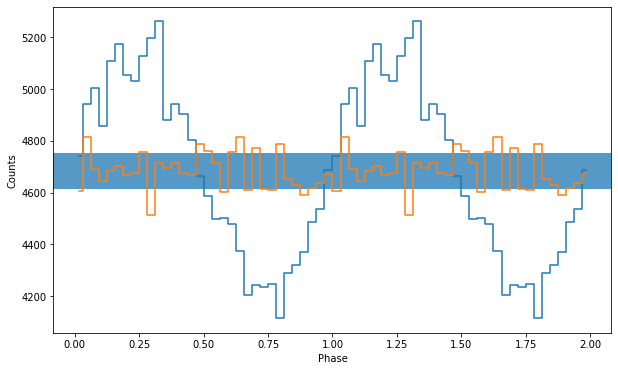

In [5]:
from stingray.pulse.pulsar import fold_events
from stingray.pulse.search import plot_profile
nbin = 32

ph, profile, profile_err = fold_events(events.time, 1/period, nbin=nbin)
_ = plot_profile(ph, profile)

ph, profile, profile_err = fold_events(events.time, 1/1.1, nbin=nbin)
_ = plot_profile(ph, profile)

In [19]:
print(np.array(combined_injected_timetable['time'].value))

[1.66385845e+09 1.66385845e+09 1.66385845e+09 ... 1.66388004e+09
 1.66388004e+09 1.66388004e+09]


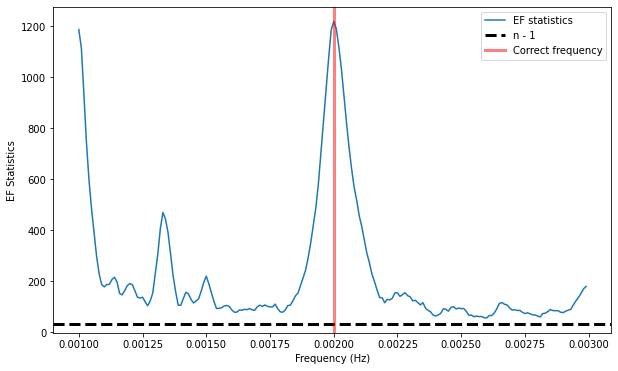

In [22]:
# We will search for pulsations over a range of frequencies around the known pulsation period.
df_min = 1/obs_length
oversampling=15
df = df_min / oversampling



frequencies = np.arange(0.001, 0.003, 0.00001)

freq, efstat = epoch_folding_search(np.array(combined_injected_timetable['time'].value), frequencies, nbin=nbin)
 
# ---- PLOTTING --------
plt.figure()
plt.plot(freq, efstat, label='EF statistics')
plt.axhline(nbin - 1, ls='--', lw=3, color='k', label='n - 1')
plt.axvline(0.002, lw=3, alpha=0.5, color='r', label='Correct frequency')
plt.xlabel('Frequency (Hz)')
plt.ylabel('EF Statistics')
_ = plt.legend()

## Looking at separations in a map

In [13]:
from km3io import OfflineReader
import awkward as ak

from km3astro import io

import os

import time
from h5py import File, Group

# import h5py

import awkward as ak
import numpy as np

# from numpy import array, full_like, transpose, uint64

from km3io import offline
from km3io import tools
import km3io.definitions as kd
import datetime
import astropy.units as u
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5
rootpath = '/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/electron/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root'
rootfile = OfflineReader(rootpath)

# Test check_for_mc function
is_mc = io.check_for_mc(rootfile)
print(f"is_mc: {is_mc}")



def root_to_hdf52(
    file_path,
    reco_types=["jmuon", "aashower", "jshower", "dusjshower"],
    output_file=None,
    event_ids_start=0,
):
    """
    Load a KM3NeT offline file, process it to extract high-level data that is relevant for astrophysical analysis in various astropy tables, and store them in an HDF5 file.

    Parameters
    ----------
    file_path : str
        Path to the input file.
    reco_types : list of str, optional
        List of reconstruction types. Allowed types: 'jmuon','jshower','aashower','dusjshower'.
        Default: ['jmuon','aashower','jshower','dusjshower']
    h5path : str, optional
        Path for storing the HDF5 file. Default: "OutputTables/"
    event_ids_start : int, optional
        Starting event ID. Default: 0

    Returns
    -------
    None
    """
    start_time = time.time()

    # Accessing the filename of the root file in order to match the name of the hdf5 file that gets created
    folder_path, file_name = os.path.split(file_path)
    file_name = os.path.splitext(file_name)[0]
    if output_file == None:
        combined_table_path = file_name + ".h5"
    else:
        combined_table_path = output_file
    # Loading offline data with the km3io OfflineReader
    OfflineObject = offline.OfflineReader(file_path)

    # Checking if the data contains mc information that can be written or not
    is_mc_data = io.check_for_mc(OfflineObject)

    # Generating the individual tables
    header_table = io.dump_header(OfflineObject)
    print("header_table created...")
    id_table, event_ids, timeslices = io.generate_id_table(OfflineObject, event_ids_start)
    print("id_table created...")
    reco_table = io.generate_reco_table(OfflineObject, event_ids, timeslices, reco_types)
    print("reco_table created...")
    if is_mc_data:
        print("is_mc_data == True")
        mc_table = io.generate_mc_table(OfflineObject, event_ids)
        print("mc_table created...")
    else: mc_table = None

    # Writing the tables to a hdf5 file
    with File(combined_table_path, "w") as h5file:
        reco_grp = h5file.create_group("RECO")
        write_table_hdf5(header_table, h5file, path="HEADER", serialize_meta=True)
        write_table_hdf5(id_table, h5file, path="ID", serialize_meta=True)
        write_table_hdf5(reco_table, reco_grp, path="RECO_EVENTS", serialize_meta=True)
        if is_mc_data is True:
            mc_grp = h5file.create_group("MC")
            write_table_hdf5(mc_table, mc_grp, path="MC_EVENTS", serialize_meta=True)
    print(f"File written: {combined_table_path}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total time: {elapsed_time:.3f} seconds")

hdf52file = root_to_hdf52(rootpath)

The file contains MC-generated data.
is_mc: True
The file contains MC-generated data.
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
is_mc_data == True
mc_table created...
File written: mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5
Total time: 6.124 seconds


In [14]:
file = io.load_hdf5_tables('/home/hpc/capn/capn107h/software/hdf5TestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5')
blindfile = io.load_hdf5_tables('/home/hpc/capn/capn107h/software/datablindingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_blinded.h5')

Error loading tables from /home/hpc/capn/capn107h/software/hdf5TestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5: Unable to open file (unable to open file: name = '/home/hpc/capn/capn107h/software/hdf5TestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error loading tables from /home/hpc/capn/capn107h/software/datablindingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_blinded.h5: Unable to open file (unable to open file: name = '/home/hpc/capn/capn107h/software/datablindingTestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_blinded.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


In [15]:
print(file.reco_table['tracktime_utc'])
print(blindfile.reco_table['tracktime_utc'])

AttributeError: 'Tables' object has no attribute 'reco_table'

In [50]:
import h5py
import numpy as np
from km3astro import io
from km3astro import coord
filepath = '/home/hpc/capn/capn107h/software/hdf5TestOutput/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.h5'
filepath = '/home/hpc/capn/capn107h/software/psr/src/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5'
tables = io.load_hdf5_tables(filepath)

reco_types = tables.reco_table['rec_type']
times = tables.reco_table['tracktime_utc']
phi = tables.reco_table['phi_detectorframe']
theta = tables.reco_table['theta_detectorframe']


RECO_EVENTS is present
MC_EVENTS is present


In [ ]:
print(f"Events: {len(times)}")
print(f"Time for Event 0: {times[0]}")
print(f"Time for Event 24485: {times[-1]}")
t0 = times[0]
t1 = times[-1]
print(times[0])
print(type(times[0]))
print(t1)
tdiff = t1 - t0
print(f"Difference: {tdiff*24}")
print(f"Observation length: {np.max(times)-np.min(times)}")


Events: 24485
Time for Event 0: 1663858800.4756496
Time for Event 24485: 1663869599.2647626
1663858800.4756496
<class 'astropy.time.core.Time'>
1663869599.2647626
Difference: 2.999663642558607
Observation length: 0.12498598510660863


In [60]:

dt = 1663869599.2647626 - 1663858800.4756496 
dt/283

38.15826541711922

<SkyCoord (AltAz: obstime=[1.6638588e+09 1.6638588e+09 1.6638588e+09 ... 1.6638696e+09 1.6638696e+09
 1.6638696e+09], location=(4659367.06359501, 491551.18803167, 4309636.59580957) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [(359.95685405,  49.83980913), ( 94.11595916, -43.29548106),
     (162.01300614, -61.2533453 ), ..., ( 80.87471212,   1.80718919),
     (104.08306373,  -1.98386736), (143.8233502 ,  -5.16505576)]>
<SkyCoord (ICRS): (ra, dec) in deg
    [(232.78845469,  83.03440727), (354.96986128, -30.40938732),
     ( 28.25986956, -68.75902898), ..., ( 12.1930258 ,   7.7918056 ),
     (359.09380111, -11.77837846), (328.00253254, -40.72401078)]>


(array([ 40., 108., 143., 210., 251., 312., 317., 388., 464., 512., 574.,
        618., 653., 738., 750., 746., 781., 833., 796., 864., 880., 813.,
        859., 865., 849., 892., 853., 776., 781., 841., 744., 691., 633.,
        558., 550., 498., 425., 374., 336., 295., 259., 197., 192., 115.,
         70.,  41.]),
 array([  1.12923434,   4.9928623 ,   8.85649027,  12.72011823,
         16.5837462 ,  20.44737416,  24.31100213,  28.17463009,
         32.03825806,  35.90188602,  39.76551399,  43.62914195,
         47.49276992,  51.35639788,  55.22002585,  59.08365381,
         62.94728178,  66.81090974,  70.67453771,  74.53816567,
         78.40179364,  82.26542161,  86.12904957,  89.99267754,
         93.8563055 ,  97.71993347, 101.58356143, 105.4471894 ,
        109.31081736, 113.17444533, 117.03807329, 120.90170126,
        124.76532922, 128.62895719, 132.49258515, 136.35621312,
        140.21984108, 144.08346905, 147.94709701, 151.81072498,
        155.67435294, 159.53798091, 163.40

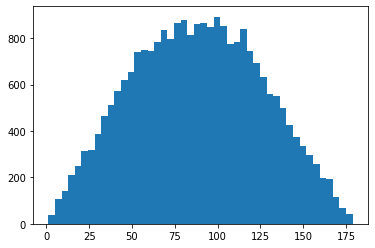

In [18]:

evt_local = coord.local_event(np.array(theta), np.array(phi), times, location="orca")

print(evt_local)
evt_equat = evt_local.transform_to("icrs")
print(evt_equat)

from km3astro.sources import VELA_X
source_dist = evt_equat.separation(VELA_X)

import matplotlib.pyplot as plt
plt.hist(source_dist.degree, bins="auto")



In [58]:
from astropy.coordinates import SkyCoord
import astropy.units as u
def angular_separation(ra1, dec1, ra2, dec2):   
    point1 = SkyCoord(ra=ra1*u.deg, dec=dec1*u.deg, frame='icrs')
    point2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg, frame='icrs')
    separation = point1.separation(point2)
    return separation.to(u.deg).value

def select_events_in_radius(ra_data, dec_data, ra_center, dec_center, radius):
    angular_distances = angular_separation(ra_data, dec_data, ra_center, dec_center)
    selected_indices = np.where(angular_distances <= radius)[0]

    selected_ra = ra_data[selected_indices]
    selected_dec = dec_data[selected_indices]
    print(f"Number of Events in Radius: {radius*180} degrees around the source: {len(selected_ra)}")
    print(f"Total number of Events: {len(ra_data)}")
    return selected_ra, selected_dec

Number of Events in Radius: 5.0 degrees around the source: 3
Total number of Events: 24485


Text(0, 0.5, 'Declination / rad')

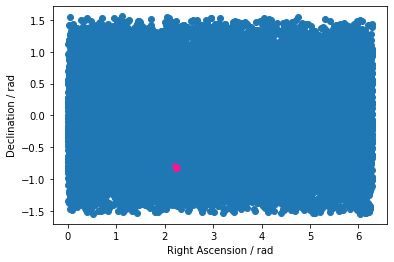

In [59]:
right_ascension_radian = evt_equat.ra.rad
declination_radian = evt_equat.dec.rad


right_ascension_radian_sel, declination_radian_sel = select_events_in_radius(right_ascension_radian,declination_radian,VELA_X.ra.rad,VELA_X.dec.rad,5/180)

plt.scatter(right_ascension_radian, declination_radian)

plt.scatter(right_ascension_radian_sel, declination_radian_sel,c="deeppink",alpha=0.7)
#plt.scatter(VELA_X.ra.rad, VELA_X.dec.rad,lw=0.1, color="orange")
plt.xlabel("Right Ascension / rad")
plt.ylabel("Declination / rad")


TypeError: plot_equatorial() missing 1 required positional argument: 'evts'

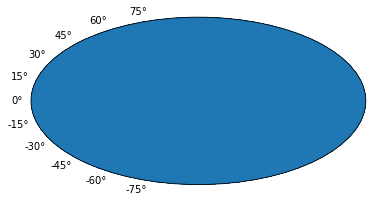

In [31]:
from km3astro.plot import plot_equatorial

ax = plot_equatorial(evt_equat, markersize=12, label="Event")
plot_equatorial()
plot_equatorial(VELA_X, markersize=12, ax=ax, label="Vela X")

plt.legend(loc="best")


TypeError: plot_energy_sky_map_km3() missing 2 required positional arguments: 'evts' and 'energy'

## Testing data blinding aka time shuffeling

In [3]:
from docopt import docopt
import os, glob

from h5py import File, Group
from astropy.table import Table
from astropy.time import Time
from astropy.io.misc.hdf5 import read_table_hdf5, write_table_hdf5
import astropy.units as u
from astropy.coordinates import SkyCoord
import km3io.definitions as kd

from km3astro.io import load_hdf5_tables

import numpy as np

from km3astro.coord import local_event
from km3astro import sources

def shuffle_times(table, time_column):
    """
    Shuffle the times in the given Astropy table.

    Parameters
    ----------
    table : astropy.table.Table
        Table containing the times to be shuffled.
    time_column : str
        The name of the time column to shuffle.

    Returns
    -------
    astropy.table.Table
        New table with shuffled times.
    """
    times = table[time_column]
    shuffled_times = np.random.permutation(times)
    table[time_column] = shuffled_times
    return table

file = '/home/hpc/capn/capn107h/software/km3astro/TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013516.jchain.aashower.187.h5'
output_filename = '/home/hpc/capn/capn107h/software/DataBlindingTest.h5'
tables = load_hdf5_tables(file)
print(tables.__dict__)
print(tables)
shuffled_tables = {}

reco_types = {
    'mc': ('id_table', 'timeslice_utc_time'),
    'reco': ('reco_table', 'tracktime_utc'),
}

for reco_type, details in reco_types.items():
    print(reco_type)
    print(details)
    if reco_type == 'mc' and hasattr(tables, 'mc_table') and tables.mc_table is not None:
        print("MC times are present and will now get shuffled...")
        table_name, time_column = details
        table = tables.id_table
        shuffled_tables[table_name] = shuffle_times(table, time_column)
    elif reco_type == 'reco':
        print("RECO times are present and will now get shuffled...")
        table_name, time_column = details
        table = tables.reco_table
        shuffled_tables[table_name] = shuffle_times(table, time_column)

# Write the shuffled tables back to an HDF5 file
with File(output_filename, 'w') as h5file:
    # Write HEADER table
    if hasattr(tables, 'header_table'):
        write_table_hdf5(tables.header_table, h5file, path="HEADER", serialize_meta=True)
    # Write ID table
    if hasattr(tables, 'id_table'):
        write_table_hdf5(tables.id_table, h5file, path="ID", serialize_meta=True)
    # Write RECO_EVENTS table
    if hasattr(tables, 'reco_table'):
        reco_grp = h5file.create_group("RECO")
        write_table_hdf5(tables.reco_table, reco_grp, path="RECO_EVENTS", serialize_meta=True)
    # Write MC_EVENTS table
    if hasattr(tables, 'mc_table') and tables.mc_table is not None:
        mc_grp = h5file.create_group("MC")
        write_table_hdf5(tables.mc_table, mc_grp, path="MC_EVENTS", serialize_meta=True)

print(f"Shuffled file written: {output_filename}")

RECO_EVENTS is present
MC_EVENTS is present
{'header_table': <Table length=24>
     Parameter       ...
      bytes20        ...
-------------------- ...
                 DAQ ...
            GXMLPATH ...
            XSecFile ...
aashowerfit_detector ...
          coord_site ...
              cut_nu ...
               depth ...
            detector ...
             drawing ...
            fixedcan ...
                 ... ...
           physics_2 ...
           physics_3 ...
             primary ...
                seed ...
               simul ...
             simul_1 ...
         source_mode ...
            spectrum ...
           start_run ...
       time_interval ..., 'id_table': <Table length=13362>
event_id timeslice_utc_time
 int64         object      
-------- ------------------
       0  1665835200.827553
       1 1665835201.1295316
       2 1665835201.2411122
       3  1665835201.582617
       4 1665835201.7562733
       5 1665835202.0457973
       6 1665835202.2772567
       

In [4]:
from km3astro.io import load_hdf5_tables
oringinal_file = load_hdf5_tables(file)
blinded_file = load_hdf5_tables(output_filename)

RECO_EVENTS is present
MC_EVENTS is present
RECO_EVENTS is present
MC_EVENTS is present


## Check structure of hdf5 tables and root files

In [5]:
def debug_hdf5_tables(tables):
    """
    Debugging function to print the structure of tables loaded from an HDF5 file.

    Parameters
    ----------
    tables : object
        An object containing attributes header_table, id_table, reco_table, and optionally mc_table.
    """
    if tables.header_table:
        print("HEADER table: {} rows, {} columns".format(len(tables.header_table), len(tables.header_table.colnames)))
    if tables.id_table:
        print("ID table: {} rows, {} columns".format(len(tables.id_table), len(tables.id_table.colnames)))
    if tables.reco_table:
        print("RECO_EVENTS table: {} rows, {} columns".format(len(tables.reco_table), len(tables.reco_table.colnames)))
    if tables.mc_table is not None:
        print("MC_EVENTS table: {} rows, {} columns".format(len(tables.mc_table), len(tables.mc_table.colnames)))
    else:
        print("MC_EVENTS table is not present.")

def compare_hdf5_files(file1_path, file2_path):
    """
    Compare the structure of two HDF5 files.

    Parameters
    ----------
    file1_path : str
        Path to the first HDF5 file.
    file2_path : str
        Path to the second HDF5 file.
    """
    tables1 = load_hdf5_tables(file1_path)
    tables2 = load_hdf5_tables(file2_path)

    print(f"Comparing files: {file1_path} and {file2_path}\n")

    print("File 1:")
    debug_hdf5_tables(tables1)

    print("\nFile 2:")
    debug_hdf5_tables(tables2)

    # Additional comparisons can be added here if needed

# Example usage:
# compare_hdf5_files("file1.h5", "file2.h5")


In [8]:
hdf5_data_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/datav8.1.1.jchain.aashower.00014081.h5"
hdf5_mc_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5"
hdf5_old_data_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013318.jchain.aashower.30.h5"

compare_hdf5_files_verbose(hdf5_mc_path,hdf5_old_data_path)

RECO_EVENTS is present
MC_EVENTS is present
RECO_EVENTS is present
MC_EVENTS is present
Comparing files: /home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5 and /home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013318.jchain.aashower.30.h5

File 1:
HEADER table: 24 rows, 2 columns
HEADER table columns and types:
  Parameter: |S20
  Value: |S178
ID table: 13274 rows, 2 columns
ID table columns and types:
  event_id: int64
  timeslice_utc_time: astropy.time.Time
Mean Time timeslice_utc_time:  2022-09-22 16:30:30.881
RECO_EVENTS table: 24485 rows, 12 columns
RECO_EVENTS table columns and types:
  event_id: int64
  rec_type: int64
  rec_stage: int64
  tracktime_utc: astropy.time.Time
  tracktime_ns: float64
  energy: float64
  likelihood: float64
  theta_detectorframe: float64
  phi_detectorframe: float64
  pos_x: float64
  pos_y: float64
  pos_z: float64
Mean Tim

In [7]:

import astropy
from astropy.table import Table
from astropy.time import Time
import h5py
import os
import time
import numpy as np

# Assume load_hdf5_tables and root_to_hdf5 functions are defined as in your original code.

def print_table_details(table, table_name):
    """
    Print the details of a given table, including column names and data types.

    Parameters
    ----------
    table : astropy.table.Table
        The table to be printed.
    table_name : str
        The name of the table.
    """
    if table:
        print(f"{table_name} table columns and types:")
        for col_name in table.colnames:
            col = table[col_name]
            if isinstance(col, Time):
                print(f"  {col_name}: astropy.time.Time")
            else:
                print(f"  {col_name}: {col.dtype}")
    else:
        print(f"{table_name} table is not present.")

def mean_time_column(time_column):
    """
    Calculate the mean of an astropy.time.Time column.

    Parameters
    ----------
    time_column : astropy.time.Time
        The Time column to calculate the mean for.

    Returns
    -------
    astropy.time.Time
        The mean time.
    """
    mean_jd = np.mean(time_column.jd)
    return Time(mean_jd, format='jd')

def debug_hdf5_tables_verbose(tables):
    """
    Debugging function to print the detailed structure of tables loaded from an HDF5 file.

    Parameters
    ----------
    tables : object
        An object containing attributes header_table, id_table, reco_table, and optionally mc_table.
    """
    details = {}
    
    if tables.header_table:
        details['header'] = {
            "rows": len(tables.header_table),
            "columns": len(tables.header_table.colnames),
            "column_details": [(col_name, "astropy.time.Time" if isinstance(tables.header_table[col_name], Time) else tables.header_table[col_name].dtype) for col_name in tables.header_table.colnames]
        }
        print("HEADER table: {} rows, {} columns".format(len(tables.header_table), len(tables.header_table.colnames)))
        print_table_details(tables.header_table, "HEADER")
        
    if tables.id_table:
        mean_timeslice = mean_time_column(tables.id_table["timeslice_utc_time"]).iso
        details['id'] = {
            "rows": len(tables.id_table),
            "columns": len(tables.id_table.colnames),
            "column_details": [(col_name, "astropy.time.Time" if isinstance(tables.id_table[col_name], Time) else tables.id_table[col_name].dtype) for col_name in tables.id_table.colnames],
            "mean_timeslice": mean_timeslice
        }
        print("ID table: {} rows, {} columns".format(len(tables.id_table), len(tables.id_table.colnames)))
        print_table_details(tables.id_table, "ID")
        print("Mean Time timeslice_utc_time: ", mean_timeslice)
        
    if tables.reco_table:
        mean_recotime = mean_time_column(tables.reco_table["tracktime_utc"]).iso
        details['reco'] = {
            "rows": len(tables.reco_table),
            "columns": len(tables.reco_table.colnames),
            "column_details": [(col_name, "astropy.time.Time" if isinstance(tables.reco_table[col_name], Time) else tables.reco_table[col_name].dtype) for col_name in tables.reco_table.colnames],
            "mean_recotime": mean_recotime
        }
        print("RECO_EVENTS table: {} rows, {} columns".format(len(tables.reco_table), len(tables.reco_table.colnames)))
        print_table_details(tables.reco_table, "RECO_EVENTS")
        print("Mean Time tracktime_utc: ", mean_recotime)
        
    if tables.mc_table is not None:
        details['mc'] = {
            "rows": len(tables.mc_table),
            "columns": len(tables.mc_table.colnames),
            "column_details": [(col_name, "astropy.time.Time" if isinstance(tables.mc_table[col_name], Time) else tables.mc_table[col_name].dtype) for col_name in tables.mc_table.colnames]
        }
        print("MC_EVENTS table: {} rows, {} columns".format(len(tables.mc_table), len(tables.mc_table.colnames)))
        print_table_details(tables.mc_table, "MC_EVENTS")
    else:
        details['mc'] = None
        print("MC_EVENTS table is not present.")
        
    return details

def compare_hdf5_files_verbose(file1_path, file2_path):
    """
    Compare the detailed structure of two HDF5 files.

    Parameters
    ----------
    file1_path : str
        Path to the first HDF5 file.
    file2_path : str
        Path to the second HDF5 file.
    """
    tables1 = load_hdf5_tables(file1_path)
    tables2 = load_hdf5_tables(file2_path)

    print(f"Comparing files: {file1_path} and {file2_path}\n")

    print("File 1:")
    details1 = debug_hdf5_tables_verbose(tables1)

    print("\nFile 2:")
    details2 = debug_hdf5_tables_verbose(tables2)

    print("\nComparison Results:")
    for key in details1:
        if details1[key] != details2[key]:
            print(f"Difference found in {key.upper()} table")
            print("File 1 details:", details1[key])
            print("File 2 details:", details2[key])
        else:
            print(f"{key.upper()} table is identical in both files")

# Example usage:
# compare_hdf5_files_verbose("file1.h5", "file2.h5")

# compare_hdf5_files_verbose("file1.h5", "file2.h5")



In [8]:
file = '/home/hpc/capn/capn107h/software/km3astro/TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013516.jchain.aashower.187.h5'

compare_hdf5_files_verbose(file,output_filename)

RECO_EVENTS is present
MC_EVENTS is present
RECO_EVENTS is present
MC_EVENTS is present
Comparing files: /home/hpc/capn/capn107h/software/km3astro/TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013516.jchain.aashower.187.h5 and /home/hpc/capn/capn107h/software/DataBlindingTest.h5

File 1:
HEADER table: 24 rows, 2 columns
HEADER table columns and types:
  Parameter: |S20
  Value: |S178
ID table: 13362 rows, 2 columns
ID table columns and types:
  event_id: int64
  timeslice_utc_time: astropy.time.Time
Mean Time timeslice_utc_time:  2022-10-15 13:29:27.968
RECO_EVENTS table: 24699 rows, 12 columns
RECO_EVENTS table columns and types:
  event_id: int64
  rec_type: int64
  rec_stage: int64
  tracktime_utc: astropy.time.Time
  tracktime_ns: float64
  energy: float64
  likelihood: float64
  theta_detectorframe: float64
  phi_detectorframe: float64
  pos_x: float64
  pos_y: float64
  pos_z: float64
Mean Time tracktime_utc:  2022-10-15 13:29:22.713
MC_EVENTS table: 13362 rows, 9 c

## Check angle calculation

In [9]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools
import numpy as np

def angle_between_vectors(dir_x1, dir_y1, dir_z1, dir_x2, dir_y2, dir_z2):
    # Convert inputs to numpy arrays if they are not already
    v1 = np.array([dir_x1, dir_y1, dir_z1])
    v2 = np.array([dir_x2, dir_y2, dir_z2])
    
    # Compute the dot products of the vectors
    dot_products = np.sum(v1 * v2, axis=0)
    
    # Compute the magnitudes of the vectors
    magnitudes_v1 = np.linalg.norm(v1, axis=0)
    magnitudes_v2 = np.linalg.norm(v2, axis=0)
    
    # Calculate the cosine of the angles between the vectors
    cos_angles = dot_products / (magnitudes_v1 * magnitudes_v2)
    
    # Clip the values to avoid numerical issues with arccos
    cos_angles = np.clip(cos_angles, -1.0, 1.0)
    
    # Calculate the angles in radians
    angles = np.arccos(cos_angles)
    
    # Convert the angles from radians to degrees (optional)
    angles_degrees = np.degrees(angles)
    
    return angles_degrees

def dir_to_spherical(tracks):
    """
    Convert directional coordinates (x, y, z) to spherical coordinates (theta, phi).

    Parameters
    ----------
    tracks : numpy.array
        Array containing track information, OfflineReader.tracks object

    Returns
    -------
    tuple
        Tuple containing spherical coordinates (theta, phi).
    """
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)
nu = offline.mc_tracks[:,0]
nu_reco = offline.tracks
best_fit = tools.best_aashower(nu_reco)
mask_reco = tools.has_aashower(nu_reco)

dir_x_mc = nu[mask_reco].dir_x[0:5]
dir_y_mc = nu[mask_reco].dir_y[0:5]
dir_z_mc = nu[mask_reco].dir_z[0:5]

print(len(dir_x_mc))
print(f"dir_x_mc: {dir_x_mc}")
print(f"dir_y_mc: {dir_y_mc}")
print(f"dir_z_mc: {dir_z_mc}")

dir_x_reco = best_fit[mask_reco].dir_x[0:5]
dir_y_reco = best_fit[mask_reco].dir_y[0:5]
dir_z_reco = best_fit[mask_reco].dir_z[0:5]

print(len(dir_x_reco))
print(f"dir_x_reco: {dir_x_reco}")
print(f"dir_y_reco: {dir_y_reco}")
print(f"dir_z_reco: {dir_z_reco}")

angle = angle_between_vectors(dir_x_mc, dir_y_mc, dir_z_mc, dir_x_reco, dir_y_reco, dir_z_reco)
print(f"angle: {angle}")

test_vec1 = np.array([1,0,0])
test_vec2 = np.array([0,1,0])
test_angle1 = angle_between_vectors(1,0,0,0,1,0)
print(f"test_angle 1 (90deg expected): {test_angle1}")

test_angle2 = angle_between_vectors(1,0,0,-1,0,0)
print(f"test_angle2 (180deg expected): {test_angle2}")

test_angle3 = angle_between_vectors(1,1,0,1,0,0)
print(f"test_angle3 (45deg expected): {test_angle3}")

theta_mc_root, phi_mc_root = dir_to_spherical(nu[mask_reco])
theta_reco_root, phi_reco_root = dir_to_spherical(best_fit[mask_reco])


print("Phi MC Root: ", phi_mc_root[0:5])
print("Phi Reco Root: ",phi_reco_root[0:5])

print("Theta MC Root: ",theta_mc_root[0:5])
print("Theta Reco Root: ",theta_reco_root[0:5])

h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5"
# h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_arca.h5"

file = load_hdf5_tables(h5filename)

phi_mc = file.mc_table['phi_detectorframe'][0:5]
theta_mc = file.mc_table['theta_detectorframe'][0:5]

phi_reco = file.reco_table['phi_detectorframe'][0:5]
theta_reco = file.reco_table['theta_detectorframe'][0:5]

time = file.id_table['timeslice_utc_time'][0:5]

print("Phi MC hdf5: ",np.array(phi_mc))
print("Phi Reco hdf5: ", np.array(phi_reco))

print("Theta MC hdf5: ", np.array(theta_mc))
print("Theta Reco hdf5: ",np.array(theta_reco))

diff_root_hdf5_phimc = np.array(phi_mc) - phi_mc_root[0:5]
diff_root_hdf5_phireco = np.array(phi_reco) - phi_reco_root[0:5]
diff_root_hdf5_thetamc = np.array(theta_mc) - theta_mc_root[0:5]
diff_root_hdf5_thetareco = np.array(theta_reco) - theta_reco_root[0:5]

print("Difference Root - hdf5 (Phi MC): ",diff_root_hdf5_phimc)
print("Difference Root - hdf5 (Phi Reco): ",diff_root_hdf5_phireco)
print("Difference Root - hdf5 (Theta MC): ",diff_root_hdf5_thetamc)
print("Difference Root - hdf5 (Theta Reco): ",diff_root_hdf5_thetareco)

# Some problem with the reco values, not same in root and hdf5



def calc_angsep(theta_1,phi_1,theta_2,phi_2):
    alpha = np.sin(theta_1)*np.cos(phi_1)*np.sin(theta_2)*np.cos(phi_2) + np.sin(phi_1)*np.sin(theta_1)*np.sin(phi_2)*np.sin(theta_2) + np.cos(theta_1)*np.cos(theta_2)
    return np.arccos(alpha)*180/np.pi


from km3astro.coord import local_event
import numpy as np

le_reco = local_event(np.array(theta_reco),np.array(phi_reco),time,'arca')
le_mc = local_event(np.array(theta_mc),np.array(phi_mc),time,'arca')

print("Local Event Reco: ",le_reco[0:5])
print("Local Event MC: ", le_mc[0:5])

sep = le_reco.separation(le_mc)
print("Local Event Separation: ",sep[0:5])
print("Local Event Separation np.array: ",np.array(sep)[0:5])

sep_calc = calc_angsep(theta_1=theta_mc,phi_1=phi_mc,theta_2=theta_reco,phi_2=phi_reco)
print("Calculated Separation: ",sep_calc[0:5])


5
dir_x_mc: [-0.0828, -0.727, -0.0872, -0.198, -0.33]
dir_y_mc: [0.0828, 0.0551, -0.946, -0.801, 0.881]
dir_z_mc: [-0.993, 0.684, 0.311, -0.564, 0.339]
5
dir_x_reco: [-0.0223, -0.724, 0.296, -0.579, 0.353]
dir_y_reco: [-0.645, 0.0778, -0.578, -0.788, 0.875]
dir_z_reco: [-0.764, 0.686, 0.761, -0.212, 0.331]
angle: [44.97115386  1.31906656 40.77838985 30.05804812 39.94686745]
test_angle 1 (90deg expected): 90.0
test_angle2 (180deg expected): 180.0
test_angle3 (45deg expected): 45.00000000000001
Phi MC Root:  [2.35603632 3.06596259 4.6204863  4.46974599 1.92962195]
Phi Reco Root:  [4.67784752 3.03446111 5.18659984 4.07869446 1.18771124]
Theta MC Root:  [3.02424299 0.81700273 1.25459592 2.17037682 1.22541839]
Theta Reco Root:  [2.44066509 0.81514763 0.70644852 1.78438545 1.23306461]
RECO_EVENTS is present
MC_EVENTS is present
Phi MC hdf5:  [2.35603632 3.06596259 4.6204863  4.46974599 1.92962195]
Phi Reco hdf5:  [4.67784752 3.03446111 1.84943409 5.18659984 3.23583373]
Theta MC hdf5:  [3.024

In [10]:
nu_reco = offline.tracks
best_fit = tools.best_aashower(nu_reco)
mask_reco = tools.has_aashower(nu_reco)

print("\n Event [0]:")
print("Likelihood: ", nu_reco[mask_reco][0].lik)
print("Likelihood Best Fit: ",best_fit[mask_reco][0].lik)

print("FitInf: ", nu_reco[mask_reco][0].fitinf)
print("FitInf Best Fit: ",best_fit[mask_reco][0].fitinf)

print("ID: ",nu_reco[mask_reco][0].id)
print("ID Best Fit: ", best_fit[mask_reco][0].id)

print("\n Event [10]:")
print("Likelihood: ",nu_reco[mask_reco][10].lik)
print("Likelihood Best Fit: ", best_fit[mask_reco][10].lik)

print("FitInf: ",nu_reco[mask_reco][10].fitinf)
print("FitInf Best Fit: ",best_fit[mask_reco][10].fitinf)

print("ID Best Fit: ", nu_reco[mask_reco][10].id)
print("ID: ", best_fit[mask_reco][10].id)

print("\n Event [20]:")
print("Likelihood: ",nu_reco[mask_reco][20].lik)
print("Likelihood Best Fit: ", best_fit[mask_reco][20].lik)

print("FitInf: ",nu_reco[mask_reco][20].fitinf)
print("FitInf Best Fit: ",best_fit[mask_reco][20].fitinf)

print("ID Best Fit: ", nu_reco[mask_reco][20].id)
print("ID: ", best_fit[mask_reco][20].id)



 Event [0]:
Likelihood:  [0, 584, -276, -276, -217, -180, -174, -174, -174, -174, -174, -174, -174, -174]
Likelihood Best Fit:  -173.7475432645971
FitInf:  [[], [0.0943], [3.08e-47, 111], [3.36e-07, ... 186, 111], [186, 111], [186, 111]]
FitInf Best Fit:  [186, 111]
ID:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
ID Best Fit:  14

 Event [10]:
Likelihood:  [0, 153, -196, -196, -196, -196, -183, -172, -171, -171, -171, -170, -170, -170]
Likelihood Best Fit:  -170.26520508968258
FitInf:  [[], [0.00172], [8.05e-36, 84], [8.87e-10, 84], ... [112, 84], [112, 84], [112, 84]]
FitInf Best Fit:  [112, 84]
ID Best Fit:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
ID:  14

 Event [20]:
Likelihood:  [465, 465, 465, 401, 367, ... -6.52e+03, -6.52e+03, -6.52e+03, -6.52e+03, -6.52e+03]
Likelihood Best Fit:  -6516.812176380522
FitInf:  [[0.00202, 0.00142, -465, 2.27e+03, 9.06e+05, ... 1.24e+04], [3.83e+06, 1.24e+04]]
FitInf Best Fit:  [3.83e+06, 1.24e+04]
ID Best Fit:  [80, 126, 146, 22, 94,

In [13]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools
import numpy as np

def angle_between_vectors(dir_x1, dir_y1, dir_z1, dir_x2, dir_y2, dir_z2):
    v1 = np.array([dir_x1, dir_y1, dir_z1])
    v2 = np.array([dir_x2, dir_y2, dir_z2])
    dot_products = np.sum(v1 * v2, axis=0)
    magnitudes_v1 = np.linalg.norm(v1, axis=0)
    magnitudes_v2 = np.linalg.norm(v2, axis=0)
    cos_angles = dot_products / (magnitudes_v1 * magnitudes_v2)
    cos_angles = np.clip(cos_angles, -1.0, 1.0)
    angles = np.arccos(cos_angles)
    angles_degrees = np.degrees(angles)
    return angles_degrees

def dir_to_spherical(tracks):
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def calc_angsep(theta_1,phi_1,theta_2,phi_2):
    alpha = np.sin(theta_1)*np.cos(phi_1)*np.sin(theta_2)*np.cos(phi_2) + np.sin(phi_1)*np.sin(theta_1)*np.sin(phi_2)*np.sin(theta_2) + np.cos(theta_1)*np.cos(theta_2)
    return np.arccos(alpha)*180/np.pi

# Load ROOT file
rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)
nu = offline.mc_tracks[:, 0]
nu_reco = offline.tracks
best_fit = tools.best_aashower(nu_reco)
mask_reco = tools.has_aashower(nu_reco)

# Get directions for MC and Reco (ROOT)
dir_x_mc = nu[mask_reco].dir_x[:5]
dir_y_mc = nu[mask_reco].dir_y[:5]
dir_z_mc = nu[mask_reco].dir_z[:5]

dir_x_reco = best_fit[mask_reco].dir_x[:5]
dir_y_reco = best_fit[mask_reco].dir_y[:5]
dir_z_reco = best_fit[mask_reco].dir_z[:5]

# Angle between MC and Reco directions
angle = angle_between_vectors(dir_x_mc, dir_y_mc, dir_z_mc, dir_x_reco, dir_y_reco, dir_z_reco)

# Spherical coordinates
theta_mc_root, phi_mc_root = dir_to_spherical(nu[mask_reco])
theta_reco_root, phi_reco_root = dir_to_spherical(best_fit[mask_reco])

# Load HDF5 file
h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5"
# h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_arca.h5"

file = load_hdf5_tables(h5filename)

reco_mask_hdf5 = np.where((file.reco_table['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & (file.reco_table['rec_stage'] == kd.reconstruction.AASHOWERBEGIN ))

phi_mc_hdf5 = file.mc_table['phi_detectorframe'][:5]
theta_mc_hdf5 = file.mc_table['theta_detectorframe'][:5]
phi_reco_hdf5 = file.reco_table[reco_mask_hdf5]['phi_detectorframe'][:5]
theta_reco_hdf5 = file.reco_table[reco_mask_hdf5]['theta_detectorframe'][:5]
time = file.id_table['timeslice_utc_time'][:5]

# Differences between ROOT and HDF5
diff_phi_mc = phi_mc_hdf5 - phi_mc_root[:5]
diff_phi_reco = phi_reco_hdf5 - phi_reco_root[:5]
diff_theta_mc = theta_mc_hdf5 - theta_mc_root[:5]
diff_theta_reco = theta_reco_hdf5 - theta_reco_root[:5]

# Output the results
print(f"{'Comparison of MC and Reco Values (ROOT vs HDF5)':^60}")
print(f"{'-'*60}")
print(f"{'Parameter':<20} {'ROOT':<15} {'HDF5':<15} {'Difference':<10}")
for i in range(5):
    print(f"MC Phi  [{i}]: {phi_mc_root[i]:<15.6f} {phi_mc_hdf5[i]:<15.6f} {diff_phi_mc[i]:<10.6f}")
    print(f"MC Theta[{i}]: {theta_mc_root[i]:<15.6f} {theta_mc_hdf5[i]:<15.6f} {diff_theta_mc[i]:<10.6f}")
    print(f"Reco Phi [{i}]: {phi_reco_root[i]:<15.6f} {phi_reco_hdf5[i]:<15.6f} {diff_phi_reco[i]:<10.6f}")
    print(f"Reco Theta[{i}]: {theta_reco_root[i]:<15.6f} {theta_reco_hdf5[i]:<15.6f} {diff_theta_reco[i]:<10.6f}")

# Local event calculation
from km3astro.coord import local_event

le_reco_root = local_event(np.array(theta_reco_root[:5]), np.array(phi_reco_root[:5]), time, 'arca')
le_mc_root = local_event(np.array(theta_mc_root[:5]), np.array(phi_mc_root[:5]), time, 'arca')
sep_root = le_reco_root.separation(le_mc_root)

# Angular separation calculation
sep_calc_root = calc_angsep(theta_1=theta_mc_root[:5], phi_1=phi_mc_root[:5], theta_2=theta_reco_root[:5], phi_2=phi_reco_root[:5])

print("\nCalculated Separations root:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep_root[i]:.6f}, Calc. Separation={sep_calc_root[i]:.6f}")

le_reco = local_event(np.array(theta_reco_hdf5), np.array(phi_reco_hdf5), time, 'arca')
le_mc = local_event(np.array(theta_mc_hdf5), np.array(phi_mc_hdf5), time, 'arca')
sep = le_reco.separation(le_mc)

# Angular separation calculation
sep_calc = calc_angsep(theta_1=theta_mc_hdf5, phi_1=phi_mc_hdf5, theta_2=theta_reco_hdf5, phi_2=phi_reco_hdf5)

print("\nCalculated Separations hdf5:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep[i]:.6f}, Calc. Separation={sep_calc[i]:.6f}")



RECO_EVENTS is present
MC_EVENTS is present
      Comparison of MC and Reco Values (ROOT vs HDF5)       
------------------------------------------------------------
Parameter            ROOT            HDF5            Difference
MC Phi  [0]: 2.356036        2.356036        0.000000  
MC Theta[0]: 3.024243        3.024243        0.000000  
Reco Phi [0]: 4.677848        4.677848        0.000000  
Reco Theta[0]: 2.440665        2.440665        0.000000  
MC Phi  [1]: 3.065963        3.065963        0.000000  
MC Theta[1]: 0.817003        0.817003        0.000000  
Reco Phi [1]: 3.034461        3.034461        0.000000  
Reco Theta[1]: 0.815148        0.815148        0.000000  
MC Phi  [2]: 4.620486        4.620486        0.000000  
MC Theta[2]: 1.254596        1.254596        0.000000  
Reco Phi [2]: 5.186600        5.186600        0.000000  
Reco Theta[2]: 0.706449        0.706449        0.000000  
MC Phi  [3]: 4.469746        4.469746        0.000000  
MC Theta[3]: 2.170377        2.17

In [ ]:
le_reco_root = local_event(np.array(theta_reco_root), np.array(phi_reco_root), time, 'arca')
le_mc_root = local_event(np.array(theta_mc_root), np.array(phi_mc_root), time, 'arca')
sep_root = le_reco_root.separation(le_mc_root)

# Angular separation calculation
sep_calc_root = calc_angsep(theta_1=theta_mc_root, phi_1=phi_mc_root, theta_2=theta_reco_root, phi_2=phi_reco_root)

print("\nCalculated Separations root:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep_root[i]:.6f}, Calc. Separation={sep_calc_root[i]:.6f}")

# Event comparison
print(f"\n{'Event Comparisons':^60}")
print(f"{'Event':<10} {'Likelihood (ROOT)':<20} {'Best Fit (ROOT)':<20}")
for idx in [0, 10, 20]:
    print(f"Event[{idx}]:")
    print(f"Likelihood:    {nu_reco[mask_reco][idx].lik:<20} {best_fit[mask_reco][idx].lik:<20}")
    print(f"FitInf:        {nu_reco[mask_reco][idx].fitinf:<20} {best_fit[mask_reco][idx].fitinf:<20}")
    print(f"ID:            {nu_reco[mask_reco][idx].id:<20} {best_fit[mask_reco][idx].id:<20}")



In [72]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools
import km3io.definitions as kd
import numpy as np

def angle_between_vectors(dir_x1, dir_y1, dir_z1, dir_x2, dir_y2, dir_z2):
    v1 = np.array([dir_x1, dir_y1, dir_z1])
    v2 = np.array([dir_x2, dir_y2, dir_z2])
    dot_products = np.sum(v1 * v2, axis=0)
    magnitudes_v1 = np.linalg.norm(v1, axis=0)
    magnitudes_v2 = np.linalg.norm(v2, axis=0)
    cos_angles = dot_products / (magnitudes_v1 * magnitudes_v2)
    cos_angles = np.clip(cos_angles, -1.0, 1.0)
    angles = np.arccos(cos_angles)
    angles_degrees = np.degrees(angles)
    return angles_degrees

def dir_to_spherical(tracks):
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def calc_angsep(theta_1,phi_1,theta_2,phi_2):
    alpha = np.sin(theta_1)*np.cos(phi_1)*np.sin(theta_2)*np.cos(phi_2) + np.sin(phi_1)*np.sin(theta_1)*np.sin(phi_2)*np.sin(theta_2) + np.cos(theta_1)*np.cos(theta_2)
    return np.arccos(alpha)*180/np.pi


# Testing if the functions really calculate it the right way

test_vec1 = np.array([1,0,0])
test_vec2 = np.array([0,1,0])
test_angle1 = angle_between_vectors(1,0,0,0,1,0)
print(f"test_angle 1 (90deg expected): {test_angle1}")

test_angle2 = angle_between_vectors(1,0,0,-1,0,0)
print(f"test_angle2 (180deg expected): {test_angle2}")

test_angle3 = angle_between_vectors(1,1,0,1,0,0)
print(f"test_angle3 (45deg expected): {test_angle3}")

test_angle4 = angle_between_vectors(1,0,0,1,0,0)
print(f"test_angle4 (0deg expected): {test_angle4}")

# Load ROOT file
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)
print(offline.header)
nu = offline.mc_tracks[:, 0]
nu_reco = offline.tracks
best_fit = tools.best_jmuon(nu_reco)
mask_reco = tools.has_jmuon(nu_reco)

# Get directions for MC and Reco (ROOT)
dir_x_mc = nu[mask_reco].dir_x[:5]
dir_y_mc = nu[mask_reco].dir_y[:5]
dir_z_mc = nu[mask_reco].dir_z[:5]

dir_x_reco = best_fit[mask_reco].dir_x[:5]
dir_y_reco = best_fit[mask_reco].dir_y[:5]
dir_z_reco = best_fit[mask_reco].dir_z[:5]

# Angle between MC and Reco directions
angle = angle_between_vectors(dir_x_mc, dir_y_mc, dir_z_mc, dir_x_reco, dir_y_reco, dir_z_reco)

# Spherical coordinates
theta_mc_root, phi_mc_root = dir_to_spherical(nu[mask_reco])
theta_reco_root, phi_reco_root = dir_to_spherical(best_fit[mask_reco])

# Load HDF5 file
# h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5"
h5filename = "/home/hpc/capn/capn107h/software/hdf5TestOutputmcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1_arca.h5"

file = load_hdf5_tables(h5filename)

# reco_mask_hdf5 = np.where((file.reco_table['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & (file.reco_table['rec_stage'] == kd.reconstruction.AASHOWERBEGIN ))
reco_mask_hdf5 = np.where((file.reco_table['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & (file.reco_table['rec_stage'] == kd.reconstruction.JMUONBEGIN ))

phi_mc_hdf5 = file.mc_table['phi_detectorframe'][:5]
theta_mc_hdf5 = file.mc_table['theta_detectorframe'][:5]
phi_reco_hdf5 = file.reco_table[reco_mask_hdf5]['phi_detectorframe'][:5]
theta_reco_hdf5 = file.reco_table[reco_mask_hdf5]['theta_detectorframe'][:5]
time = file.id_table['timeslice_utc_time'][:5]

# Differences between ROOT and HDF5
diff_phi_mc = phi_mc_hdf5 - phi_mc_root[:5]
diff_phi_reco = phi_reco_hdf5 - phi_reco_root[:5]
diff_theta_mc = theta_mc_hdf5 - theta_mc_root[:5]
diff_theta_reco = theta_reco_hdf5 - theta_reco_root[:5]

# Output the results
print(f"{'Comparison of MC and Reco Values (ROOT vs HDF5)':^60}")
print(f"{'-'*60}")
print(f"{'Parameter':<20} {'ROOT':<15} {'HDF5':<15} {'Difference':<10}")
for i in range(5):
    print(f"MC Phi  [{i}]: {phi_mc_root[i]:<15.6f} {phi_mc_hdf5[i]:<15.6f} {diff_phi_mc[i]:<10.6f}")
    print(f"MC Theta[{i}]: {theta_mc_root[i]:<15.6f} {theta_mc_hdf5[i]:<15.6f} {diff_theta_mc[i]:<10.6f}")
    print(f"Reco Phi [{i}]: {phi_reco_root[i]:<15.6f} {phi_reco_hdf5[i]:<15.6f} {diff_phi_reco[i]:<10.6f}")
    print(f"Reco Theta[{i}]: {theta_reco_root[i]:<15.6f} {theta_reco_hdf5[i]:<15.6f} {diff_theta_reco[i]:<10.6f}")

# Local event calculation
from km3astro.coord import local_event

le_reco_root = local_event(np.array(theta_reco_root[:5]), np.array(phi_reco_root[:5]), time, 'arca')
le_mc_root = local_event(np.array(theta_mc_root[:5]), np.array(phi_mc_root[:5]), time, 'arca')
sep_root = le_reco_root.separation(le_mc_root)

# Angular separation calculation
sep_calc_root = calc_angsep(theta_1=theta_mc_root[:5], phi_1=phi_mc_root[:5], theta_2=theta_reco_root[:5], phi_2=phi_reco_root[:5])

print("\nCalculated Separations root:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep_root[i]:.6f}, Calc. Separation={sep_calc_root[i]:.6f}, Separation from dir={angle[i]:.6f}")

le_reco = local_event(np.array(theta_reco_hdf5), np.array(phi_reco_hdf5), time, 'arca')
le_mc = local_event(np.array(theta_mc_hdf5), np.array(phi_mc_hdf5), time, 'arca')
sep = le_reco.separation(le_mc)

# Angular separation calculation
sep_calc = calc_angsep(theta_1=theta_mc_hdf5, phi_1=phi_mc_hdf5, theta_2=theta_reco_hdf5, phi_2=phi_reco_hdf5)

print("\nCalculated Separations hdf5:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep[i]:.6f}, Calc. Separation={sep_calc[i]:.6f}")

def separations_allfits(rootfilename,idx):
    offline = OfflineReader(rootfilename)
    nu = offline.mc_tracks[:, 0]
    nu_reco = offline.tracks
    best_fit = tools.best_aashower(nu_reco)
    mask_reco = tools.has_aashower(nu_reco)

    dir_x_reco = nu_reco[mask_reco][idx].dir_x
    dir_y_reco = nu_reco[mask_reco][idx].dir_y
    dir_z_reco = nu_reco[mask_reco][idx].dir_z

    dir_x_mc = np.full_like(dir_x_reco,nu[mask_reco][idx].dir_x)
    dir_y_mc = np.full_like(dir_y_reco,nu[mask_reco][idx].dir_y)
    dir_z_mc = np.full_like(dir_z_reco,nu[mask_reco][idx].dir_z)

    # Compute angles for all fits
    angles = angle_between_vectors(dir_x_mc, dir_y_mc, dir_z_mc, dir_x_reco, dir_y_reco, dir_z_reco)
    angles_bf = angle_between_vectors(nu[mask_reco][idx].dir_x,nu[mask_reco][idx].dir_y,nu[mask_reco][idx].dir_z,best_fit[mask_reco][idx].dir_x,best_fit[mask_reco][idx].dir_y,best_fit[mask_reco][idx].dir_z)

    return angles, angles_bf

separations_allfits(rootfilename,0)

le_reco_root = local_event(np.array(theta_reco_root)[:5], np.array(phi_reco_root)[:5], time, 'arca')
le_mc_root = local_event(np.array(theta_mc_root)[:5], np.array(phi_mc_root)[:5], time, 'arca')
sep_root = le_reco_root.separation(le_mc_root)

# Angular separation calculation
sep_calc_root = calc_angsep(theta_1=theta_mc_root, phi_1=phi_mc_root, theta_2=theta_reco_root, phi_2=phi_reco_root)

print("\nCalculated Separations root:")
for i in range(5):
    print(f"Event[{i}]: Separation={sep_root[i]:.6f}, Calc. Separation={sep_calc_root[i]:.6f}")

# Event comparison
print(f"\n{'Event Comparisons':^60}")
#print(f"{'Event':<10} {'Likelihood (ROOT)':<20} {'Best Fit (ROOT)':<20}")
for idx in [0, 10, 20, 40, 50, 100,1000]:
    sep, sep_bestfit = separations_allfits(rootfilename,idx)
    print(f"Event[{idx}]:")
    print(f"Likelihood:    {nu_reco[mask_reco][idx].lik} -- best_fit: {best_fit[mask_reco][idx].lik}")
    #print(f"FitInf:        {nu_reco[mask_reco][idx].fitinf} -- best_fit: {best_fit[mask_reco][idx].fitinf}")
    #print(f"ID:            {nu_reco[mask_reco][idx].id} -- best_fit: {best_fit[mask_reco][idx].id}")
    print(f"Separation:   -- best_fit: {sep_bestfit} -- minimum: {np.nanmin(sep)}")
    #print(f"Dir_x:         {nu_reco[mask_reco][idx].dir_x} -- best_fit: {best_fit[mask_reco][idx].dir_x}")
    #print(f"Separation Dir_x: {nu[mask_reco][idx].dir_x-nu_reco[mask_reco][idx].dir_x}")
    #print(f"Dir_x_mc:      {nu[mask_reco][idx].dir_x} -- separation to best_fit:  {nu[mask_reco][idx].dir_x-best_fit[mask_reco][idx].dir_x}    ")

test_angle 1 (90deg expected): 90.0
test_angle2 (180deg expected): 180.0
test_angle3 (45deg expected): 45.00000000000001
test_angle4 (0deg expected): 0.0
MC Header:
  DAQ(livetime=10619.2)
  GXMLPATH: /genie/genie_generator/genie_xsec
  XSecFile: /genie/genie_generator/genie_xsec/GHE19_00b_00_000.xml
  aashowerfit_detector: /sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx
  coord_site: coord_site(field_0=0.747, field_1=0.10763)
  cut_nu(Emin=100, Emax=100000000.0, cosTmin=-1, cosTmax=1)
  depth: 3450
  detector: detector(field_0='JSirene', field_1='/sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx')
  drawing: surface
  fixedcan(xcenter=25.4, ycenter=289.5, zmin=0, zmax=1042.3, radius=624.5)
  flux(type=14, key='FUNC1', file_1='1E-5*pow(x,-2)', file_2=None)
  genvol(zmin=-13408.1, zmax=3450, r=41041.2, volum

/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in true_divide
  del sys.path[0]



Calculated Separations root:
Event[0]: Separation=0.331890 deg, Calc. Separation=0.331890
Event[1]: Separation=1.529266 deg, Calc. Separation=1.529266
Event[2]: Separation=30.341189 deg, Calc. Separation=30.341189
Event[3]: Separation=0.139581 deg, Calc. Separation=0.139581
Event[4]: Separation=1.080445 deg, Calc. Separation=1.080445

                     Event Comparisons                      
Event[0]:
Likelihood:    [123, 123, 123, 123, 122, 122, 121, ... -314, -314, -314, -314, -314, -302, -302] -- best_fit: 122.83179375457863
Separation:   -- best_fit: 83.05936988137654 -- minimum: 0.26664082884397017
Event[10]:
Likelihood:    [112, 112, 112, 110, 110, 110, 110, ... -245, -245, -245, -243, -242, -242, -241] -- best_fit: 111.98176959800503
Separation:   -- best_fit: 100.13953824553896 -- minimum: 0.16826383417676852
Event[20]:
Likelihood:    [173, 173, 173, 173, 173, 173, 173, ... -433, -433, -433, -433, -433, -433, -433] -- best_fit: 173.36613078631623
Separation:   -- best_fit: 

(array([5.529e+03, 3.820e+02, 2.440e+02, 1.640e+02, 1.530e+02, 1.210e+02,
        1.140e+02, 9.400e+01, 9.000e+01, 8.800e+01, 9.700e+01, 1.040e+02,
        9.000e+01, 9.200e+01, 9.400e+01, 8.200e+01, 3.900e+01, 2.800e+01,
        2.600e+01, 2.100e+01, 2.200e+01, 1.800e+01, 1.200e+01, 9.000e+00,
        7.000e+00, 6.000e+00, 6.000e+00, 1.000e+00, 1.000e+00, 2.000e+00]),
 array([8.61821380e-04, 5.70592709e+00, 1.14109924e+01, 1.71160576e+01,
        2.28211229e+01, 2.85261882e+01, 3.42312534e+01, 3.99363187e+01,
        4.56413840e+01, 5.13464492e+01, 5.70515145e+01, 6.27565798e+01,
        6.84616450e+01, 7.41667103e+01, 7.98717756e+01, 8.55768408e+01,
        9.12819061e+01, 9.69869714e+01, 1.02692037e+02, 1.08397102e+02,
        1.14102167e+02, 1.19807232e+02, 1.25512298e+02, 1.31217363e+02,
        1.36922428e+02, 1.42627493e+02, 1.48332559e+02, 1.54037624e+02,
        1.59742689e+02, 1.65447755e+02, 1.71152820e+02]),
 <BarContainer object of 30 artists>)

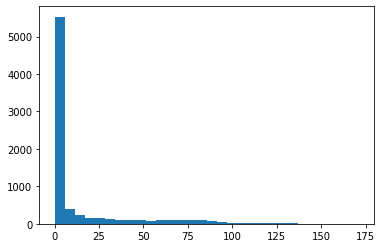

In [74]:
plt.hist(sep_calc_root,bins=30)

In [ ]:
nu_reco[mask_reco][idx].lik
nu_reco[mask_reco][idx].lik

13466
13466
13455
[44.5, 44.5, 44.5, 44.5, 42.1, 42, 28.3, ... -715, -715, -715, -714, -711, -710]


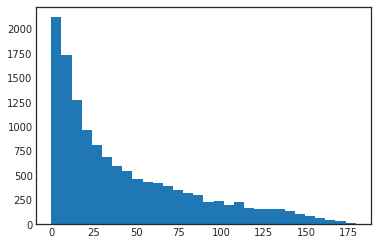

In [89]:
def angle_between_vectors(dir_x1, dir_y1, dir_z1, dir_x2, dir_y2, dir_z2):
    v1 = np.array([dir_x1, dir_y1, dir_z1])
    v2 = np.array([dir_x2, dir_y2, dir_z2])
    dot_products = np.sum(v1 * v2, axis=0)
    magnitudes_v1 = np.linalg.norm(v1, axis=0)
    magnitudes_v2 = np.linalg.norm(v2, axis=0)
    cos_angles = dot_products / (magnitudes_v1 * magnitudes_v2)
    cos_angles = np.clip(cos_angles, -1.0, 1.0)
    angles = np.arccos(cos_angles)
    angles_degrees = np.degrees(angles)
    return angles_degrees

import matplotlib.pyplot as plt

rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013292.jchain.aashower.5.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_nutau-NCHEDIS_1e2-1e8GeV.sirene.jterbr00014163.jchain.aashower.568.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)
nu = offline.mc_tracks[:, 0]
nu_reco = offline.tracks
best_fit = tools.best_aashower(nu_reco)
mask_reco = tools.has_aashower(nu_reco)

print(len(best_fit))
print(len(mask_reco))
print(len(best_fit[mask_reco]))

# Get directions for MC and Reco (ROOT)
dir_x_mc = nu[mask_reco].dir_x
dir_y_mc = nu[mask_reco].dir_y
dir_z_mc = nu[mask_reco].dir_z

dir_x_reco = best_fit[mask_reco].dir_x
dir_y_reco = best_fit[mask_reco].dir_y
dir_z_reco = best_fit[mask_reco].dir_z

# Angle between MC and Reco directions
angle = angle_between_vectors(dir_x_mc, dir_y_mc, dir_z_mc, dir_x_reco, dir_y_reco, dir_z_reco)
plt.hist(angle,bins=30)

np.set_printoptions(threshold=np.inf)
print(str(nu_reco[mask_reco][10].lik))

In [93]:
print(nu_reco[mask_reco][10].lik)
print(best_fit[mask_reco][10].lik)

[112, 112, 112, 110, 110, 110, 110, ... -245, -245, -245, -243, -242, -242, -241]
111.98176959800503


In [94]:
print(nu_reco[mask_reco][10].rec_stages)
print(best_fit[mask_reco][10].rec_stages)

[[1, 2, 3, 5, 4], [1, 2, 3, 5], ... 303, 304], [302, 303, 304], [302, 303, 304]]
[1, 2, 3, 5, 4]


In [87]:
print(nu_reco[10].lik)
print(best_fit[10].lik)

[44.5, 44.5, 44.5, 44.5, 42.1, 42, 28.3, ... -715, -715, -715, -714, -711, -710]
-710.1954596092818


In [64]:
print(offline.tracks[20,0].rec_type)
print(offline.tracks[20,0].rec_stages)

101
[302]


## Comparing ARCA and ORCA data

In [84]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools
import km3io.definitions as kd
import numpy as np

rootfilename_anue = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
rootfilename_numu = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
rootfilename_orca = "/home/hpc/capn/mppi104h/wecapstor3/out/ORCA_115/numu/reco/gsg_muon-CC_1.0-100.0GeV.1.km3sim.jte.jmergefit.root"

offline_anue = OfflineReader(rootfilename_anue)
print(offline_anue.header)
print(len(offline_anue))
# nu = offline_anue.mc_tracks[:, 0]

offline_numu = OfflineReader(rootfilename_numu)
print(offline_numu.header)
print(len(offline_numu))

offline_orca = OfflineReader(rootfilename_orca)
print(offline_orca.header)
print(len(offline_orca))

MC Header:
  DAQ(livetime=10619.2)
  GXMLPATH: /genie/genie_generator/genie_xsec
  XSecFile: /genie/genie_generator/genie_xsec/GHE19_00b_00_000.xml
  aashowerfit_detector: /sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx
  coord_site: coord_site(field_0=0.747, field_1=0.10763)
  cut_nu(Emin=100, Emax=100000000.0, cosTmin=-1, cosTmax=1)
  depth: 3450
  detector: detector(field_0='JSirene', field_1='/sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx')
  drawing: surface
  fixedcan(xcenter=25.4, ycenter=289.5, zmin=0, zmax=1042.3, radius=624.5)
  flux(type=-12, key='FUNC1', file_1='1E-5*pow(x,-2)', file_2=None)
  genvol(zmin=0, zmax=1042.3, r=624.5, volume=1330000000.0, numberOfEvents=250000)
  physics(program='GENIE', version='3.02.00', date=None, time=None)
  physics_1: physics_1(field_0='GENIE_REWEIGHT', fiel

In [86]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools

rootfilename_orca = "/home/hpc/capn/mppi104h/wecapstor3/out/ORCA_115/numu/reco/gsg_muon-CC_1.0-100.0GeV.205.km3sim.jte.jmergefit.root"
rootfilename_orca = "/home/hpc/capn/mppi104h/wecapstor3/out/ORCA_115/numu/reco/gsg_muon-CC_1.0-100.0GeV.205.km3sim.jte.jmergefit.aanet.root"

offline_orca = OfflineReader(rootfilename_orca)
print(len(offline_orca))

print(offline_orca.trks.E)
print(offline_orca.tracks.E)
print(offline_orca.mc_tracks.E)

6154
[[9.13, 7.8, 7.59, 6.66, 6.82, 0, 8.17, 8.17, 8.17, ... 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[9.13, 7.8, 7.59, 6.66, 6.82, 0, 8.17, 8.17, 8.17, ... 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[8.22, 14.9, 0.925, 14, 6.72, 2.42, ... 0.99, 0.986, 0.968, 1.05, 0.515, 3.58]]


## Combining angular resolution over energy plots for anue and numu runs

In [70]:
from astropy.table import Table

table_anue = Table.read("/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5")
table_numu = Table.read("/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5")

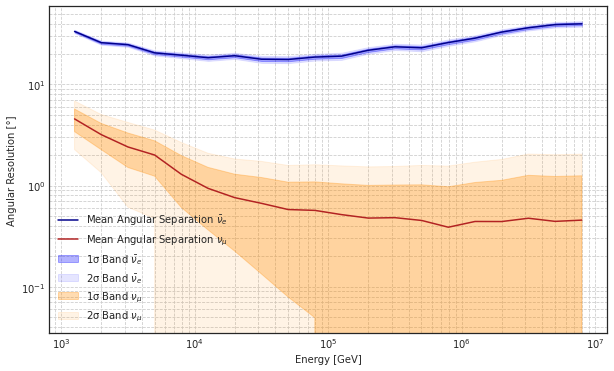

In [71]:
import matplotlib.pyplot as plt    
plt.style.use('seaborn-white')
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(table_anue['energy_bin_center'], table_anue['median_angular_separation'], color='darkblue', label=r'Mean Angular Separation $\bar{\nu}_e$')
plt.fill_between(table_anue['energy_bin_center'], table_anue['median_angular_separation'] - table_anue['sigma1_width'], table_anue['median_angular_separation'] + table_anue['sigma1_width'], color='blue', alpha=0.3, label=r'1σ Band $\bar{\nu}_e$')
plt.fill_between(table_anue['energy_bin_center'], table_anue['median_angular_separation'] - 2*table_anue['sigma1_width'], table_anue['median_angular_separation'] + 2*table_anue['sigma1_width'], color='blue', alpha=0.1, label=r'2σ Band $\bar{\nu}_e$')

plt.plot(table_numu['energy_bin_center'], table_numu['median_angular_separation'], color='firebrick', label=r'Mean Angular Separation $\nu_{\mu}$')
plt.fill_between(table_numu['energy_bin_center'], table_numu['median_angular_separation'] - table_numu['sigma1_width'], table_numu['median_angular_separation'] + table_numu['sigma1_width'], color='darkorange', alpha=0.3, label=r'1σ Band $\nu_{\mu}$')
plt.fill_between(table_numu['energy_bin_center'], table_numu['median_angular_separation'] - 2*table_numu['sigma1_width'], table_numu['median_angular_separation'] + 2*table_numu['sigma1_width'], color='darkorange', alpha=0.1, label=r'2σ Band $\nu_{\mu}$')

# plt.axhline(y=0.1, color='orange', linewidth=4)  # Example of a horizontal line
plt.xscale('log')
plt.yscale('log')
#plt.ylim([1e-4,1e2])
plt.xlabel('Energy [GeV]')
plt.ylabel('Angular Resolution [°]')
# plt.title(f'Angular Resolution vs Energy for {reco_name} Reco Type ({run_type}, {len(filtered_table)} events)')
plt.legend()
plt.grid(True, which="both", ls="--")

output_plotname = "../../TestPlotAngularRes_anue_and_numu_log-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.png"
plt.savefig(output_plotname)


## Looking at angular separations from all fits for a given event

In [80]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io.tools import angle_between
from km3io import tools
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import astropy.units as u

idx = 20

def separations_allfits(nu,nu_reco,mask_reco,idx):

    dir_x_reco = nu_reco[mask_reco][idx].dir_x
    dir_y_reco = nu_reco[mask_reco][idx].dir_y
    dir_z_reco = nu_reco[mask_reco][idx].dir_z

    # Convert awkward arrays to NumPy arrays
    dir_x_reco = ak.to_numpy(dir_x_reco)
    dir_y_reco = ak.to_numpy(dir_y_reco)
    dir_z_reco = ak.to_numpy(dir_z_reco)

    # Combine reco directions into full vectors
    dir_reco = np.column_stack((dir_x_reco, dir_y_reco, dir_z_reco))

    # Generate mc vector for each reco vector
    dir_x_mc = np.full_like(dir_x_reco,nu[mask_reco][idx].dir_x)
    dir_y_mc = np.full_like(dir_y_reco,nu[mask_reco][idx].dir_y)
    dir_z_mc = np.full_like(dir_z_reco,nu[mask_reco][idx].dir_z)

    dir_mc = np.column_stack((dir_x_mc, dir_y_mc, dir_z_mc))

    # Compute angles for all fits using the angle_between function
    angles = angle_between(dir_mc, dir_reco, axis=1)*u.rad

    return angles.to(u.deg)

def compare_separation_allfits(offline,rec_type,idx):

    nu = offline.mc_tracks[:, 0]
    nu_reco = offline.tracks

    if rec_type == "jmuon":
        best_fit = tools.best_jmuon(nu_reco)
        mask_reco = tools.has_jmuon(nu_reco)
    elif rec_type == "aashower":
        best_fit = tools.best_aashower(nu_reco)
        mask_reco = tools.has_aashower(nu_reco)        
    else: print("only jmuon and aashower possible...")
    
    sep = separations_allfits(nu,nu_reco,mask_reco,idx)
    sep_bf = separations_allfits(nu,best_fit,mask_reco,idx)

    plt.hist(sep.value,bins=30,label=f"All Recos Event Nr. {idx}")
    plt.axvline(sep_bf.value,lw=2,c="k",ls="dashed", label=f"best_fit Reco Event Nr. {idx}")
    plt.xlabel("Angular Separation in deg")
    plt.legend()
    plt.xlim([-5,185])

    plt.show()  # Show the plot  # Display the plot for 3 seconds
    plt.close()  # Close the plot

    return sep, sep_bf

### anue and aashower

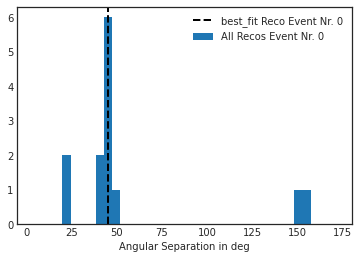

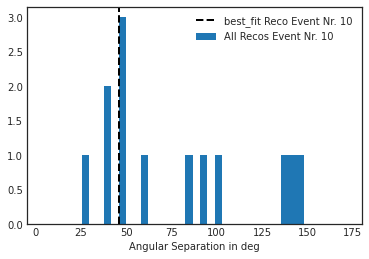

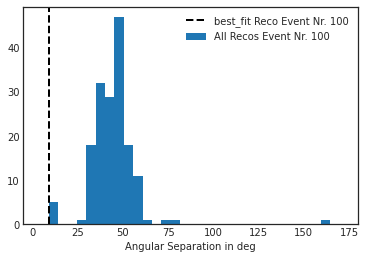

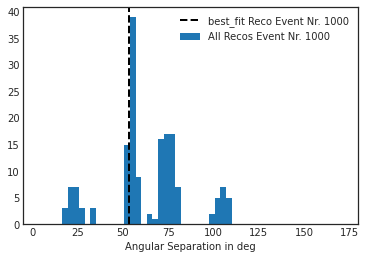

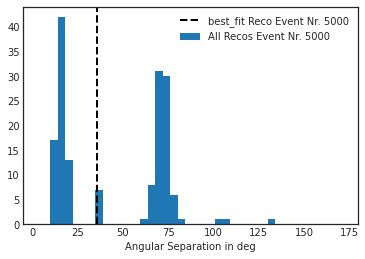

In [81]:
rec_type = "aashower"
rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"
offline = OfflineReader(rootfilename)

for idx in [0,10,100,1000,5000]:
    compare_separation_allfits(offline,rec_type,idx)

### munu and jmuon

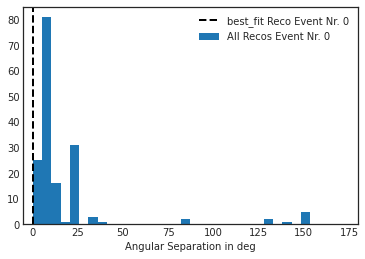

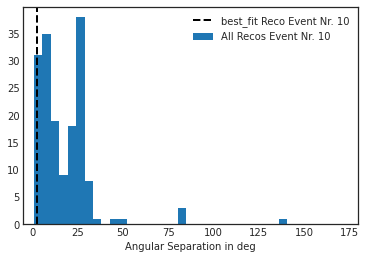

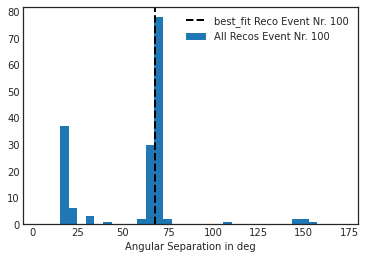

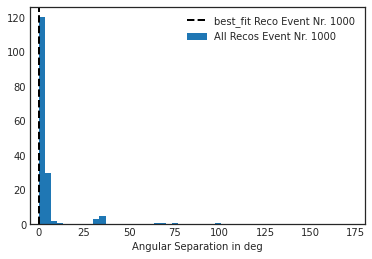

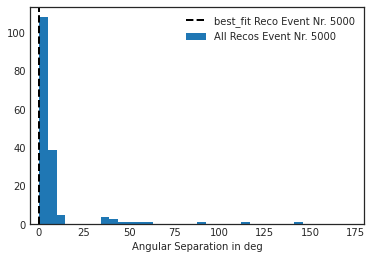

In [82]:
rec_type = "jmuon"
rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)

for idx in [0,10,100,1000,5000]:
    compare_separation_allfits(offline,rec_type,idx)

## Making event identifier

In [18]:
from km3io import OfflineReader
from km3astro.io import load_hdf5_tables
from km3io import tools
import km3io.definitions as kd
import numpy as np
import re

rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013292.jchain.aashower.5.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/mcv8.1.gsg_nutau-NCHEDIS_1e2-1e8GeV.sirene.jterbr00014163.jchain.aashower.568.root"
# rootfilename = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

offline = OfflineReader(rootfilename)

nu = offline.mc_tracks[:, 0]
nu_reco = offline.tracks

print(offline)
print(len(offline))
def extract_detector_id(offline):
    detector_info = offline.header.detector[1]
    detector_id_match = re.search(r"KM3NeT_(\d+_\d+)\.detx", detector_info)
    if detector_id_match:
        detector_id = detector_id_match.group(1)
    else:
        raise ValueError("Detector ID not found in header.")
    
    # Extract run id from the filename
    run_id_match = re.search(r"jterbr(\d+)\.jchain", offline.filename)
    if run_id_match:
        run_id = run_id_match.group(1)
    else:
        raise ValueError("Run ID not found in filename.")
    
    # Combine to form the unique identifier
    det_run_id = f"{detector_id}_{run_id}_"
    return det_run_id

#extract_detector_id(offline)

<OfflineReader [13466] path='E/Evt'>
13466


In [15]:
def extract_det_run_id(offline,rootfilename):
    """
    Extracts the detector ID and run ID from the provided file and header information.
    
    Parameters:
    -----------
    rootfilename : str
        The full path of the root file which contains the run ID as part of the filename.
    offline : object
        An instance of the OfflineReader object, which contains the event data and header information.
    
    Returns:
    --------
    det_run_id : str
        A string in the format "detectorid_runid_" where:
        - detectorid is extracted from the header information (e.g., '00000133_20221025').
        - runid is extracted from the filename (e.g., '00013292').
        
    Raises:
    -------
    ValueError
        If the detector ID or run ID cannot be found.
    
    Example:
    --------
    rootfilename = "/path/to/file/KM3NeT_00000133/v8.1/reco/mcv8.1.sirene.jterbr00013292.jchain.aashower.5.root"
    offline = OfflineReader(rootfilename)
    
    det_run_id = extract_detector_id(rootfilename, offline)
    # Output: "00000133_20221025_00013292_"
    """
    
    # Extract detector id from the header
    detector_info = offline.header.detector[1]
    
    # Use regex to extract the detector id in the form of '00000133_20221025'
    detector_id_match = re.search(r"KM3NeT_(\d+_\d+)\.detx", detector_info)
    
    if detector_id_match:
        detector_id = detector_id_match.group(1)
    else:
        raise ValueError("Detector ID not found in header.")
    
    # Extract run id from the filename using regex
    run_id_match = re.search(r"jterbr(\d+)\.jchain", rootfilename)
    
    if run_id_match:
        run_id = run_id_match.group(1)
    else:
        raise ValueError("Run ID not found in filename.")
    
    # Combine the detector id and run id into the required format
    det_run_id = f"{detector_id}_{run_id}_"
    
    return det_run_id

def generate_id_table(OfflineObject,rootfilename,evt_ids_start=0):
    """
    Generate event IDs and Monte Carlo data astropy tables from the given file.

    Parameters
    ----------
    OfflineObject : km3io.offline.OfflineReader
        OfflineReader object representing the input file.
    evt_ids_start : int, optional
        Starting event ID.

    Returns
    -------
    tuple
        Tuple containing ID table, event IDs as numpy array, and timeslices.
        - ID table : astropy.table.Table
            Table containing Event_ID and Timeslice_UTC_Time columns.
        - event_ids_np : numpy.ndarray
            Array of event IDs.
        - timeslices : list
            List of timeslices in seconds.
    """
    # Setting up event ids
    event_ids = range(evt_ids_start,len(OfflineObject)+evt_ids_start)
    event_ids_np = np.array(event_ids)
    #print(f"{event_ids = }")

    # Getting utc time of the timeslice the events were triggered
    timeslices, astropy_timeslices = get_utc_timeslice(OfflineObject)

    det_run_id = extract_det_run_id(OfflineObject,rootfilename)
    id_strings = [f"{det_run_id}{str(event_id).zfill(8)}" for event_id in event_ids_np]

    id_table = Table([event_ids_np,astropy_timeslices,id_strings],names=['event_id','timeslice_utc_time','id_string'])
    #print("id_table created ...")

    return id_table, event_ids_np, timeslices

In [16]:
#from km3astro.io import get_utc_timeslice
#from km3astro.io import *

id_table, event_ids, timeslices = generate_id_table(offline, rootfilename, 0)

TypeError: object of type 'module' has no len()

In [4]:
"""
io.py
Converting km3net root files to astropy tables in hdf5 files
High-level data relevant for astro analyses is extracted and saved

author: 
Hannes Warnhofer 
hannes.warnhofer@fau.de

"""

import os
import re

import time
from h5py import File, Group
#import h5py

import awkward as ak
import numpy as np

#from numpy import array, full_like, transpose, uint64

from km3io import offline
from km3io import tools
import km3io.definitions as kd
import datetime
import astropy.units as u
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5


def dir_to_spherical(tracks):
    """
    Convert directional coordinates (x, y, z) to spherical coordinates (theta, phi).

    Parameters
    ----------
    tracks : numpy.array
        Array containing track information, OfflineReader.tracks object

    Returns
    -------
    tuple
        Tuple containing spherical coordinates (theta, phi).
    """
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def get_utc_timeslice(OfflineObject):

    """
    Calculate UTC time of the timeslices where the events were put based on input data.

    Parameters:
    ----------
    OfflineObject : km3io.offline.OfflineReader
        Input data. Offline data runs: km3io.offline.OfflineReader Object.
    
    Returns:
    ----------
    tuple
        Tuple containing:
        - times : list
            List of UTC timeslices in seconds
        - astropy_times : list
            List of astropy.time.Time objects of times
    """
    tsec = OfflineObject.t_sec
    tns = OfflineObject.t_ns
    S_TO_NS = np.uint64(1e9)

    print("calculating timesclices ...")

    times = tsec + tns/S_TO_NS   # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(tsec,tns/S_TO_NS,format='unix')

    return times, astropy_times 

  

def get_utc_tracktime(timeslice,tracktimes):
    """
    Calculate UTC time of the track times based on timeslices and track times.

    Parameters:
    ----------
    timeslice : list
        List of timeslices in seconds.
    tracktimes : list
        List of track times in nanoseconds.

    Returns:
    ----------
    tuple
        Tuple containing:
        - times : list
            List of UTC track times in seconds.
        - astropy_times : list
            List of astropy.time.Time objects of track times.
    """
    S_TO_NS = np.uint64(1e9)

    print("calculating tracktimes ...")

    times = timeslice + tracktimes/S_TO_NS   # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(timeslice,tracktimes/S_TO_NS,format='unix')

    return times, astropy_times    


def dump_header(OfflineObject):
    """
    Create an astropy table containing header information from a file.

    Parameters
    ----------
    OfflineObject : km3io.offline.OfflineReader
        OfflineReader object representing the input file.

    Returns
    -------
    astropy.table.Table
        Table containing header information converted to strings.
    """
    # Create an empty table
    header_table = Table(names=['Parameter', 'Value'], dtype=[str, str])

    # Loop through each attribute of the header object and add it to the table
    for key in dir(OfflineObject.header):
        header_table.add_row([key, str(getattr(OfflineObject.header, key))])
    print("header_table created ...")

    return header_table

def extract_det_run_id(offline,rootfilename):
    """
    Extracts the detector ID and run ID from the provided file and header information.
    
    Parameters:
    -----------
    rootfilename : str
        The full path of the root file which contains the run ID as part of the filename.
    offline : object
        An instance of the OfflineReader object, which contains the event data and header information.
    
    Returns:
    --------
    det_run_id : str
        A string in the format "detectorid_runid_" where:
        - detectorid is extracted from the header information (e.g., '00000133_20221025').
        - runid is extracted from the filename (e.g., '00013292').
        
    Raises:
    -------
    ValueError
        If the detector ID or run ID cannot be found.
    
    Example:
    --------
    rootfilename = "/path/to/file/KM3NeT_00000133/v8.1/reco/mcv8.1.sirene.jterbr00013292.jchain.aashower.5.root"
    offline = OfflineReader(rootfilename)
    
    det_run_id = extract_detector_id(rootfilename, offline)
    # Output: "00000133_20221025_00013292_"
    """
    
    # Extract detector id from the header
    detector_info = offline.header.detector[1]
    
    # Use regex to extract the detector id in the form of '00000133_20221025'
    detector_id_match = re.search(r"KM3NeT_(\d+_\d+)\.detx", detector_info)
    
    if detector_id_match:
        detector_id = detector_id_match.group(1)
    else:
        raise ValueError("Detector ID not found in header.")
    
    # Extract run id from the filename using regex
    run_id_match = re.search(r"jterbr(\d+)\.jchain", rootfilename)
    
    if run_id_match:
        run_id = run_id_match.group(1)
    else:
        raise ValueError("Run ID not found in filename.")
    
    # Combine the detector id and run id into the required format
    det_run_id = f"{detector_id}_{run_id}_"
    
    return det_run_id

def generate_id_table(OfflineObject,rootfilename,evt_ids_start=0):
    """
    Generate event IDs and Monte Carlo data astropy tables from the given file.

    Parameters
    ----------
    OfflineObject : km3io.offline.OfflineReader
        OfflineReader object representing the input file.
    evt_ids_start : int, optional
        Starting event ID.

    Returns
    -------
    tuple
        Tuple containing ID table, event IDs as numpy array, and timeslices.
        - ID table : astropy.table.Table
            Table containing Event_ID and Timeslice_UTC_Time columns.
        - event_ids_np : numpy.ndarray
            Array of event IDs.
        - timeslices : list
            List of timeslices in seconds.
    """
    # Setting up event ids
    event_ids = range(evt_ids_start,len(OfflineObject)+evt_ids_start)
    event_ids_np = np.array(event_ids)
    #print(f"{event_ids = }")

    # Getting utc time of the timeslice the events were triggered
    timeslices, astropy_timeslices = get_utc_timeslice(OfflineObject)

    det_run_id = extract_det_run_id(OfflineObject,rootfilename)
    id_strings = [f"{det_run_id}{str(event_id).zfill(8)}" for event_id in event_ids_np]

    id_table = Table([event_ids_np,astropy_timeslices,id_strings],names=['event_id','timeslice_utc_time','id_string'])
    #print("id_table created ...")

    return id_table, event_ids_np, timeslices

def generate_mc_table(OfflineObject,evt_ids):
    """
    Generate monte carlo data astropy table

    Parameters
    ----------
    OfflineObject: km3io.OfflineReader 
        OfflineReader Object representing the input file.
    evt_ids: numpy.array
        Array containing event IDs.
    
    Returns
    -------
    astropy.table.Table
        astropy table containing mc data.
    """

    # Getting mc neutrino
    nu = OfflineObject.mc_trks[:, 0]
    # Getting energy and origin of the neutrino
    E = nu.E.to_numpy()
    pdgid = nu.pdgid.to_numpy()
    theta, phi = dir_to_spherical(nu)
    posx = nu.pos_x.to_numpy()
    posy = nu.pos_y.to_numpy()
    posz = nu.pos_z.to_numpy()
    weight = OfflineObject.w.to_numpy()[:,1] # check km3net dataformat definitions w2list
    num_gen_events = OfflineObject.header.genvol.numberOfEvents
    norm_weight = weight/num_gen_events

    mc_table = Table([evt_ids, E*u.GeV, pdgid, norm_weight, theta*u.rad, phi*u.rad, posx,posy,posz],
                    names=['event_id', 'energy','pdg_id', 'normalized_weight', 'theta_detectorframe', 'phi_detectorframe','pos_x','pos_y','pos_z'])
    #print("mc_table created ...")
    return mc_table

def generate_reco_table(OfflineObject,evt_ids,timeslices,reco_types):
    """
    Generate reconstruction data astropy tables for specified reconstruction types.

    Parameters
    ----------
    OfflineObject : km3io.offline.OfflineReader
        OfflineReader object representing the input file.
    evt_ids : numpy.array
        Array containing event IDs.
    timeslices : list
        List of timeslices in seconds.
    reco_types : list of str
        List of reconstruction types. Allowed types: 'jmuon','jshower','aashower','dusjshower'.

    Returns
    -------
    astropy.table.Table
        Combined reconstruction table.
    """
    reco_tables = []
    for reco_type in reco_types:
        # Fetching best fits for the current reconstruction type
        print(f"dealing with {reco_type} reco_type ...")
        if reco_type == 'jmuon':
            if any(element is not False for element in tools.has_jmuon(OfflineObject.tracks)) == False:
                print(f"No {reco_type} reconstructions for this file!")
                continue
            else:
                best_fit = tools.best_jmuon(OfflineObject.tracks)
                reco_type_id = kd.reconstruction.JPP_RECONSTRUCTION_TYPE #'JPP_RECONSTRUCTION_TYPE'
                reco_stage_id = kd.reconstruction.JMUONBEGIN #'JMUONBEGIN'
                mask_reco = tools.has_jmuon(OfflineObject.tracks)

        elif reco_type == 'aashower':
            if any(element is not False for element in tools.has_aashower(OfflineObject.tracks)) == False:
                print(f"No {reco_type} reconstructions for this file!")
                continue
            else:
                best_fit = tools.best_aashower(OfflineObject.tracks)
                reco_type_id = kd.reconstruction.AANET_RECONSTRUCTION_TYPE #'AANET_RECONSTRUCTION_TYPE'
                reco_stage_id = kd.reconstruction.AASHOWERBEGIN #'AASHOWERBEGIN'
                mask_reco = tools.has_aashower(OfflineObject.tracks)

        elif reco_type == 'jshower':
            if any(element is not False for element in tools.has_jshower(OfflineObject.tracks)) == False:
                print(f"No {reco_type} reconstructions for this file!")
                continue
            else:
                best_fit = tools.best_jshower(OfflineObject.tracks)
                reco_type_id = kd.reconstruction.JPP_RECONSTRUCTION_TYPE #'JPP_RECONSTRUCTION_TYPE'
                reco_stage_id = kd.reconstruction.JSHOWERBEGIN #'JSHOWERBEGIN'
                mask_reco = tools.has_jshower(OfflineObject.tracks)

        elif reco_type == 'dusjshower':
            if any(element is not False for element in tools.has_dusjshower(OfflineObject.tracks)) == False:
                print(f"No {reco_type} reconstructions for this file!")
                continue
            else:
                best_fit = tools.best_dusjshower(OfflineObject.tracks)
                reco_type_id = kd.reconstruction.DUSJ_RECONSTRUCTION_TYPE  #'DUSJ_RECONSTRUCTION_TYPE'
                reco_stage_id = kd.reconstruction.DUSJSHOWERBEGIN  #'DUSJSHOWERBEGIN'
                mask_reco = tools.has_dusjshower(OfflineObject.tracks)
        
        #print(reco_type_id)

        best_fit = best_fit[mask_reco]
        event_ids_reco = evt_ids[mask_reco]

        # Extracting data from the best fits
        E = best_fit.E.to_numpy()
        lik = best_fit.lik.to_numpy()
        timedata = best_fit.t.to_numpy() # ns
        theta, phi = dir_to_spherical(best_fit)
        posx = best_fit.pos_x.to_numpy()
        posy = best_fit.pos_y.to_numpy()
        posz = best_fit.pos_z.to_numpy()
        reco_type_id_reco = np.full_like(event_ids_reco, reco_type_id)
        reco_stage_id_reco = np.full_like(event_ids_reco, reco_stage_id)

   

        # Calculating UTC tracktimes
        utc_tracktimes, astropy_utc_tracktimes = get_utc_tracktime(np.array(timeslices)[mask_reco],timedata)


        # Creating table for current reconstruction type
        reco_table = Table([event_ids_reco,
                            reco_type_id_reco,
                            reco_stage_id_reco,
                            astropy_utc_tracktimes,
                            timedata *u.ns,
                            E * u.GeV,
                            lik,
                            theta * u.rad,
                            phi * u.rad,
                            posx,
                            posy,
                            posz],
                           names=['event_id', 'rec_type', 'rec_stage', 'tracktime_utc' ,'tracktime_ns', 'energy', 'likelihood',
                                  'theta_detectorframe', 'phi_detectorframe','pos_x','pos_y','pos_z'])
        reco_tables.append(reco_table)
    
    reco_tables_combined = vstack(reco_tables)
    reco_tables_combined.sort('event_id')
    print("reco_table created ...")
    return reco_tables_combined

def check_for_mc(OfflineObject):
    """
    Check if the file contains Monte Carlo (MC)-generated or real data based on the entries in mc_trks.id.

    Parameters
    ----------
    OfflineObject : km3io.offline.OfflineReader
        OfflineReader object representing the input file.

    Returns
    -------
    bool
        True if the file contains MC-generated data, False otherwise.
    """
    ids = OfflineObject.mc_trks.id
    if ak.any(ids):
        print("The file contains MC-generated data.")
        return True
    else:
        print("The file contains real data. Or at least doesn't have any entries in mc_trks.id ...")
        return False

def root_to_hdf5(file_path, reco_types = ['jmuon','aashower','jshower','dusjshower'], output_file = None, event_ids_start = 0):
    """
    Load a KM3NeT offline file, process it to extract high-level data that is relevant for astrophysical analysis in various astropy tables, and store them in an HDF5 file.

    Parameters
    ----------
    file_path : str
        Path to the input file.
    reco_types : list of str, optional
        List of reconstruction types. Allowed types: 'jmuon','jshower','aashower','dusjshower'.
        Default: ['jmuon','aashower','jshower','dusjshower']
    h5path : str, optional
        Path for storing the HDF5 file. Default: "OutputTables/"
    event_ids_start : int, optional
        Starting event ID. Default: 0

    Returns
    -------
    None
    """
    start_time = time.time()

    # Accessing the filename of the root file in order to match the name of the hdf5 file that gets created
    folder_path, file_name = os.path.split(file_path) 
    file_name = os.path.splitext(file_name)[0]
    if output_file == None:
        combined_table_path = file_name + ".h5"
    else: combined_table_path = output_file
    # Loading offline data with the km3io OfflineReader
    OfflineObject = offline.OfflineReader(file_path)

    # Checking if the data contains mc information that can be written or not
    is_mc_data = check_for_mc(OfflineObject)

    # Generating the individual tables
    header_table = dump_header(OfflineObject)
    id_table, event_ids, timeslices = generate_id_table(OfflineObject, file_name, event_ids_start)
    reco_table = generate_reco_table(OfflineObject, event_ids, timeslices, reco_types)
    if is_mc_data == True: 
        mc_table = generate_mc_table(OfflineObject, event_ids)

    # Writing the tables to a hdf5 file
    with File(combined_table_path, "w") as h5file:
        reco_grp = h5file.create_group("RECO")
        write_table_hdf5(header_table, h5file, path='HEADER', serialize_meta=True)  
        write_table_hdf5(id_table, h5file, path='ID', serialize_meta=True)
        write_table_hdf5(reco_table, reco_grp, path="RECO_EVENTS", serialize_meta=True) 
        if is_mc_data == True: 
            mc_grp = h5file.create_group("MC")
            write_table_hdf5(mc_table, mc_grp, path='MC_EVENTS', serialize_meta=True)
    print(f"File written: {combined_table_path}") 

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total time: {elapsed_time:.3f} seconds")


def load_hdf5_tables(file_path):
    """
    Load an HDF5 file and assign tables to an object.
    The function expects a file that is generated with astropy_hdf5_from_root() and has the paths 'HEADER','ID','RECO_EVENTS' and optionally 'MC_EVENTS'

    Parameters
    ----------
    file_path : str
        Path to the HDF5 file.

    Returns
    -------
    object
        An object containing attributes header_table, id_table, reco_table, and optionally mc_table.
    """
    tables = type('Tables', (), {})()  # Creating an empty object
    
    try:
        with File(file_path, "r") as h5file:
            tables.header_table = read_table_hdf5(h5file, path='HEADER')
            tables.id_table = read_table_hdf5(h5file, path='ID')
            tables.reco_table = read_table_hdf5(h5file, path='RECO/RECO_EVENTS')
            if '/MC_EVENTS' in h5file:
                tables.mc_table = read_table_hdf5(h5file, path='MC/MC_EVENTS')
            else:
                tables.mc_table = None
    except Exception as e:
        print(f"Error loading tables from {file_path}: {e}")
    
    return tables



In [19]:
table = load_hdf5_tables("/home/hpc/capn/capn107h/software/hdf5TestOutput/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013289.jchain.aashower.2_arca.h5")
table.header_table


Parameter,Value
bytes20,bytes178
DAQ,DAQ(livetime=10734.7)
GXMLPATH,/genie/genie_generator/genie_xsec
XSecFile,/genie/genie_generator/genie_xsec/GHE19_00b_00_000.xml
aashowerfit_detector,/sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx
coord_site,"coord_site(field_0=0.747, field_1=0.10763)"
cut_nu,"cut_nu(Emin=100, Emax=100000000.0, cosTmin=-1, cosTmax=1)"
depth,3450
detector,"detector(field_0='JSirene', field_1='/sps/km3net/repo/data_processing/tag/v8.1/data_processing/prod/mc/atm_neutrino/KM3NeT_00000133/v8.1/detectors/KM3NeT_00000133_20221025.detx')"
drawing,surface


In [18]:
table.id_table

event_id,timeslice_utc_time,track_score
int64,object,float64
0,1663869599.9119463,0.3068394708547545
1,1663869601.6196718,0.15687403017320145
2,1663869605.0726724,0.9168172980940064
3,1663869605.199402,0.2668260582085824
4,1663869606.1838815,0.2831334955935617
5,1663869609.755495,0.8104667890989748
6,1663869611.153087,0.6377523293511058
7,1663869611.1416118,0.8371629002449404
8,1663869611.5293422,0.16912426976735162


In [ ]:
tab

In [10]:
print(table.__dict__)

{'header_table': <Table length=25>
     Parameter       ...
      bytes20        ...
-------------------- ...
                 DAQ ...
            GXMLPATH ...
            XSecFile ...
aashowerfit_detector ...
          coord_site ...
              cut_nu ...
               depth ...
            detector ...
             drawing ...
            fixedcan ...
                 ... ...
           physics_3 ...
           physics_4 ...
             primary ...
                seed ...
               simul ...
             simul_1 ...
         source_mode ...
            spectrum ...
           start_run ...
       time_interval ..., 'id_table': <Table length=8913>
event_id timeslice_utc_time
 int64         object      
-------- ------------------
       0 1663869599.9119463
       1 1663869601.6196718
       2 1663869605.0726724
       3  1663869605.199402
       4 1663869606.1838815
       5  1663869609.755495
       6  1663869611.153087
       7 1663869611.1416118
       8 1663869611.5293

In [21]:
print(id_table)

event_id timeslice_utc_time              id_string             
-------- ------------------ -----------------------------------
       0   1663902000.09402 00000133_20221025_00013292_00000000
       1 1663902000.3225298 00000133_20221025_00013292_00000001
       2 1663902000.6847925 00000133_20221025_00013292_00000002
       3 1663902002.3706503 00000133_20221025_00013292_00000003
       4 1663902002.9682488 00000133_20221025_00013292_00000004
       5 1663902003.2058468 00000133_20221025_00013292_00000005
       6 1663902003.5565996 00000133_20221025_00013292_00000006
       7  1663902006.532908 00000133_20221025_00013292_00000007
       8 1663902008.0681603 00000133_20221025_00013292_00000008
       9 1663902008.5221014 00000133_20221025_00013292_00000009
     ...                ...                                 ...
   13455 1663912791.5173242 00000133_20221025_00013292_00013455
   13456 1663912792.8002577 00000133_20221025_00013292_00013456
   13457  1663912792.902023 00000133_202

In [ ]:
""" Combines multiple eventlist objects generated from KM3NeT data to a single one.

Usage: CombineEventListsKM3NeT.py -i INPUT_FILES... -o OUTPUT_DIR 

Options:
  -h --help                              Show this help message
  -i --input_files INPUT_FILES...        Input files
  -o --output_dir OUTPUT_DIR             Output directory  
"""

# python3 psr/src/scripts/CombineEventListsKM3NeT.py -i "/home/hpc/capn/capn107h/software/correctedeventlistTestOutput/*" -o combinedeventlistTestOutput/


from docopt import docopt
import os
import glob
import h5py
import numpy as np
from astropy.table import vstack, Table
import plens.EventList as EL

def main():
    arguments = docopt(__doc__)

    input_files = arguments['--input_files']
    output_dir = arguments['--output_dir']

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    CombinedEventList = None

    for file in input_files:
        with h5py.File(file, 'r') as h5_file:
            EventList = EL.readEventList(h5_file)

            if CombinedEventList is None:
                CombinedEventList = EventList
            else:
                CombinedEventList = vstack([CombinedEventList,EventList])
            
    CombinedEventList.sort("time")
    print("CombinedEventlist:")
    print(CombinedEventList)

    # Extract common prefix from input filenames
    common_prefix = os.path.commonprefix(input_files)
    # Remove any trailing non-alphanumeric characters from common prefix
    common_prefix = os.path.basename(common_prefix).rstrip("_-.")
    if not common_prefix:
        common_prefix = "Test"
    output_file = os.path.join(output_dir, f"{common_prefix}_combined_eventlist.hdf5")


    # Save the combined EventList
    CombinedEventList.write(output_file, format='hdf5', path='data', overwrite=True, serialize_meta = True)
    print(f"Combined EventList saved to {output_file}")

    
if __name__ == "__main__":
    main()

In [ ]:
def extract_det_run_id(offline,rootfilename):
    """
    Extracts the detector ID and run ID from the provided file and header information.
    
    Parameters:
    -----------
    rootfilename : str
        The full path of the root file which contains the run ID as part of the filename.
    offline : object
        An instance of the OfflineReader object, which contains the event data and header information.
    
    Returns:
    --------
    det_run_id : str
        A string in the format "detectorid_runid_" where:
        - detectorid is extracted from the header information (e.g., '00000133_20221025').
        - runid is extracted from the filename (e.g., '00013292').
        
    Raises:
    -------
    ValueError
        If the detector ID or run ID cannot be found.
    
    Example:
    --------
    rootfilename = "/path/to/file/KM3NeT_00000133/v8.1/reco/mcv8.1.sirene.jterbr00013292.jchain.aashower.5.root"
    offline = OfflineReader(rootfilename)
    
    det_run_id = extract_detector_id(rootfilename, offline)
    # Output: "00000133_20221025_00013292_"
    """
    
    # Extract detector id from the header
    detector_info = offline.header.detector[1]
    
    # Use regex to extract the detector id in the form of '00000133_20221025'
    detector_id_match = re.search(r"KM3NeT_(\d+_\d+)\.detx", detector_info)
    
    if detector_id_match:
        detector_id = detector_id_match.group(1)
    else:
        raise ValueError("Detector ID not found in header.")
    
    # Extract run id from the filename using regex
    run_id_match = re.search(r"jterbr(\d+)\.jchain", rootfilename)
    
    if run_id_match:
        run_id = run_id_match.group(1)
    else:
        raise ValueError("Run ID not found in filename.")
    
    # Combine the detector id and run id into the required format
    det_run_id = f"{detector_id}_{run_id}_"
    
    return det_run_id

## Fit Function to Angular Resolution

In [36]:
from astropy.table import Table
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Function for the first case: angular resolution decreases and then flattens.
def logistic_function(E, a, b, c, d):
    return a / (1.0 + np.exp(-b * (np.log10(E) - c))) + d

# Function for the second case: sinusoidal variation.
def sinusoidal_function(E, a, b, c, d):
    return a * np.sin(b * np.log10(E) + c) + d

# Function to read HDF5 file using Astropy and fit the data to a model, with sigma1 for better fit
def fit_angular_resolution(file_path, fit_type="logistic"):
    # Read the data from the HDF5 file using Astropy Table
    table = Table.read(file_path, format='hdf5')

    # Access the columns by their names
    energy_bin_centers = table['energy_bin_center']
    angular_resolution = table['median_angular_separation']
    sigma1_width = table['sigma1_width']  # Assuming this is the uncertainty

    # Fit the data based on the requested fit type
    if fit_type == "logistic":
        # Initial guesses for the logistic function parameters
        popt, _ = curve_fit(logistic_function, energy_bin_centers, angular_resolution, 
                            p0=[3.5, 1, 4, 0.5], sigma=sigma1_width, absolute_sigma=True, maxfev=10000)
        fit_func = lambda E: logistic_function(E, *popt)
    elif fit_type == "sinusoidal":
        # Initial guesses for the sinusoidal function parameters
        popt, _ = curve_fit(sinusoidal_function, energy_bin_centers, angular_resolution, 
                            p0=[5, 1, 0, 25], sigma=sigma1_width, absolute_sigma=True, maxfev=10000)
        fit_func = lambda E: sinusoidal_function(E, *popt)
    else:
        raise ValueError("Unknown fit type. Choose 'logistic' or 'sinusoidal'.")
    
    # Plot the data and the fit
    plt.figure(figsize=(8, 6))
    plt.errorbar(energy_bin_centers, angular_resolution, yerr=sigma1_width, fmt='bo', label='Data', capsize=5)
    energy_fit = np.logspace(3, 7, 1000)  # Energy values for plotting the fit
    plt.plot(energy_fit, fit_func(energy_fit), 'r-', label='Fit')

    # Add a shaded 1σ band for uncertainties (optional, depends on your data)
    sigma1_band_lower = angular_resolution - sigma1_width  # Example: replace sigma1_values with your actual 1σ uncertainties
    sigma1_band_upper = angular_resolution + sigma1_width
    plt.fill_between(energy_bin_centers, sigma1_band_lower, sigma1_band_upper, color='blue', alpha=0.3, label='1σ Band')

    # Add a shaded 2σ band for uncertainties (optional)
    sigma2_band_lower = angular_resolution - 2*sigma1_width   # Example: replace sigma2_values with your actual 2σ uncertainties
    sigma2_band_upper = angular_resolution + 2*sigma1_width
    plt.fill_between(energy_bin_centers, sigma2_band_lower, sigma2_band_upper, color='blue', alpha=0.1, label='2σ Band')


    plt.xscale('log')
    # Customize labels and title
    plt.xlabel('Energy [GeV]', fontsize=12)
    plt.ylabel('Angular Resolution [°]', fontsize=12)
    plt.title(f'Angular Resolution vs Energy ({reco_name} Reco Type)', fontsize=14)

    plt.legend()
    plt.show()

    return fit_func

# Example usage
# fit_func1 = fit_angular_resolution('/path/to/your/file1.h5', fit_type="logistic")
# fit_func2 = fit_angular_resolution('/path/to/your/file2.h5', fit_type="sinusoidal")

# Now you can use fit_func1(energy_value) or fit_func2(energy_value) to get angular resolution




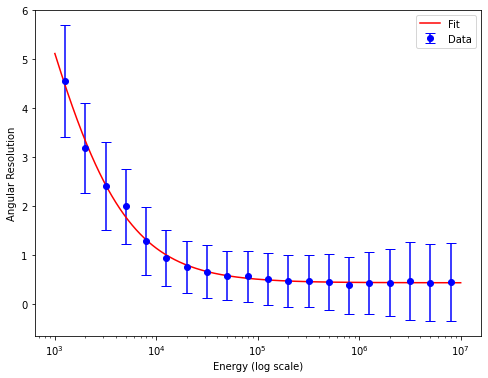

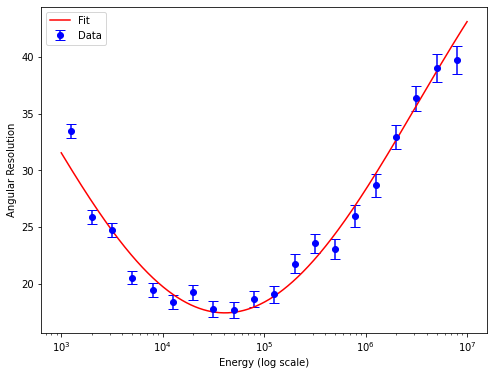

In [37]:
fit_func1 = fit_angular_resolution('/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5', fit_type="logistic")
fit_func2 = fit_angular_resolution('/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5', fit_type="sinusoidal")

# Now you can use fit_func1(energy_value) or fit_func2(energy_value) to get angular resolution

In [30]:
import h5py

def inspect_hdf5(file_path):
    with h5py.File(file_path, 'r') as f:
        # Recursively print the structure of the HDF5 file
        def print_structure(name, obj):
            print(name)
        
        f.visititems(print_structure)

# Example usage
inspect_hdf5('/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5')


__astropy_table__
__astropy_table__.__table_column_meta__


In [1]:
from astropy.table import Table
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Polynomial functions
def cubic_polynomial(E, a, b, c, d):
    return a * np.log10(E)**3 + b * np.log10(E)**2 + c * np.log10(E) + d

def quintic_polynomial(E, a, b, c, d, e, f):
    return a * np.log10(E)**4 + b * np.log10(E)**3 + c * np.log10(E)**2 + d * np.log10(E) + e +f*np.log10(E)**5

# Function to fit the data using polynomial
def fit_angular_resolution_polynomial(file_path, fit_type="cubic"):
    # Read the data from the HDF5 file using Astropy Table
    table = Table.read(file_path, format='hdf5')

    # Access the columns by their names
    energy_bin_centers = table['energy_bin_center']
    angular_resolution = table['median_angular_separation']
    sigma1_width = table['sigma1_width']  # Assuming this is the uncertainty

    # Fit the data based on the requested polynomial type
    if fit_type == "cubic":
        popt, _ = curve_fit(cubic_polynomial, energy_bin_centers, angular_resolution, sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: cubic_polynomial(E, *popt)
    elif fit_type == "quintic":
        popt, _ = curve_fit(quintic_polynomial, energy_bin_centers, angular_resolution, sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: quintic_polynomial(E, *popt)
    else:
        raise ValueError("Unknown fit type. Choose 'cubic' or 'quintic'.")
    
    # Plot the data and the polynomial fit
    plt.figure(figsize=(8, 6))
    plt.errorbar(energy_bin_centers, angular_resolution, yerr=sigma1_width, fmt='bo', label='Data', capsize=5)
    energy_fit = np.logspace(2, 8, 1000)  # Energy values for plotting the fit
    plt.plot(energy_fit, fit_func(energy_fit), 'r-', label=f'{fit_type.capitalize()} Polynomial Fit')
    plt.xscale('log')
    plt.xlabel('Energy (log scale)')
    plt.ylabel('Angular Resolution')
    plt.legend()
    plt.show()

    return fit_func

# Example usage
fit_func1 = fit_angular_resolution_polynomial('/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5', fit_type="cubic")
fit_func2 = fit_angular_resolution_polynomial('/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5', fit_type="quintic")

# Now you can use fit_func1(energy_value) or fit_func2(energy_value) to get angular resolution


ValueError: array must not contain infs or NaNs

718
715
[1.0642092440647242, 1.2052609368708425, 1.3650078065460138, 1.5459277364194777, 1.7508270317357246, 1.982883949127071, 2.2456979955397744, 2.5433457613046495, 2.880444153396297, 3.2622220097116696, 3.694601205199303, 4.184288507901582, 4.738879609717654, 5.366976945540475, 6.078323128297231, 6.883952069645499, 7.796360130405234, 8.82969995549409, 10.000000000000004, 11.325413151528121, 12.826498305280605, 14.526539259467809, 16.45190587753663, 18.63246311931561, 21.102034285685953, 23.898925662310496, 27.06652070033242, 30.65395295056528, 34.71686818926561, 39.318287557057694, 44.52958509942656, 50.431594871713614, 57.11586478126432, 64.68607661546325, 73.25965428215233, 82.96958520834912, 93.96648314954696]
[42.9392736882707, 43.434798578332746, 34.788894821582176, 37.62226847579774, 33.86730320831284, 34.33747365842409, 29.739567102950613, 28.71285985040702, 26.077228063915907, 24.70651725430637, 21.59752921936368, 21.771790937084642, 20.72498998125874, 18.98676307507334, 17

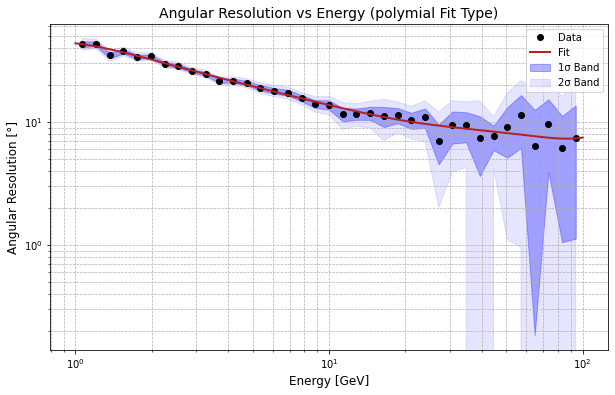

In [14]:
from h5py import File, Group
import os
from astropy.table import Table, Column
from astropy.time import Time
from astropy.io.misc.hdf5 import read_table_hdf5
import astropy.units as u
from astropy.coordinates import SkyCoord
import km3io.definitions as kd

from km3astro.io import load_hdf5_tables

import numpy as np

from km3astro.coord import local_event
from km3astro import sources

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Functions to fit to the angular resolution distribution
# Define the double Gaussian + constant function
def double_gaussian(E, A1, mu1, sigma1, A2, mu2, sigma2, C_1, C_2):
    logE = np.log10(E)
    gauss1 = A1 * np.exp(-0.5 * ((logE - mu1) / sigma1) ** 2)
    gauss2 = A2 * np.exp(-0.5 * ((logE - mu2) / sigma2) ** 2)
    return gauss1 + gauss2 + C_1 * logE + C_2

def logistic_function(E, a, b, c, d):
    return a / (1.0 + np.exp(-b * (np.log10(E) - c))) + d

def double_logistic(E, a1, b1, c1, a2, b2, c2, d):
    # First logistic (for decrease)
    logistic1 = a1 / (1 + np.exp(-b1 * (np.log10(E) - c1)))
    # Second logistic (for rise)
    logistic2 = a2 / (1 + np.exp(-b2 * (np.log10(E) - c2)))
    return logistic1 - logistic2 + d

def polynomial(E, a, b, c, d, e, f, g, h):
    return a * np.log10(E)**4 + b * np.log10(E)**3 + c * np.log10(E)**2 + d * np.log10(E) + e + f*np.log10(E)**5 +g * np.log10(E)**6 +h*np.log10(E)**7

def tanh_function(E, a, b, c, d):
    return a * np.tanh(b * (np.log10(E) - c)) + d

# Function to read HDF5 file and fit the data to a model
def fit_angular_resolution(file_path, output_dir = "./", fit_type="logistic"):
    # Open the HDF5 file
    table = Table.read(file_path, format='hdf5')

    # Access the columns by their names
    energy_bin_centers = table['energy_bin_center']
    angular_resolution = table['median_angular_separation']
    sigma1_width = table['sigma1_width']  # Assuming this is the uncertainty



    valid_indices = np.isfinite(angular_resolution) & np.isfinite(sigma1_width) & np.isfinite(energy_bin_centers)

    if not np.all(valid_indices):
        print("Warning: Some values were NaN or Inf and have been removed from the fit.")
        energy_bin_centers = energy_bin_centers[valid_indices]
        angular_resolution = angular_resolution[valid_indices]
        sigma1_width = sigma1_width[valid_indices]
    
    energy_bin_center_list = repr(energy_bin_centers.tolist())
    median_angular_separation_list = repr(angular_resolution.tolist())


    # Print or copy the results
    print(len(energy_bin_center_list))
    print(len(median_angular_separation_list))

    print(energy_bin_center_list)
    print(median_angular_separation_list)

    if fit_type == "logistic":
        # Initial guesses for the logistic function parameters
        popt, _ = curve_fit(logistic_function, energy_bin_centers, angular_resolution, 
                            p0=[3.5, 1, 4, 0.5], sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: logistic_function(E, *popt)
        plot_name = os.path.join(output_dir,f"fitted_angular_resolution_tracklike.png")
    elif fit_type == "polymial":
        # Initial guesses for the sinusoidal function parameters
        popt, _ = curve_fit(polynomial, energy_bin_centers, angular_resolution, sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: polynomial(E, *popt)
        plot_name = os.path.join(output_dir,f"fitted_angular_resolution_showerlike.png")
    elif fit_type == "tanh":
        # Initial guesses for the tanh function parameters
        popt, _ = curve_fit(tanh_function, energy_bin_centers, angular_resolution, 
                            p0 = [1.0, 2.0, 5.5, 0.2], sigma=sigma1_width, absolute_sigma=True, maxfev=10000)
        fit_func = lambda E: tanh_function(E, *popt)
        plot_name = os.path.join(output_dir, "fitted_angular_resolution_tanh.png")
    elif fit_type == "double_logistic":
        # Initial guesses (you'll need to tune these based on your data)
        popt, _ = curve_fit(double_logistic, energy_bin_centers, angular_resolution, 
                    p0=[2, 1, 0.2, 1, 1, 0.7, 0.1], sigma=sigma1_width, absolute_sigma=True, maxfev=10000)
        fit_func = lambda E: double_logistic(E, *popt)
        plot_name = os.path.join(output_dir, "fitted_angular_resolution_doublelogistic.png")
    elif fit_type == "double_gaussian":
        initial_guesses = [2, 2.5, 0.5, 1, 9, 5, -0.01,0.1]
        popt, _ = curve_fit(double_gaussian, energy_bin_centers, angular_resolution, 
                       p0=initial_guesses, sigma=sigma1_width, absolute_sigma=True, maxfev=10000)
        fit_func = lambda E: double_gaussian(E, *popt)
        plot_name = os.path.join(output_dir, "fitted_angular_resolution_gaussian.png")
    else:
        raise ValueError("Unknown fit type. Choose 'logistic' or 'sinusoidal'.")
    
    print("Parameters: ", popt)
    
    # Plot the data and the fit
    plt.figure(figsize=(10, 6))
    plt.plot(energy_bin_centers, angular_resolution, color='black', marker='o', linestyle='none', label='Data')
    energy_fit = np.logspace(0, 2, 1000)  # Energy values for plotting the fit
    plt.plot(energy_fit, fit_func(energy_fit), color='firebrick', linestyle='-', linewidth=2, label='Fit')
    plt.xscale('log')
    # Add a shaded 1σ band for uncertainties (optional, depends on your data)
    sigma1_band_lower = angular_resolution - sigma1_width  # Example: replace sigma1_values with your actual 1σ uncertainties
    sigma1_band_upper = angular_resolution + sigma1_width
    plt.fill_between(energy_bin_centers, sigma1_band_lower, sigma1_band_upper, color='blue', alpha=0.3, label='1σ Band')

    # Add a shaded 2σ band for uncertainties (optional)
    sigma2_band_lower = angular_resolution - 2*sigma1_width   # Example: replace sigma2_values with your actual 2σ uncertainties
    sigma2_band_upper = angular_resolution + 2*sigma1_width
    plt.fill_between(energy_bin_centers, sigma2_band_lower, sigma2_band_upper, color='blue', alpha=0.1, label='2σ Band')


    plt.xscale('log')
    plt.yscale('log')
    #plt.ylim([0,2.5])
    # Customize labels and title
    plt.xlabel('Energy [GeV]', fontsize=12)
    plt.ylabel('Angular Resolution [°]', fontsize=12)
    plt.title(f'Angular Resolution vs Energy ({fit_type} Fit Type)', fontsize=14)
    # Add gridlines for better readability
    plt.grid(True, which="both", linestyle="--", linewidth=0.7)
    plt.legend()
    plt.show()
    # plt.savefig(plot_name)

    return fit_func


# Example usage
#fit_func1 = fit_angular_resolution('/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5', fit_type="logistic")
#fit_func2 = fit_angular_resolution('/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013.hdf5', fit_type="polymial")
fit_func3 = fit_angular_resolution('/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_jshower_gsg_elec-CC_1.0-100.0GeV_orca.hdf5', fit_type ="polymial")



In [15]:
import os
import re

import time
from h5py import File, Group
#import h5py

import awkward as ak
import numpy as np
from km3io import tools

from km3io import offline

path = "/home/hpc/capn/mppi104h/wecapstor3/out/ORCA_115/numu/reco/gsg_muon-CC_1.0-100.0GeV.5.km3sim.jte.jmergefit.aanet.root"
path = "/home/hpc/capn/mppi104h/wecapstor3/out/ORCA_115/nue/reco/gsg_elec-CC_1.0-100.0GeV.5.km3sim.jte.jmergefit.aanet.root"
file = offline.OfflineReader(path)

In [17]:
nu_reco = file.tracks
best_fit = tools.best_aashower(nu_reco)
mask_reco = tools.has_aashower(nu_reco)  

print(best_fit[mask_reco].E)

[]


## Investigation Vela X-1 Time Data

In [1]:
path = '/home/hpc/capn/capn107h/software/velax1.fits.gz'

In [5]:
from astropy.io import fits

# Load the file
with fits.open(path) as hdul:
    # Print summary of HDU (Header/Data Unit) list
    hdul.info()

    # Access primary header information
    primary_header = hdul[0].header
    print("Primary Header:", primary_header)

    # Access data if it exists in the primary HDU
    if 'data' in hdul[0].header:
        primary_data = hdul[0].data
        print("Primary Data Shape:", primary_data.shape)

    # Check additional extensions (if they exist)
    for i in range(0, len(hdul)):
        header = hdul[i].header
        data = hdul[i].data
        print(f"Extension {i} - Header:", header)
        print(f"Extension {i} - Data Columns:", data.columns.names if data is not None else "No Data")


Filename: /home/hpc/capn/capn107h/software/velax1.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  Orbital Elements    1 BinTableHDU     58   1R x 14C   [24A, D, D, A, D, D, A, D, D, D, D, D, D, D]   
  2  PSR_HIST      1 BinTableHDU     78   1970R x 22C   [2D, D, D, D, D, J, 10B, I, D, D, D, D, D, D, D, D, D, D, D, 60D, 30D, I]   
Primary Header: SIMPLE  =                    T /Dummy Created by MWRFITS v1.7                   BITPIX  =                    8 /Dummy primary header created by MWRFITS         NAXIS   =                    0 /No data is associated with this header          EXTEND  =                    T /Extensions may (will!) be present               OBJECT  = 'Vela X-1'           /Name of monitored object                        RA      =            135.52860 /Right Ascension (deg)                           DEC     =           -40.554700 /Declination (deg)                               EQUINOX =    

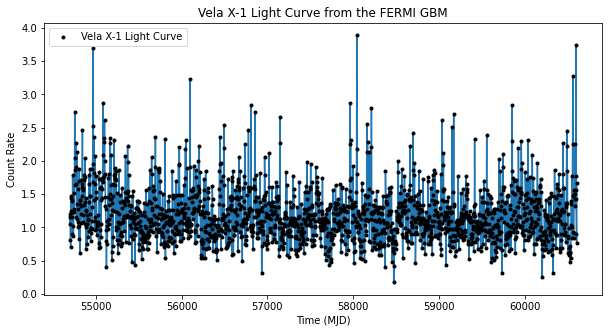

In [4]:
import matplotlib.pyplot as plt

# Load the file again to access specific columns
with fits.open('/home/hpc/capn/capn107h/software/velax1.fits.gz') as hdul:
    data = hdul[2].data  # Assuming light curve data is in the first extension

    # Check for light curve columns
    if 'BARYTIME' in data.columns.names and 'AMPLITUDE' in data.columns.names:
        time = data['BARYTIME']
        rate = data['AMPLITUDE']
        # error = data['ERROR'] if 'ERROR' in data.columns.names else None

        # Plotting the light curve
        plt.figure(figsize=(10, 5))
        plt.errorbar(time, rate, fmt='.k', ecolor='red', capsize=2, label='Vela X-1 Light Curve')
        plt.plot(time,rate)
        plt.xlabel('Time (MJD)')
        plt.ylabel('Count Rate')
        plt.title('Vela X-1 Light Curve from the FERMI GBM')
        plt.legend()
        #plt.xlim([56000,56500])
        plt.show()
    else:
        print("Time or Rate columns not found in this file.")


In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits

filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/L241111092405F357373F82_PH00.fits'

# Load the FITS file
with fits.open(filepath) as hdul:
    psr_data = hdul[2].data  # PSR_HIST extension

    # Extract time, frequency, and frequency derivative data
    tstart = psr_data['TIME']  # Start time in MJD
    frequency = psr_data['FREQUENCY']  # Frequency in Hz
    frequency_err = psr_data['FREQUENCY_ERR']  # Frequency error in Hz
    fdot = psr_data['FDOT']  # Frequency derivative (spin-down rate)
    fdot_err = psr_data['FDOT_ERR']  # Spin-down rate error

    # Plot Frequency over Time
    plt.figure(figsize=(10, 5))
    plt.errorbar(tstart, frequency, yerr=frequency_err, fmt='.k', ecolor='gray', capsize=2, label='Frequency (Hz)')
    plt.xlabel('Time (MJD)')
    plt.ylabel('Pulsar Frequency (Hz)')
    plt.title('Pulsar Frequency of Vela X-1 over Time')
    plt.legend()
    plt.show()

    # Plot Spin-down Rate over Time
    plt.figure(figsize=(10, 5))
    plt.errorbar(tstart, fdot, yerr=fdot_err, fmt='.b', ecolor='lightblue', capsize=2, label='Frequency Derivative (Hz/s)')
    plt.xlabel('Time (MJD)')
    plt.ylabel('Spin-down Rate (Hz/s)')
    plt.title('Spin-down Rate of Vela X-1 over Time')
    plt.xlim([55000,60000])
    #plt.ylim([0,1e-20])
    plt.yscale('log')
    plt.legend()
    plt.show()


KeyError: "Key 'TSTART' does not exist."

No handles with labels found to put in legend.


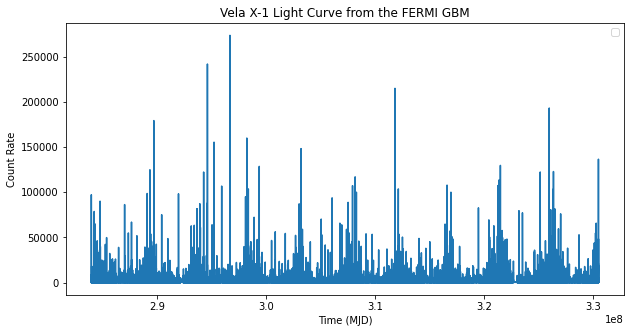

Min Time: 283996845.1930711
Max Time: 330478950.6700399


In [21]:
filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/L241111092405F357373F82_PH00.fits'
import numpy as np
# Load the file again to access specific columns
with fits.open(filepath) as hdul:
    data = hdul[1].data # Assuming light curve data is in the first extension

    time = data['TIME']
    energy = data['ENERGY']
    # error = data['ERROR'] if 'ERROR' in data.columns.names else None

    # Plotting the light curve
    plt.figure(figsize=(10, 5))
    #plt.errorbar(time, energy, fmt='.k', ecolor='red', capsize=2, label='Vela X-1 Light Curve')
    plt.plot(time,energy)
    plt.xlabel('Time (MJD)')
    plt.ylabel('Count Rate')
    plt.title('Vela X-1 Light Curve from the FERMI GBM')
    plt.legend()
    #plt.xlim([56000,56500])
    plt.show()

    print(f"Min Time: {np.min(time)}")
    print(f"Max Time: {np.max(time)}")



In [16]:
print(psr_data['TIME'])
print(psr_data.__dict__)

[2.83996845e+08 2.83997031e+08 2.83997054e+08 ... 3.30478404e+08
 3.30478440e+08 3.30478516e+08]
{'_nfields': 23, '_converted': {}, '_heapoffset': 52411282, '_heapsize': 0, '_gap': 0, '_uint': True, '_col_weakrefs': <_weakrefset.WeakSet object at 0x7f406e9fbe10>, '_coldefs': ColDefs(
    name = 'ENERGY'; format = 'E'; unit = 'MeV'
    name = 'RA'; format = 'E'; unit = 'deg'
    name = 'DEC'; format = 'E'; unit = 'deg'
    name = 'L'; format = 'E'; unit = 'deg'
    name = 'B'; format = 'E'; unit = 'deg'
    name = 'THETA'; format = 'E'; unit = 'deg'
    name = 'PHI'; format = 'E'; unit = 'deg'
    name = 'ZENITH_ANGLE'; format = 'E'; unit = 'deg'
    name = 'EARTH_AZIMUTH_ANGLE'; format = 'E'; unit = 'deg'
    name = 'TIME'; format = 'D'; unit = 's'
    name = 'EVENT_ID'; format = 'J'
    name = 'RUN_ID'; format = 'J'
    name = 'RECON_VERSION'; format = 'I'
    name = 'CALIB_VERSION'; format = '3I'
    name = 'EVENT_CLASS'; format = '32X'
    name = 'EVENT_TYPE'; format = '32X'
    nam

In [38]:
from astroquery.fermi import FermiLAT
from astropy.coordinates import SkyCoord
import astropy.units as u

from astroquery.heasarc import Heasarc
from astroquery.simbad import Simbad
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive

# Define the target
target_name = "Cyg X-1"

# Initialize Simbad to resolve coordinates
simbad = Simbad()
simbad_data = simbad.query_object(target_name)
print("Coordinates from Simbad:", simbad_data)

simbad_data

# Fetch position for querying HEASARC
ra, dec = simbad_data['RA'][0], simbad_data['DEC'][0]
position = f"{ra} {dec}"

coordinates = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))

# Define the time range for FermiLAT query
start_time = "2010-01-01T00:00:00"
end_time = "2020-01-01T00:00:00"

# Query Fermi LAT data within the specified time range
fermi_data = FermiLAT.query_object(coordinates)
print("Fermi LAT Data:", fermi_data)

#fermi_data = FermiLAT.query_object(coordinates)
print("Fermi LAT Data:", fermi_data)
fermi_data
#simbad_data

Coordinates from Simbad:  MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
HD 226868 19 58 21.6757 +35 12 05.784 ... 2020yCat.1350....0G                1
Fermi LAT Data: ['https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH00.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH01.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_SC00.fits']
Fermi LAT Data: ['https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH00.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH01.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_SC00.fits']


['https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH00.fits',
 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH01.fits',
 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_SC00.fits']

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from datetime import datetime
import matplotlib.dates as mdates
from astropy.io import fits


from datetime import datetime, timedelta

def datetime_to_mjd(dt):
    # Define the Julian Date epoch: January 1, 2000, 12:00 UTC as JD = 2451545.0
    julian_epoch = datetime(2000, 1, 1, 12, 0, 0)  # JD at 2000-01-01 12:00 UTC
    jd_epoch = 2451545.0  # JD at the Julian epoch

    # Calculate the difference in days between the input datetime and the Julian epoch
    delta_days = (dt - julian_epoch).total_seconds() / 86400.0
    jd = jd_epoch + delta_days  # Calculate Julian Date

    # Calculate the MJD by subtracting the offset
    mjd = jd - 2400000.5
    return mjd

# Julian Date



timedata= []
ratedata = []
start_obs = []
start_obs_mission = []



for i in range(2):
    with fits.open(fermi_data[i]) as hdul:
        # Assume the light curve data is in the first extension
        light_curve_data = hdul[1]
        
        # Inspect available columns to confirm the names
        header = hdul[1].header

        start_obs = hdul[1].header['DATE-OBS']   # Start of Observation in UTC format (2024-05-02T10:48:11.9999)
        start_obs_mission = hdul[1].header['TSTART']    # Start of Observation in seconds since mission start
        time = hdul[1].data['TIME']  # Time in seconds since mission start
        rate = hdul[1].data['ENERGY']  

        time_obs = time - start_obs_mission # Time in seconds since start of Observation
        mjd_start_obs = datetime_to_mjd(start_obs)
        time_mjd = mjd_start_obs + time_obs
        #start_time_utc = Time(start_obs1, format='isot', scale='utc')
        #utc_times = start_time_utc + time_obs1 *u.s
        #print(utc_times)
        #print(rate)

                # Extract time and rate (or flux) columns
        if i == 1:
            timedata = time_mjd   # Time in seconds or days
            ratedata = rate  # Energy or flux 
        else:
            timedata_add = time_mjd
            ratedata_add = rate
    
    timedata = np.concatenate([timedata, timedata_add])
    ratedata = np.concatenate([ratedata, ratedata_add])


#utc_times_dt = utc_times.datetime.astype(datetime)

# Plotting
plt.figure(figsize=(12, 6))
plt.scatter(timedata, ratedata, marker='o',  color='firebrick')

# Formatting the x-axis to show ISO time format
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%dT%H:%M:%S'))
#plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Change interval as needed

#plt.gcf().autofmt_xdate()  # Auto-format x-axis labels for better readability
plt.xlabel('UTC Time (ISO Format)')
plt.ylabel('Rate (Energy)')
plt.title('Rate over UTC Time')
plt.grid()
plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'datetime.datetime'

In [14]:
with fits.open(fermi_data[i]) as hdul:
    light_curve_data = hdul[1]
    
    # Extract start observation and mission start time in UTC
    start_obs = hdul[1].header['DATE-OBS']   # Start of Observation in UTC format (str)
    start_obs_mission = hdul[1].header['TSTART']  # Start in seconds since mission start (float)
    time = hdul[1].data['TIME']  # Time in seconds since mission start (array)
    rate = hdul[1].data['ENERGY']  

    # Convert start_obs (str) to a datetime object
    start_obs_datetime = datetime.strptime(start_obs, "%Y-%m-%dT%H:%M:%S.%f")
    mjd_start_obs = datetime_to_mjd(start_obs_datetime)  # MJD of start_obs

    # Calculate time in MJD
    time_mjd = mjd_start_obs + (time / 86400.0)  # Add time in days

    print(type(start_obs))
    print(type(start_obs_mission))
    print(len(time))
    print((time-start_obs_mission)/(3600*24))
    print(start_obs_datetime)
    print(mjd_start_obs)
    print(time_mjd)
    

<class 'str'>
<class 'float'>
887318
[  0.18384695   0.43375832   0.49985587 ... 118.56563101 118.56564098
 118.56565943]
2024-05-02 10:48:11.999900
60432.450138887856
[68955.08417102 68955.33408239 68955.40017994 ... 69073.46595508
 69073.46596505 69073.4659835 ]


In [39]:
import numpy as np
from astropy.time import Time, TimeDelta

def convert_times(seconds_since_mission_start, obs_start_seconds, obs_start_iso):
    """
    Convert an array of times in seconds since mission start into MJD and Unix ISO formats.
    
    Parameters:
    - seconds_since_mission_start: np.ndarray
        Array of times in seconds since mission start.
    - obs_start_seconds: float
        The seconds since mission start at the start of the observation.
    - obs_start_iso: str
        The Unix ISO format of the observation start time.
    
    Returns:
    - mjd_times: np.ndarray
        Array of times in MJD format.
    - unix_iso_times: np.ndarray
        Array of times as astropy Time objects in Unix ISO format.
    """
    # Parse observation start time and define mission start time using TimeDelta
    observation_start = Time(obs_start_iso, format='isot', scale='utc')
    mission_start = observation_start - TimeDelta(obs_start_seconds, format='sec')

    # Convert seconds since mission start to `astropy.Time` objects
    times = mission_start + TimeDelta(seconds_since_mission_start, format='sec')

    # Convert to MJD format and Unix ISO format
    mjd_times = times.mjd
    unix_iso_times = times.isot

    return mjd_times, unix_iso_times

for i in range(2):
    with fits.open(fermi_data[i]) as hdul:
        light_curve_data = hdul[1]
        
        # Extract start observation and mission start time in UTC
        start_obs = hdul[1].header['DATE-OBS']   # Start of Observation in UTC format (str)
        start_obs_mission = hdul[1].header['TSTART']  # Start in seconds since mission start (float)
        time = hdul[1].data['TIME']  # Time in seconds since mission start (array)
        rate = hdul[1].data['ENERGY']  
        mjd_times, unix_iso_times = convert_times(time,start_obs_mission,start_obs)

            # Append data to lists
        if i == 0:
            timedata = time
            ratedata = rate
        else:
            timedata = np.concatenate([timedata, time])
            ratedata = np.concatenate([ratedata, rate])

print(timedata)
print(ratedata)
mjd_times, unix_iso_times = convert_times(timedata,start_obs_mission,start_obs)

[7.36865326e+08 7.36870634e+08 7.36875918e+08 ... 7.52412711e+08
 7.52412720e+08 7.52412759e+08]
[201.72672 963.93225 267.86935 ... 205.08319 136.19218 143.99422]


In [27]:
print(len(timedata))
print(len(ratedata))

1554121
1554121


In [21]:
print("MJD Times:", mjd_times)
print("Unix ISO Times:", unix_iso_times)

MJD Times: [51910.79809125 51910.79809414 51910.79809491 ... 51910.79946141
 51910.79946141 51910.79946141]
Unix ISO Times: ['2001-01-01T19:09:15.084' '2001-01-01T19:09:15.334'
 '2001-01-01T19:09:15.400' ... '2001-01-01T19:11:13.466'
 '2001-01-01T19:11:13.466' '2001-01-01T19:11:13.466']


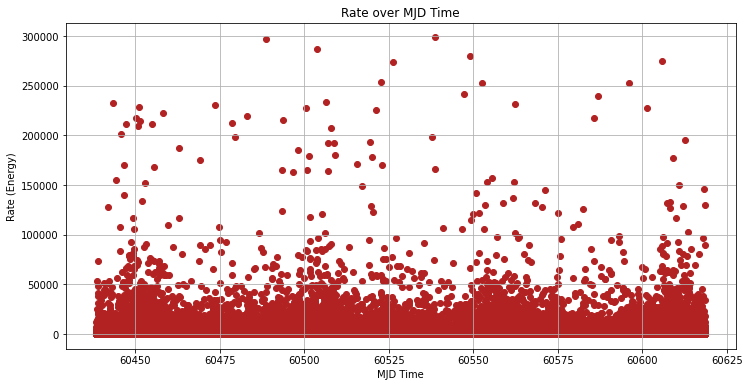

In [40]:
plt.figure(figsize=(12, 6))
plt.scatter(mjd_times, ratedata, marker='o',  color='firebrick')
plt.xlabel('MJD Time')
plt.ylabel('Rate (Energy)')
plt.title('Rate over MJD Time')
plt.grid()
plt.show()

In [ ]:
def convert_times(seconds_since_mission_start_array, observation_start_seconds, observation_start_iso):
    # Convert the observation start time from ISO format to an astropy Time object
    observation_start_time = Time(observation_start_iso, format='isot', scale='utc')
    
    # Calculate the mission start time in astropy Time format
    mission_start_time = observation_start_time - observation_start_seconds
    
    # Convert seconds since mission start to MJD and Unix ISO formats
    mjd_times = []
    iso_times = []

    for seconds_since_mission_start in seconds_since_mission_start_array:
        # Calculate the current time as mission start + seconds since mission start
        current_time = mission_start_time + seconds_since_mission_start * u.s
        # Append the time in MJD format and in ISO format
        mjd_times.append(current_time.mjd)
        iso_times.append(current_time.isot)
    
    # Convert lists to numpy arrays for easy handling
    mjd_times = np.array(mjd_times)
    iso_times = np.array(iso_times)

    return mjd_times, iso_times



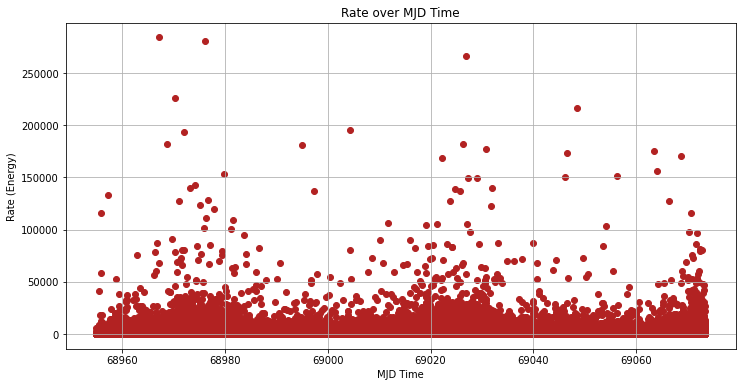

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from astropy.io import fits

def datetime_to_mjd(dt):
    """Converts datetime to Modified Julian Date (MJD)."""
    julian_epoch = datetime(2000, 1, 1, 12, 0, 0)
    jd_epoch = 2451545.0  # JD at the epoch
    
    # Only proceed if dt is a datetime object
    if isinstance(dt, datetime):
        delta_days = (dt - julian_epoch).total_seconds() / 86400.0
        jd = jd_epoch + delta_days  # Julian Date
        mjd = jd - 2400000.5        # Modified Julian Date
        return mjd
    else:
        raise TypeError("Input must be a datetime object")

# Arrays for data
timedata = []
ratedata = []

# Loop through each FITS file
for i in range(1):
    with fits.open(fermi_data[i]) as hdul:
        light_curve_data = hdul[1]
        
        # Extract start observation and mission start time in UTC
        start_obs = hdul[1].header['DATE-OBS']   # Start of Observation in UTC format (str)
        start_obs_mission = hdul[1].header['TSTART']  # Start in seconds since mission start (float)
        time = hdul[1].data['TIME']  # Time in seconds since mission start (array)
        rate = hdul[1].data['ENERGY']  

        # Convert start_obs (str) to a datetime object
        start_obs_datetime = datetime.strptime(start_obs, "%Y-%m-%dT%H:%M:%S.%f")
        mjd_start_obs = datetime_to_mjd(start_obs_datetime)  # MJD of start_obs

        # Calculate time in MJD
        time_mjd = mjd_start_obs + (time / 86400.0)  # Add time in days

        # Append data to lists
        if i == 0:
            timedata = time_mjd
            ratedata = rate
        else:
            timedata = np.concatenate([timedata, time_mjd])
            ratedata = np.concatenate([ratedata, rate])

# Plotting
plt.figure(figsize=(12, 6))
plt.scatter(timedata, ratedata, marker='o',  color='firebrick')
plt.xlabel('MJD Time')
plt.ylabel('Rate (Energy)')
plt.title('Rate over MJD Time')
plt.grid()
plt.show()


In [47]:
len(fermi_data)
range(3)

range(0, 3)

In [8]:
print(np.array(timedata))

[7.46594069e+08 7.46595313e+08 7.46597623e+08 ... 7.46583767e+08
 7.46583767e+08 7.46583769e+08]


Bin width: 86.4002316724509 s


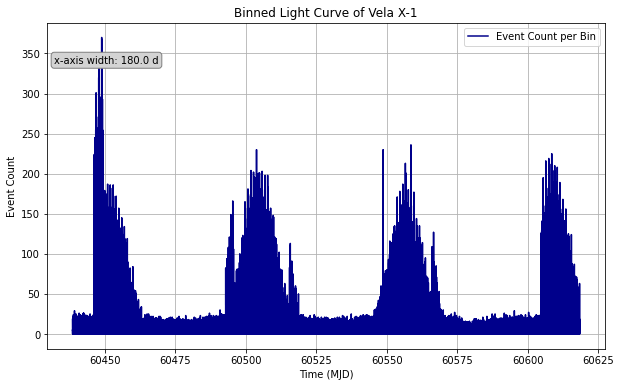

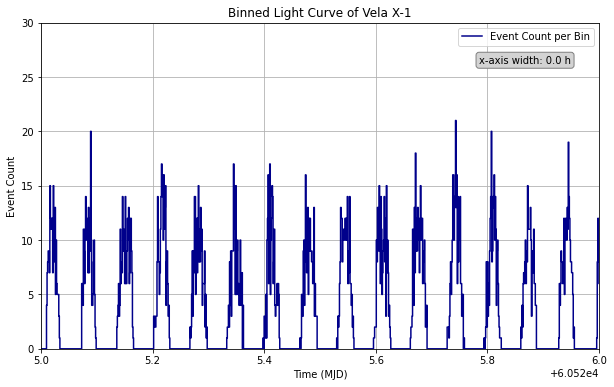

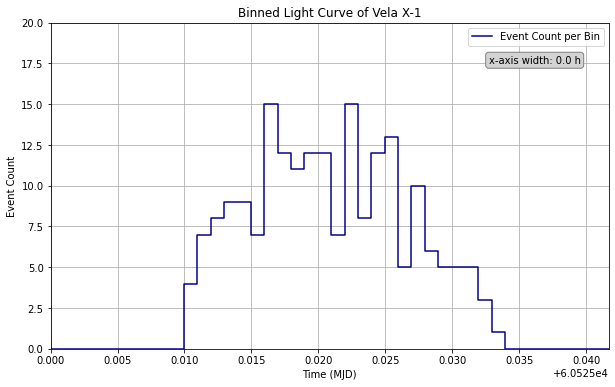

[60438.57321803 60438.57421804 60438.57521804 ... 60618.5476995
 60618.5486995  60618.5496995 ]


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

timedata = mjd_times

# Define your bin size and calculate number of bins based on the time range
bin_size = 0.001  # Bin size in seconds, adjust as needed
min_time, max_time = np.min(timedata), np.max(timedata)
num_bins = int((max_time - min_time) / bin_size)

# Use np.histogram to count events per bin
event_counts, bin_edges = np.histogram(timedata, bins=num_bins, range=(min_time, max_time))

# Calculate the bin centers for plotting
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
print(f"Bin width: {(bin_centers[1]-bin_centers[0])*(3600*24)} s")
x_width = np.max(bin_centers) - np.min(bin_centers)
#bin_centers = Time(bin_centers, format='mjd', scale='utc').iso

# Plotting the binned light curve
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue', label='Event Count per Bin')
plt.xlabel("Time (MJD)")
plt.ylabel("Event Count")
plt.title("Binned Light Curve of Vela X-1")
plt.legend()
plt.grid()
plt.text(
    0.2, 0.9,                   # Position in axes coordinates
    f"x-axis width: {x_width:.1f} d", # Text with the width of the x-axis
    ha='right', va='top',         # Aligning the text to the top-right corner
    transform=plt.gca().transAxes, # Relative positioning in the axes
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="lightgray") # Rounded box style
)

# Calculating the width of the x-axis range
x_min, x_max = 60525, 60526
x_width = x_max - x_min

# Plotting the binned light curve
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue', label='Event Count per Bin')
plt.xlabel("Time (MJD)")
plt.ylabel("Event Count")
plt.title("Binned Light Curve of Vela X-1")
plt.legend()
plt.grid()

plt.text(
    0.95, 0.9,                   # Position in axes coordinates
    f"x-axis width: {x_width/24:.1f} h", # Text with the width of the x-axis
    ha='right', va='top',         # Aligning the text to the top-right corner
    transform=plt.gca().transAxes, # Relative positioning in the axes
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="lightgray") # Rounded box style
)

plt.xlim([x_min,x_max])
plt.ylim([0,30])


# Calculating the width of the x-axis range
x_min, x_max = 60525, 60525 + 1/24
x_width = float(x_max) - float(x_min)

# Plotting the binned light curve
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue', label='Event Count per Bin')
plt.xlabel("Time (MJD)")
plt.ylabel("Event Count")
plt.title("Binned Light Curve of Vela X-1")
plt.legend()
plt.grid()

plt.text(
    0.95, 0.9,                   # Position in axes coordinates
    f"x-axis width: {x_width/24:.1f} h", # Text with the width of the x-axis
    ha='right', va='top',         # Aligning the text to the top-right corner
    transform=plt.gca().transAxes, # Relative positioning in the axes
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="lightgray") # Rounded box style
)

plt.xlim([x_min,x_max])
plt.ylim([0,20])

plt.show()

print(bin_centers)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.time import Time
import astropy.units as u

# Load the FITS file
time = np.array([])  # Initialize arrays for time and rate
rate = np.array([])

for i in range(2):
    with fits.open(fermi_data[i]) as hdul:
        # Assume the light curve data is in the first extension
        light_curve_data = hdul[1].data

        # Extract time and rate (or flux) columns
        if i == 1:
            time = light_curve_data['TIME']    # Time in seconds since mission start
            rate = light_curve_data['ENERGY']  # Energy or flux 
        else:
            time_add = light_curve_data['TIME']
            rate_add = light_curve_data['ENERGY']
    
    # Concatenate the time and rate arrays
    time = np.concatenate([time, time_add])
    rate = np.concatenate([rate, rate_add])

# Define your bin size and calculate number of bins based on the time range
bin_size = 50  # Bin size in seconds, adjust as needed
min_time, max_time = np.min(time), np.max(time)
num_bins = int((max_time - min_time) / bin_size)

# Use np.histogram to count events per bin
event_counts, bin_edges = np.histogram(time, bins=num_bins, range=(min_time, max_time))

# Calculate the bin centers for plotting
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

# Convert bin centers to ISO format
start_time_utc = Time(hdul[1].header['DATE-OBS'], format='isot', scale='utc')
utc_bin_centers = start_time_utc + bin_centers * u.s  # Add bin centers as seconds to start time
iso_bin_centers = utc_bin_centers.iso  # Convert to ISO format

# Print information
print(f"Bin width: {bin_centers[1] - bin_centers[0]} s")
x_width = np.max(bin_centers) - np.min(bin_centers)

# Plotting the binned light curve
plt.figure(figsize=(10, 6))
plt.plot(iso_bin_centers, event_counts, drawstyle='steps-mid', color='darkblue', label='Event Count per Bin')
plt.xlabel("ISO Time (YYYY-MM-DDTHH:MM:SS)")
plt.ylabel("Event Count")
plt.title("Binned Light Curve of Vela X-1")
plt.legend()
plt.grid()
plt.text(
    0.2, 0.9,                   # Position in axes coordinates
    f"x-axis width: {x_width/(3600*24):.1f} d",  # Text with the width of the x-axis in days
    ha='right', va='top',         # Aligning the text to the top-right corner
    transform=plt.gca().transAxes, # Relative positioning in the axes
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="lightgray")  # Rounded box style
)

# Show the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


Bin width: 50.00004959106445 s


KeyboardInterrupt: 

In [49]:
from astroquery.heasarc import Heasarc
import astropy.units as u
from astropy.coordinates import SkyCoord

# Initialize HEASARC service
heasarc = Heasarc()

# Define coordinates for Vela X-1
vela_x1_coords = SkyCoord.from_name("Vela X-1")

# Query light curve data for the last 10 years
result = heasarc.query_region(
    vela_x1_coords,
    mission='swiftmastr',  # Swift mission data, adjust mission for other sources
    radius=0.1 * u.deg,  # Small radius for precise target data
    time="2013-10-01 to 2023-10-01"  # Last 10 years
)

# Show available observations
print(result)

IORegistryError: Format could not be identified based on the file name or contents, please provide a 'format' argument.
The available formats are:
           Format           Read Write Auto-identify Deprecated
--------------------------- ---- ----- ------------- ----------
                      ascii  Yes   Yes            No           
               ascii.aastex  Yes   Yes            No           
                ascii.basic  Yes   Yes            No           
                  ascii.cds  Yes    No            No           
     ascii.commented_header  Yes   Yes            No           
                  ascii.csv  Yes   Yes           Yes           
              ascii.daophot  Yes    No            No           
                 ascii.ecsv  Yes   Yes           Yes           
           ascii.fast_basic  Yes   Yes            No           
ascii.fast_commented_header  Yes   Yes            No           
             ascii.fast_csv  Yes   Yes            No           
       ascii.fast_no_

/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astroquery/fermi/__init__.py:37: UserWarning: Experimental: Fermi-LAT has not yet been refactored to have its API match the rest of astroquery.
  warnings.warn("Experimental: Fermi-LAT has not yet been refactored to have "


Coordinates from Simbad:  MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
HD 226868 19 58 21.6757 +35 12 05.784 ... 2020yCat.1350....0G                1
Fermi Data:  ['https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH00.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_PH01.fits', 'https://fermi.gsfc.nasa.gov/FTP/fermi/data/lat/queries/L241104102455F357373F77_SC00.fits']
2024-05-08T11:33:19.9999
736860804.0


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:72: UserWarning: Invalid or missing start time provided. Using minimum available MJD time.
/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:76: UserWarning: Invalid or missing end time provided. Using maximum available MJD time.


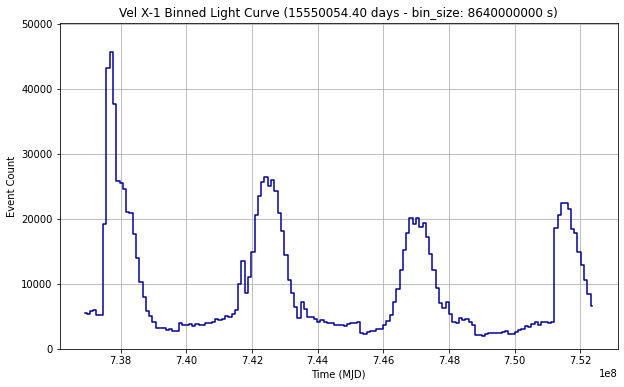

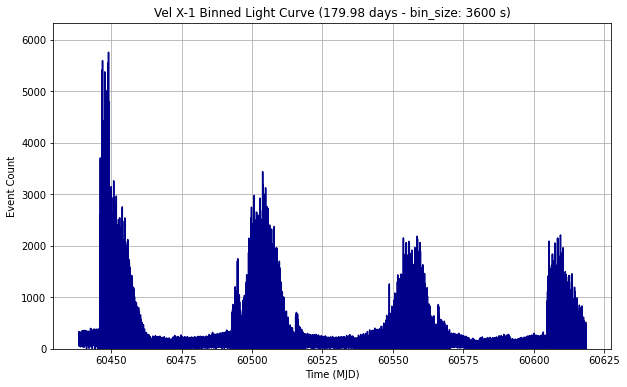

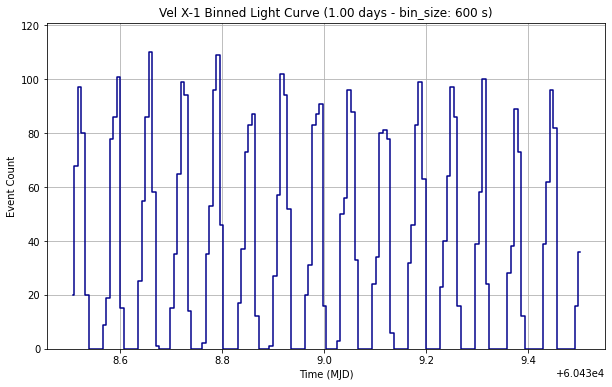

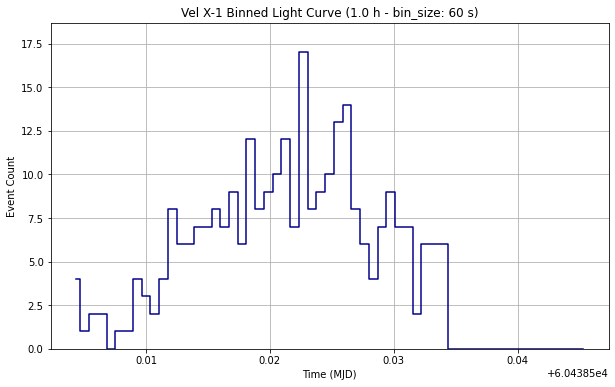

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.io import fits
from astroquery.fermi import FermiLAT
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u
import warnings




def load_fermi_data(target_name):
    """
    Load Fermi LAT data for a target within a given time range, and concatenate time and rate data arrays.
    """
    simbad = Simbad()
    simbad_data = simbad.query_object(target_name)

    print("Coordinates from Simbad:", simbad_data)

    ra, dec = simbad_data['RA'][0], simbad_data['DEC'][0]
    coordinates = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
    fermi_data = FermiLAT.query_object(coordinates)
    print("Fermi Data: ", fermi_data)
    timedata, ratedata = [], []

    for i in range(len(fermi_data) - 1):
        with fits.open(fermi_data[i], memmap=True) as hdul:
            light_curve_data = hdul[1]
            time = light_curve_data.data['TIME']
            rate = light_curve_data.data['ENERGY']
            if i == 0:
                start_obs = light_curve_data.header['DATE-OBS']
                start_obs_mission = light_curve_data.header['TSTART']
                timedata = time
                ratedata = rate
            else:
                timedata = np.concatenate([timedata, time])
                ratedata = np.concatenate([ratedata, rate])


    return timedata, ratedata, start_obs, start_obs_mission

def convert_times(seconds_since_mission_start, obs_start_seconds, obs_start_iso):
    """
    Convert an array of times in seconds since mission start into MJD and Unix ISO formats.
    """
    observation_start = Time(obs_start_iso, format='isot', scale='utc')
    mission_start = observation_start - TimeDelta(obs_start_seconds, format='sec')
    times = mission_start + TimeDelta(seconds_since_mission_start, format='sec')
    mjd_times = times.mjd
    unix_iso_times = times.isot
    return mjd_times, unix_iso_times

def plot_binned_light_curve(mjd_times, ratedata, title_prefix, start_time=None, end_time=None, bin_size_seconds=60):
    """
    Plot a binned light curve over a specified time range.

    Parameters:
    - mjd_times (np.ndarray): Array of times in MJD.
    - ratedata (np.ndarray): Array of rate data.
    - title_prefix (str): Title prefix for the plot.
    - start_time (float, optional): Start of the time range for plotting in MJD. Defaults to minimum MJD time.
    - end_time (float, optional): End of the time range for plotting in MJD. Defaults to maximum MJD time.
    - bin_size_seconds (float, optional): Desired bin size in seconds. Default is 3600 seconds (1 hour).
    """
    # Validate and set default time range if needed
    if start_time is None or start_time < np.min(mjd_times) or start_time > np.max(mjd_times):
        start_time = np.min(mjd_times)
        warnings.warn("Invalid or missing start time provided. Using minimum available MJD time.")
    
    if end_time is None or end_time > np.max(mjd_times) or end_time < np.min(mjd_times):
        end_time = np.max(mjd_times)
        warnings.warn("Invalid or missing end time provided. Using maximum available MJD time.")

    # Set bin size based on the specified range
    #bin_size = (end_time - start_time) / 1000
    #num_bins = int((end_time - start_time) / bin_size)

    bin_size_days = bin_size_seconds / (24 * 3600)  # Convert seconds to days
    num_bins = int((end_time - start_time) / bin_size_days)

    # Bin the data within the specified range
    event_counts, bin_edges = np.histogram(mjd_times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

    # Calculate the y-axis scale based on the actual data in the selected range
    y_max = np.max(event_counts) * 1.1

    # Time range in the title
    range_days = end_time - start_time
    range_title = f"{range_days:.2f} days" if range_days >= 1 else f"{range_days * 24:.1f} h"

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue')
    plt.xlabel("Time (MJD)")
    plt.ylabel("Event Count")
    plt.title(f"{title_prefix} Binned Light Curve ({range_title} - bin_size: {bin_size_seconds} s)")
    plt.ylim(0, y_max)
    plt.grid()
    plt.show()

# Example usage of the functions
target_name = "Cyg X-1"
start_time = "2010-01-01T00:00:00"
end_time = "2020-01-01T00:00:00"

# Load Fermi data
timedata_sec, ratedata, start_obs, start_obs_mission = load_fermi_data(target_name)

print(start_obs)
print(start_obs_mission)

# Convert times to MJD and Unix ISO
mjd_times, unix_iso_times = convert_times(timedata_sec, start_obs_mission, start_obs)
target_name = "Vel X-1"
bin = 3600*24*100000
plot_binned_light_curve(timedata_sec, ratedata, target_name, bin_size_seconds=bin)
# Plot full time range, 1 day, and 1 hour light curves
plot_binned_light_curve(mjd_times, ratedata, target_name, start_time=np.min(mjd_times), end_time=np.max(mjd_times), bin_size_seconds=3600)
plot_binned_light_curve(mjd_times, ratedata, target_name, start_time=np.min(mjd_times), end_time=np.min(mjd_times) + 1, bin_size_seconds=600)
plot_binned_light_curve(mjd_times, ratedata, target_name, start_time=np.min(mjd_times), end_time=np.min(mjd_times) + 1/24, bin_size_seconds=60)


# Calculating search cone size from angular resolution

In [1]:
# load angular res file and fit function to it
# use function from PhD thesis to calculate the cone size for a given angular resolution

In [12]:
from numpy.random import rand
import astropy.units as u
angular_resolution = rand(1000)*5*u.deg + 0.1*u.deg
#angular_resolution = angular_resolution * u.deg
print(angular_resolution)

[4.830219   3.45430778 2.02103982 2.50656194 1.92114528 0.59186761
 4.31355267 4.80101888 2.37885493 3.02278562 0.5690371  0.79265382
 4.79275108 1.52823841 3.03721568 4.08033404 0.41689777 0.37688721
 4.67907644 4.78083296 4.23566456 4.37374225 0.87416142 0.82595204
 1.84601288 4.85960868 4.16435731 3.69125454 1.65905064 4.70997637
 2.65381361 3.61406927 4.71493369 4.50209539 1.38237285 0.62813834
 4.00173526 3.13354167 1.48639091 5.03335787 0.73132559 4.34433338
 4.98316136 3.80237602 0.65897375 3.37165855 3.40522566 1.48720364
 1.28937785 1.00049253 4.81923613 0.9060107  0.77041257 3.37132118
 3.53939207 4.48475875 1.55932115 1.45984616 4.19147933 4.78554962
 1.85426517 1.13347701 2.79260528 3.77297401 3.66665079 3.20726578
 1.04985173 2.09463301 2.39838192 3.11452077 3.1639824  0.23792133
 0.62202537 2.85001436 0.30745567 2.6944659  4.56426137 3.29976808
 3.95397196 3.10204444 0.25065713 0.81035566 0.41073276 3.79362602
 1.42409098 3.21795282 2.24518232 2.68671922 3.86856767 0.9839

In [ ]:
import numpy as np
import astropy.units as u
# Define the function
def calc_search_cone(ang_res_km3net, min_err):
    # Ensure all inputs have compatible units
    ang_res_km3net = ang_res_km3net.to(u.deg)
    min_err = min_err.to(u.deg)
    ang_res_source = ang_res_source.to(u.deg)
    
    # Extract the numerical values for computation
    ang_res_km3net_val = ang_res_km3net.value
    min_err_val = min_err.value
    ang_res_source_val = ang_res_source.value
    
    # Perform the calculation
    search_cone_val = 1.58 * np.sqrt(
        np.minimum(ang_res_km3net_val**2, min_err_val**2) + ang_res_source_val**2
    )
    
    # Reapply the units (deg) to the result
    return search_cone_val * u.deg

min_err = 3/1.58 * u.deg
ang_res_source = np.sqrt((0.77*u.marcsec)**2+(0.64*u.marcsec)**2)
print(min_err)
print(ang_res_source)

search_cone = calc_search_cone(angular_resolution,min_err,ang_res_source)
print(search_cone)

1.8987341772151898 deg
1.0012492197250393 marcsec
[3.         3.         3.         3.         3.         0.93515082
 3.         3.         3.         3.         0.89907862 1.25239304
 3.         2.41461669 3.         3.         0.65869847 0.59548179
 3.         3.         3.         3.         1.38117504 1.30500422
 2.91670035 3.         3.         3.         2.62130002 3.
 3.         3.         3.         3.         2.1841491  0.99245858
 3.         3.         2.34849764 3.         1.15549443 3.
 3.         3.         1.04117852 3.         3.         2.34978175
 2.037217   1.5807782  3.         1.43149691 1.21725186 3.
 3.         3.         2.46372741 2.30655694 3.         3.
 2.92973897 1.79089367 3.         3.         3.         3.
 1.65876573 3.         3.         3.         3.         0.3759157
 0.98280009 3.         0.48577995 3.         3.         3.
 3.         3.         0.39603826 1.28036194 0.64895777 3.
 2.25006375 3.         3.         3.         3.         1.55470394
 2

In [1]:
import h5py
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5

path = '/home/hpc/capn/capn107h/software/nextflow_output/signal/mcv8.1.gsg_combined_eventlist_corrected_0.0035Hz_1.0-signal_mvm.hdf5'
path = '/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/mcv8.1.gsg_combined_eventlist.hdf5'
path = '/home/hpc/capn/capn107h/software/newhitfeatures_output/output_test.h5'
path = '/home/hpc/capn/capn107h/software/newhitfeatures_output/output_classified_test.h5'
path = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.root_scored.h5'
#ile = read_table_hdf5(path)

import pandas as pd
df = pd.read_hdf(path,'summary')



In [2]:
df

,AASHOWERFIT_ENERGY,AASHOWERFIT_NUMBER_OF_HITS,JCOPY_Z_M,JENERGY_CHI2,JENERGY_ENERGY,JENERGY_MAXIMAL_ENERGY,JENERGY_MINIMAL_ENERGY,JENERGY_MUON_RANGE_METRES,JENERGY_NDF,JENERGY_NOISE_LIKELIHOOD,...,pos_z,run_id,t_gen,trigger_counter,w1,w2,w3,weight_one_year,group_id,track_score
0,390.828217,81.0,-1234.0,-1234.000000,-1.234000e+03,-1234.0,-1234.0,-1234.000000,-1234.0,-1234.000000,...,208.228577,13298.0,1.0,3967.0,1686934.375,1.150443e+05,3.396173e-07,1.451215e+07,0.0,0.369381
1,3416.718262,319.0,0.0,268.983124,2.594553e+04,-1234.0,-1234.0,10003.439453,4299.0,-469.625824,...,531.868469,13298.0,1.0,40331.0,1522146.125,1.373979e+07,8.048283e-07,1.733192e+09,1.0,0.063411
2,4145.250000,112.0,0.0,125.591194,4.371445e+04,-1234.0,-1234.0,11443.144531,1795.0,-211.195007,...,107.892265,13298.0,1.0,51635.0,1761246.625,2.052940e+10,6.148128e-07,2.589660e+12,2.0,0.165901
3,5986.649902,119.0,0.0,94.400505,7.104974e+03,-1234.0,-1234.0,6546.034668,1791.0,-119.761429,...,282.452087,13298.0,1.0,48367.0,1759190.500,4.954730e+06,7.680644e-07,6.250094e+08,3.0,0.265371
4,1325.558472,106.0,0.0,90.846443,3.398208e+03,-1234.0,-1234.0,4748.229980,4864.0,-151.967621,...,718.631287,13298.0,1.0,9001.0,1716228.000,1.219032e+07,8.434183e-07,1.537736e+09,4.0,0.842471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13179,995346.125000,620.0,0.0,160.159714,2.548297e+06,-1234.0,-1234.0,22251.759766,800.0,-563.073669,...,334.384460,13298.0,1.0,39607.0,1518425.125,1.213076e+11,5.909826e-07,1.530223e+13,13179.0,0.004167
13180,20837.982422,183.0,0.0,186.847809,2.788127e+04,-1234.0,-1234.0,10201.541016,3181.0,-273.149078,...,529.439087,13298.0,1.0,27623.0,1440910.250,1.655562e+08,7.924062e-07,2.088393e+10,13180.0,0.002038
13181,19778.246094,123.0,0.0,86.748512,1.144442e+04,-1234.0,-1234.0,7787.784668,3159.0,-138.584335,...,738.655273,13298.0,1.0,40173.0,1601574.375,8.561775e+10,5.126041e-07,1.080017e+13,13181.0,0.182789
13182,1371.688232,155.0,0.0,191.860855,1.229826e+03,-1234.0,-1234.0,2678.440918,4390.0,-185.979858,...,410.460693,13298.0,1.0,32391.0,1648919.125,7.453361e+05,6.103846e-07,9.401967e+07,13182.0,0.099843


In [8]:
file['values_block_1']

1 .. 0
1 .. 1
1 .. 2
1 .. 3
1 .. 4
1 .. 5
1 .. 6
1 .. 7
1 .. 8
1 .. 9
1 .. 10


In [9]:
import numpy as np
import matplotlib.pyplot as plt

print(file['time'])
print(len(file['time']))
print(np.min(file['time']))
print(np.max(file['time']))
time = np.array(file['time'])
#plt.plot(file)

[1.66385845e+09 1.66385845e+09 1.66385845e+09 ... 1.66388004e+09
 1.66388004e+09 1.66388004e+09]
21083
1663858450.6162775
1663880038.7120342


KeyboardInterrupt: 

In [11]:
print(file.__dict__)
print(file['event_id'])
print(file['detector'])

{'_masked': False, '_column_class': <class 'astropy.table.column.Column'>, 'columns': <TableColumns names=('time','event_id','rec_type','rec_stage','energy','separation','detector')>, 'formatter': <astropy.table.pprint.TableFormatter object at 0x7f614fecbcc0>, '_copy_indices': True, '_init_indices': True, 'primary_key': None, '_meta': OrderedDict()}
event_id
--------
       6
       5
      25
      16
      47
      50
      91
      46
     132
      60
     ...
    1919
    2033
    4638
      80
    1081
    1822
    6084
    6323
    6425
    6669
    7733
Length = 529 rows
detector
--------
    orca
    orca
    orca
    orca
    orca
    orca
    orca
    orca
    orca
    orca
     ...
    arca
    arca
    arca
    arca
    arca
    arca
    arca
    arca
    arca
    arca
    arca
Length = 529 rows


## Finding track_score_threshold by maximizing calssification accuracy

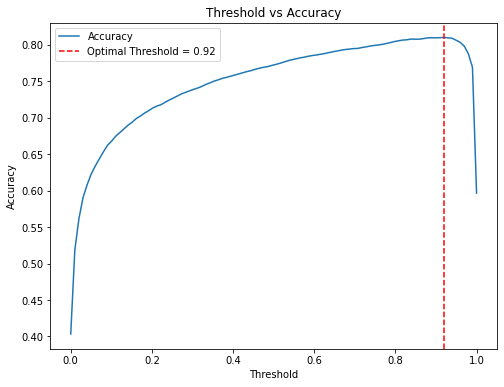

Optimal Threshold: 0.9191919191919192, Maximum Accuracy: 0.8099095022624434


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths to the files
path_numu = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.root_scored.h5'
path_anue = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.root_scored.h5'

# Load the data
df_anue = pd.read_hdf(path_anue, 'summary')  # Shower-like events
df_numu = pd.read_hdf(path_numu, 'summary')  # Track-like events

# Extract track_score
track_scores_anue = df_anue['track_score'].values  # Shower-like scores
track_scores_numu = df_numu['track_score'].values  # Track-like scores

# Assign labels
true_labels_anue = np.zeros(len(track_scores_anue))  # Shower-like events: label 0
true_labels_numu = np.ones(len(track_scores_numu))  # Track-like events: label 1

# Combine data
track_scores = np.concatenate([track_scores_anue, track_scores_numu])
true_labels = np.concatenate([true_labels_anue, true_labels_numu])

# Define thresholds to test
thresholds = np.linspace(0, 1, 100)

# Store accuracy values
accuracies = []

for threshold in thresholds:
    # Predict: 1 if track_score >= threshold, else 0
    predictions = (track_scores >= threshold).astype(int)
    
    # Compute accuracy
    accuracy = (predictions == true_labels).mean()
    accuracies.append(accuracy)

# Find the optimal threshold
optimal_threshold = thresholds[np.argmax(accuracies)]
max_accuracy = max(accuracies)

# Plot Accuracy vs Threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, accuracies, label="Accuracy")
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f"Optimal Threshold = {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Threshold vs Accuracy")
plt.legend()
plt.show()

print(f"Optimal Threshold: {optimal_threshold}, Maximum Accuracy: {max_accuracy}")


## Finding track_score_threshold by minimizing a custom cost function

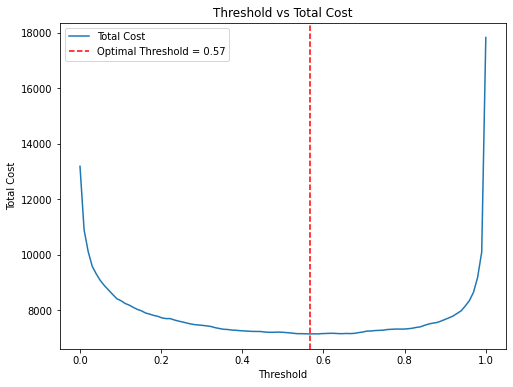

Optimal Threshold (Cost-Minimization): 0.5656565656565657, Minimum Total Cost: 7134


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths to the files
path_numu = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.root_scored.h5'
path_anue = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11.root_scored.h5'

# Load the data
df_anue = pd.read_hdf(path_anue, 'summary')  # Shower-like events
df_numu = pd.read_hdf(path_numu, 'summary')  # Track-like events

# Extract track_score
track_scores_anue = df_anue['track_score'].values  # Shower-like scores
track_scores_numu = df_numu['track_score'].values  # Track-like scores

# Assign labels
true_labels_anue = np.zeros(len(track_scores_anue))  # Shower-like events: label 0
true_labels_numu = np.ones(len(track_scores_numu))  # Track-like events: label 1

# Combine data
track_scores = np.concatenate([track_scores_anue, track_scores_numu])
true_labels = np.concatenate([true_labels_anue, true_labels_numu])

# Define thresholds to test
thresholds = np.linspace(0, 1, 100)

# Store accuracy values
accuracies = []

# Define costs
cost_fp = 1  # Cost of a false positive (shower-like misclassified as track-like)
cost_fn = 2  # Cost of a false negative (track-like misclassified as shower-like)

# Store total costs for each threshold
total_costs = []

for threshold in thresholds:
    # Predict: 1 if track_score >= threshold, else 0
    predictions = (track_scores >= threshold).astype(int)
    
    # Calculate FP and FN counts
    fp_count = ((predictions == 1) & (true_labels == 0)).sum()  # False Positives
    fn_count = ((predictions == 0) & (true_labels == 1)).sum()  # False Negatives
    
    # Calculate total cost
    total_cost = (fp_count * cost_fp) + (fn_count * cost_fn)
    total_costs.append(total_cost)

# Find the optimal threshold
optimal_threshold_cost = thresholds[np.argmin(total_costs)]
min_total_cost = min(total_costs)

# Plot Total Cost vs Threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, total_costs, label="Total Cost")
plt.axvline(optimal_threshold_cost, color='red', linestyle='--', label=f"Optimal Threshold = {optimal_threshold_cost:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Total Cost")
plt.legend()
plt.show()

print(f"Optimal Threshold (Cost-Minimization): {optimal_threshold_cost}, Minimum Total Cost: {min_total_cost}")


## Plotting Sky Map with energies and distances to source

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Circle

def plot_energy_sky_map(ra, dec, energy):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="mollweide")
    
    # Convert RA, Dec to radians for plotting
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)
    
    # Plot the points, color coded by energy
    scatter = ax.scatter(ra_rad, dec_rad, c=energy, cmap="viridis", s=5, alpha=0.7)
    cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label("Particle Energy")
    
    ax.grid(True)
    ax.set_title("Sky Map of Detected Particles with Energy")
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.show()



In [16]:
import h5py
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5
from km3astro.io import load_hdf5_tables
# path = '/home/hpc/capn/capn107h/software/nextflow_output/signal/mcv8.1.gsg_combined_eventlist_corrected_0.0035Hz_1.0-signal_mvm.hdf5'
# path = '/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/mcv8.1.gsg_combined_eventlist.hdf5'
path = '/home/hpc/capn/capn107h/software/nextflow_output/input/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11_arca.h5'
file = load_hdf5_tables(path)

RECO_EVENTS is present
MC_EVENTS is present


In [26]:
from km3astro.coord import local_event#

from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time

detector_location = 'arca'

energy = file.mc_table['energy']
times = file.id_table['timeslice_utc_time']
phi_det = file.mc_table['phi_detectorframe']
theta_det = file.mc_table['theta_detectorframe']

event_location = local_event(np.array(theta_det), np.array(phi_det), times, detector_location)
print(event_location)

event_location_icrs = event_location.transform_to('icrs')

# Extract RA and Dec
ra = event_location_icrs.ra
dec = event_location_icrs.dec

print(f"RA: {ra}, Dec: {dec}")

<SkyCoord (AltAz: obstime=[1.66396680e+09 1.66396680e+09 1.66396680e+09 ... 1.66397759e+09
 1.66397760e+09 1.66397760e+09], location=(4945424.54119282, 1415794.27389803, 3752331.71356479) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [( 21.62953902,  23.93292839), (213.82727704,  11.63286219),
     (160.31505539,  33.39126224), ..., ( 15.9737377 , -16.88473281),
     (  0.97531574,  20.53704111), (337.64668607,  52.35043894)]>
RA: [ 90.6434054  293.05064167 350.56024447 ... 179.7937491  195.24955108
 341.17250495] deg, Dec: [ 67.66487966 -32.48993117 -18.05642988 ...  34.84331715  74.34120023
  67.39539794] deg


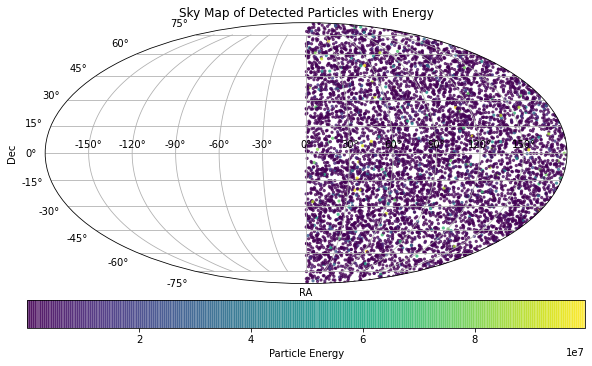

In [27]:
plot_energy_sky_map(ra, dec, energy)

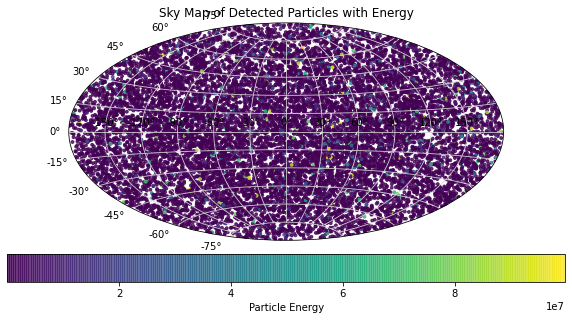

In [32]:
import km3astro.plot

def plot_energy_sky_map_km3(evts, energy):
    """
    Plot a sky map of detected particles, color-coded by energy.
    
    Parameters:
    - evts: SkyCoord object containing RA and Dec of the particles.
    - energy: List or array of particle energies.
    """
    fig, ax = km3astro.plot.projection_axes(projection="aitoff", figsize=(10, 5))
    ra, dec = km3astro.plot.ra_dec(evts)
    
    # Scatter plot with color coding for energy
    scatter = ax.scatter(ra, dec, c=energy, cmap="viridis", s=8, alpha=0.8)
    cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label("Particle Energy")
    
    ax.set_title("Sky Map of Detected Particles with Energy")
    plt.show()

evt_equat = event_location.transform_to("icrs")
plot_energy_sky_map_km3(evt_equat,energy)

In [35]:
from h5py import File

source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"

with File(source_file, 'r') as f:
    source_name = f['source_name'][()]
    print("Source Name:", source_name)

    # SkyCoord information
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    print("SkyCoord:", skycoord)

source_location = skycoord

Source Name: b'Vela_X-1'
SkyCoord: <SkyCoord (ICRS): (ra, dec) in deg
    (135.5286, -40.5547)>


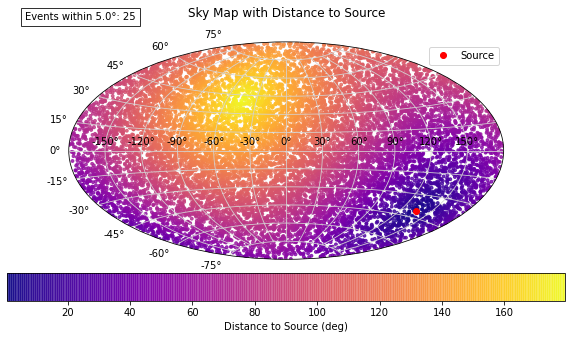

In [48]:
def plot_distance_sky_map_km3(evts, source_coord, radius=5 * u.degree):
    """
    Plot a sky map with particle distance to a source color-coded.
    
    Parameters:
    - evts: SkyCoord object containing RA and Dec of the particles.
    - source_coord: SkyCoord object of the source location.
    - radius: Angular radius for dashed circle around the source (default: 5 degrees).
    """
    fig, ax = km3astro.plot.projection_axes(projection="aitoff", figsize=(10, 5))
    ra, dec = km3astro.plot.ra_dec(evts)
    
    # Compute distances from the source
    distances = evts.separation(source_coord)
    
    # Scatter plot with color coding for distance
    scatter = ax.scatter(ra, dec, c=distances.degree, cmap="plasma", s=8, alpha=0.8)
    cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label("Distance to Source (deg)")
    
    # Add a dashed circle for the specified radius
    circle_radius = radius.to(u.radian).value
    ax.plot(
        [source_coord.ra.wrap_at(180 * u.degree).radian],
        [source_coord.dec.radian],
        "ro", markersize=6, label="Source"
    )
    ax.legend(loc="upper right", frameon=True)
    
    # Count particles within the circle
    count_in_circle = np.sum(distances <= radius)
    ax.text(
        -0.1,
        1.1,
        f"Events within {radius.value:.1f}°: {count_in_circle}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8),
    )
    
    ax.set_title("Sky Map with Distance to Source",pad=25)
    plt.show()


plot_distance_sky_map_km3(evt_equat, source_location, radius=5 * u.degree)

In [18]:
import matplotlib.colors as mcolors
from astropy.coordinates import EarthLocation, AltAz
from km3astro.constants import (
    arca_longitude, arca_latitude, arca_height,
    orca_longitude, orca_latitude, orca_height,
    antares_longitude, antares_latitude, antares_height,
)
import astropy.units as u

def plot_combined_sky_map_km3(evts, energy, source_coord, source_name, time, radius=5 * u.degree, fade_distance = False):
    """
    Plot a sky map with particle energy color-coded and alpha controlled by distance to a source.
    
    Parameters:
    - evts: SkyCoord object containing RA and Dec of the particles.
    - energy: List or array of particle energies.
    - source_coord: SkyCoord object of the source location.
    - radius: Angular radius for dashed circle around the source (default: 5 degrees).
    """
    fig, ax = km3astro.plot.projection_axes(projection="aitoff", figsize=(12, 6))
    ra, dec = km3astro.plot.ra_dec(evts)
    
    # Compute distances from the source
    distances = evts.separation(source_coord).degree
    
    # Normalize distances for alpha scaling
    max_distance = 180 # distances.max()
    alpha_values = 1 - (distances / max_distance)  # Closer = more intense (alpha = 1)
    alpha_values = 0.5*(np.cos((distances/max_distance)*np.pi)+1)
    alpha_values[alpha_values < 0] = 0  # Clamp negative alphas to zero
    
    # Normalize energy for color coding
    energy_normalized = (energy - energy.min()) / (energy.max() - energy.min())

        # Map energy values to sizes (normalize and scale)
    size_min = 5  # Minimum dot size
    size_max = 100  # Maximum dot size
   
    sizes = size_min + energy_normalized * (size_max - size_min)
    
    # Create RGBA colors using a colormap
    cmap = plt.cm.viridis
    colors = cmap(energy_normalized)
    
    if fade_distance == True: colors[:, -1] = alpha_values  # Set alpha channel for transparency
    
    # Scatter plot with RGBA colors
    scatter = ax.scatter(ra, dec, color=colors, s=sizes, edgecolors="none")
        # Use logarithmic normalization for the colormap
    norm_lin = plt.Normalize(vmin=energy.min(), vmax=energy.max())
    norm_log = mcolors.LogNorm(vmin=max(energy.min(), 1e-5), vmax=energy.max())  # Avoid log(0)
    cmap = plt.cm.viridis
    # Add a colorbar for energy
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_log)
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.07)
    cbar.set_label("Neutrino Energy")
    
    # Add a dashed circle for the specified radius
    ax.scatter(
        [source_coord.ra.wrap_at(180 * u.degree).radian],
        [source_coord.dec.radian],
        color= "deeppink",  lw=6, label=source_name
    )
    ax.legend(loc="upper left", frameon=True, fontsize=10)
    
    circle_radius = radius.to(u.radian).value
    ax.add_artist(
        plt.Circle(
            (source_coord.ra.wrap_at(180 * u.degree).radian, source_coord.dec.radian),
            circle_radius,
            transform=ax.transData,
            edgecolor="deeppink",
            facecolor="none",
            linestyle="--",
            linewidth=2,
            alpha=1,
            label=f"Circle Radius: {radius.value:.1f}°",
        )
    )
    
    # Count particles within the circle
    count_in_circle = np.sum(distances <= radius.value)
    text_box_content = f"Events within {radius.value:.1f}°: {count_in_circle}"
    
    # Add a text box with the count, aligned to the left
    ax.text(
        -0.1, 1.1, text_box_content, fontsize=10, transform=ax.transAxes,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
    )

        # Add detector locations
    detectors = {
        #"ARCA": EarthLocation(lat=arca_latitude*u.deg, lon=arca_longitude*u.deg, height=arca_height*u.m),
        #"ORCA": EarthLocation(lat=orca_latitude*u.deg, lon=orca_longitude*u.deg, height=orca_height*u.m),
        #"ANTARES": EarthLocation(lat=antares_latitude*u.deg, lon=antares_longitude*u.deg, height=antares_height*u.m),
    }
    
    for name, location in detectors.items():
        sky_location = SkyCoord(location.get_itrs(obstime=time))
        ra_det, dec_det = km3astro.plot.ra_dec(sky_location.icrs)
        ax.plot(ra_det, dec_det, "o", label=name, markersize=8)
    
    # Add legend for detectors
    ax.legend(loc="lower right", frameon=True, fontsize=10)
    
    # Enhance plot aesthetics
    ax.set_title("Sky Map with Event Energy for a Single Run", fontsize=16, pad=30)
    plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.05)  # Improve layout
    plt.show()


In [7]:
from km3astro.coord import local_event

from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time
import h5py
from astropy.io.misc.hdf5 import write_table_hdf5, read_table_hdf5
from km3astro.io import load_hdf5_tables, root_to_hdf5

# path = '/home/hpc/capn/capn107h/software/nextflow_output/signal/mcv8.1.gsg_combined_eventlist_corrected_0.0035Hz_1.0-signal_mvm.hdf5'
# path = '/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/mcv8.1.gsg_combined_eventlist.hdf5'
# path = '/home/hpc/capn/capn107h/software/nextflow_output/input/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013298.jchain.aashower.11_arca.h5'
rootpath = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/electron/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.root"

root_to_hdf5(rootpath)

The file contains MC-generated data.
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
is_mc_data == True
File written: mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.h5
Total time: 6.826 seconds


Source Name: Vela_X-1
SkyCoord: <SkyCoord (ICRS): (ra, dec) in deg
    (135.5286, -40.5547)>
RECO_EVENTS is present
MC_EVENTS is present
<SkyCoord (AltAz: obstime=[1.66419360e+09 1.66419360e+09 1.66419360e+09 ... 1.66420439e+09
 1.66420440e+09 1.66420440e+09], location=(4945424.54119282, 1415794.27389803, 3752331.71356479) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [( 58.4855767 ,   5.71097176), (338.05956345, -11.37015597),
     (345.36405754,  40.16426201), ..., (136.61176814,  66.99251233),
     ( 89.46421114,  23.31905542), (348.15163127,  -9.60719485)]>
RA: [306.03679171  48.60819546 133.61692628 ... 262.54340426 317.20714748
  81.97363373] deg, Dec: [28.48631427 37.96051627 77.9745178  ... 18.42834225 13.86508672
 42.74742264] deg


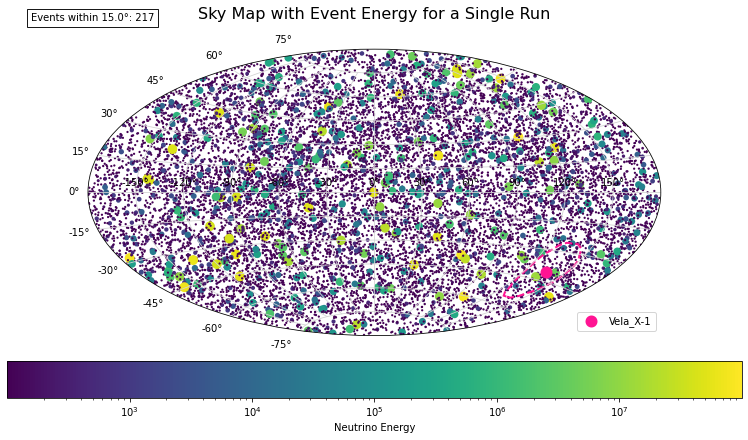

In [22]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Circle
from km3astro import plot

from h5py import File

source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
#source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/4U_1538-52.h5"
#source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/OAO_1657-415.h5"

with File(source_file, 'r') as f:
    source_name = f['source_name'][()].decode('utf-8')
    print("Source Name:", source_name)

    # SkyCoord information
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    print("SkyCoord:", skycoord)

source_location = skycoord

path = "mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.h5"
file = load_hdf5_tables(path)
detector_location = 'arca'

energy = file.mc_table['energy']
times = file.id_table['timeslice_utc_time']
phi_det = file.mc_table['phi_detectorframe']
theta_det = file.mc_table['theta_detectorframe']

event_location = local_event(np.array(theta_det), np.array(phi_det), times, detector_location)
print(event_location)

event_location_icrs = event_location.transform_to('icrs')

# Extract RA and Dec
ra = event_location_icrs.ra
dec = event_location_icrs.dec

print(f"RA: {ra}, Dec: {dec}")
evt_equat = event_location.transform_to("icrs")
plot_combined_sky_map_km3(evt_equat, energy, source_location, source_name, radius=15 * u.degree, time = times[0])#, fade_distance=True)


In [ ]:
# path = '/home/hpc/capn/capn107h/software/psr/data/IceCube/20150820_Astrophysical_muon_neutrino_flux_northern_sky/observed_events'
path = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/gsg_muon-CC_1.0-100.0GeV.110.km3sim.jte.jmergefit.aanet.root_scored.h5'
# path = '/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/gsg_elec-CC_1.0-100.0GeV.110.km3sim.jte.jshower.aanet.root_scored.h5'
import pandas as pd
df = pd.read_hdf(path,'summary')
df

,AASHOWERFIT_ENERGY,AASHOWERFIT_NUMBER_OF_HITS,JCOPY_Z_M,JENERGY_CHI2,JENERGY_ENERGY,JENERGY_MAXIMAL_ENERGY,JENERGY_MINIMAL_ENERGY,JENERGY_MUON_RANGE_METRES,JENERGY_NDF,JENERGY_NOISE_LIKELIHOOD,...,pos_z,run_id,t_gen,trigger_counter,w1,w2,w3,weight_one_year,group_id,track_score
0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,32.178665,110.0,1.0,11.0,404635.468750,0.008116,1.849861e-08,1.279728,0.0,0.002043
1,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,207.334030,110.0,1.0,132.0,337564.437500,48.746010,7.591570e-07,7686.270508,1.0,0.002043
2,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,33.406113,110.0,1.0,297.0,209586.500000,1.311432,1.512653e-07,206.786682,2.0,0.002043
3,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,107.199097,110.0,1.0,340.0,232164.984375,0.147292,6.576096e-08,23.224941,3.0,0.002043
4,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,158.199112,110.0,1.0,342.0,368226.562500,0.011940,2.624716e-08,1.882776,4.0,0.002043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,178.456345,110.0,1.0,199571.0,241071.625000,0.827462,1.365042e-07,130.474213,2221.0,0.002043
2222,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,36.020176,110.0,1.0,199640.0,405459.625000,0.041967,3.653486e-08,6.617422,2222.0,0.002043
2223,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,50.976158,110.0,1.0,199667.0,372891.750000,0.032418,2.892762e-08,5.111654,2223.0,0.002043
2224,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,-1234.0,...,171.630997,110.0,1.0,199738.0,388459.000000,0.036869,3.846414e-08,5.813513,2224.0,0.002043


In [2]:
from h5py import File, Group
import os
from astropy.table import Table, Column
from astropy.time import Time
from astropy.io.misc.hdf5 import read_table_hdf5

path = '/home/hpc/capn/capn107h/software/nextflow_output/eff_statistic/SNR_0_StatisticOverSNR.hdf5'
file = read_table_hdf5(path)

In [26]:
from scipy.stats.distributions import chi2
snr_list = file.columns[0]
max_chi2_list = file.columns[1]
print(max_chi2_list)
pvalue = chi2.sf(max_chi2_list , 31)

log_pvalue = chi2.logsf(max_chi2_list, 31)
print(log_pvalue)

print(max_chi2_list.max())
print(max_chi2_list.min())


print(pvalue.max())
print(pvalue.min())


  Max_Mean_Chi2   
------------------
 50.60034922907001
 644.1829598514174
326.43936459539975
 77.16781644956845
 404.5364266431328
 595.3721058892738
109.25749646421443
 365.6280662983267
 92.73197334174037
51.334152435021664
               ...
197.39043140978075
1986.0635614583534
 451.2879125421417
1435.1396618385909
171.71301244444646
 935.3783100500647
56.435068858902696
 1078.066036728626
125.69078578520154
 64.28480339870029
1605.3079887005451
Length = 40 rows
[  -4.22815953 -264.8473673  -115.78530184  -11.70546804 -151.74202627
 -241.58064004  -22.85749233 -133.74600828  -16.91073089   -4.40061557
 -103.2309607  -217.30862845  -85.39188506 -342.74715644 -190.31314022
 -429.48664571 -531.44708696 -368.08350803 -608.5058743  -504.26615098
 -284.64770433 -689.0985128  -579.45836799          -inf  -71.32436359
          -inf  -37.12600374 -318.85614543          -inf  -58.49069197
          -inf -173.53987857 -648.73624172  -47.64736293 -405.05148931
   -5.66395881 -474.3409529   

0.014579198401524789
0.0


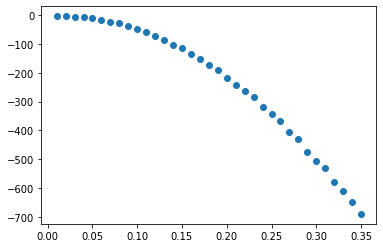

In [27]:
import matplotlib.pyplot as plt

plt.scatter(snr_list,log_pvalue)
plt.yscale('linear')

print(pvalue.max())
print(pvalue.min())

### Plots for visualizing source visibility

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.coordinates import SkyCoord
import astropy.units as u
from km3astro import plot
from km3astro.io import load_hdf5_tables
from h5py import File

from km3astro.coord import local_event

from astropy.time import Time
from km3astro.io import load_hdf5_tables, root_to_hdf5

def plot_combined_sky_map_km3(data_files, source_file, radius=5 * u.degree, fade_distance=False):
    """
    Plot a combined sky map with particle energy color-coded and alpha controlled by distance to a source.
    
    Parameters:
    - data_files: List of file paths to the HDF5 event data files.
    - source_file: Path to the HDF5 file containing source information.
    - radius: Angular radius for the selection circle (default: 5 degrees).
    - fade_distance: Whether to fade events based on distance from the source.
    """
    # Load source information
    with File(source_file, 'r') as f:
        source_name = f['source_name'][()].decode('utf-8')
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    
    all_ra, all_dec, all_energy = [], [], []
    total_events = 0
    
    # Load event data from multiple files
    for path in data_files:
        file = load_hdf5_tables(path)
        energy = file.mc_table['energy']
        times = file.id_table['timeslice_utc_time']
        phi_det = file.mc_table['phi_detectorframe']
        theta_det = file.mc_table['theta_detectorframe']
        
        event_location = local_event(np.array(theta_det), np.array(phi_det), times, 'arca')
        event_location_icrs = event_location.transform_to('icrs')
        
        all_ra.extend(event_location_icrs.ra.deg)
        all_dec.extend(event_location_icrs.dec.deg)
        all_energy.extend(energy)
        total_events += len(energy)
    
    # Convert lists to arrays
    all_ra = np.array(all_ra)
    all_dec = np.array(all_dec)
    all_energy = np.array(all_energy)
    
    # Compute distances from the source
    event_coords = SkyCoord(ra=all_ra * u.deg, dec=all_dec * u.deg)
    distances = event_coords.separation(source_coord).degree
    
    # Count selected events
    count_in_circle = np.sum(distances <= radius.value)
    selection_ratio = count_in_circle / total_events if total_events > 0 else 0
    
    # Normalize distances for alpha scaling
    max_distance = 180
    alpha_values = 0.5 * (np.cos((distances / max_distance) * np.pi) + 1)
    alpha_values[alpha_values < 0] = 0
    
    # Normalize energy for color coding
    energy_min, energy_max = all_energy.min(), all_energy.max()
    energy_normalized = (all_energy - energy_min) / (energy_max - energy_min)
    
    # Map energy values to sizes
    size_min, size_max = 5, 100
    sizes = size_min + energy_normalized * (size_max - size_min)
    
    # Create RGBA colors
    cmap = plt.cm.viridis
    colors = cmap(energy_normalized)
    if fade_distance:
        colors[:, -1] = alpha_values  # Adjust alpha transparency
    
    # Plot setup
    fig, ax = plot.projection_axes(projection="aitoff", figsize=(12, 6))
    scatter = ax.scatter(np.radians(all_ra - 180), np.radians(all_dec), color=colors, s=sizes, edgecolors="none")
    
    # Colorbar setup
    norm_log = mcolors.LogNorm(vmin=max(energy_min, 1e-5), vmax=energy_max)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_log)
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.07)
    cbar.set_label("Neutrino Energy")
    
    # Plot the source
    ax.scatter(
        [np.radians(source_coord.ra.wrap_at(180 * u.degree).degree)],
        [np.radians(source_coord.dec.degree)],
        color="deeppink", lw=6, label=source_name
    )
    
    # Plot selection circle
    circle_radius = np.radians(radius.to(u.deg).value)
    ax.add_patch(plt.Circle(
        (np.radians(source_coord.ra.wrap_at(180 * u.degree).degree), np.radians(source_coord.dec.degree)),
        circle_radius,
        transform=ax.transData,
        edgecolor="deeppink",
        facecolor="none",
        linestyle="--",
        linewidth=2,
        alpha=1,
    ))
    
    # Create an additional axis for legend and text box
    right_ax = fig.add_axes([0.82, 0.3, 0.15, 0.4])  # x, y, width, height
    right_ax.axis("off")  # Hide the axis

    # Add the legend at the top of the right panel
    legend_handles, legend_labels = ax.get_legend_handles_labels()
    legend = right_ax.legend(
        legend_handles, legend_labels, loc="upper center", frameon=True, fontsize=10
    )

    # Add the text box right below the legend
    text_box_content = (f"Total events: {total_events}\n"
                        f"Events within {radius.value:.1f}°: {count_in_circle}\n"
                        f"Selection ratio: {selection_ratio*100:.2f} %")
    right_ax.text(
        0.5, 0.7, text_box_content, fontsize=10, transform=right_ax.transAxes,
        verticalalignment="top", horizontalalignment="center",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
    )

    ax.set_title("Combined Sky Map with Event Energy", fontsize=16, pad=30)
    plt.show()



In [35]:
rootpath = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/electron/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.root"
rootpath = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/electron/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013323.jchain.aashower.34.root"
root_to_hdf5(rootpath)

The file contains MC-generated data.
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
is_mc_data == True
File written: mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013323.jchain.aashower.34.h5
Total time: 6.319 seconds


RECO_EVENTS is present
MC_EVENTS is present


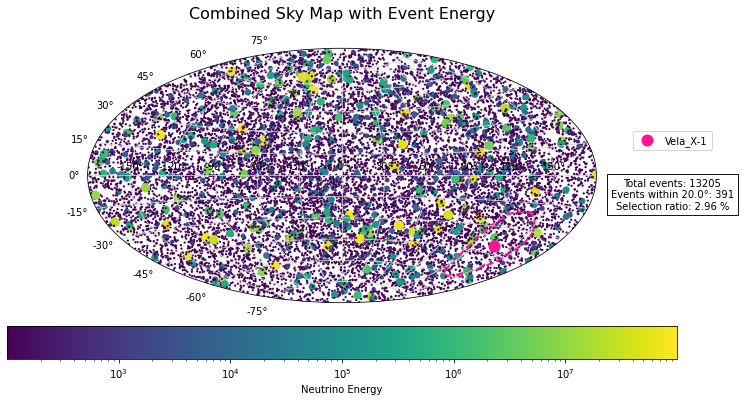

In [4]:
source_path = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
data_path = ["mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.h5","mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013323.jchain.aashower.34.h5"]
data_path = ["mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013322.jchain.aashower.33.h5"]

radius = 20.0 *u.degree

plot_combined_sky_map_km3(data_path,source_path,radius)

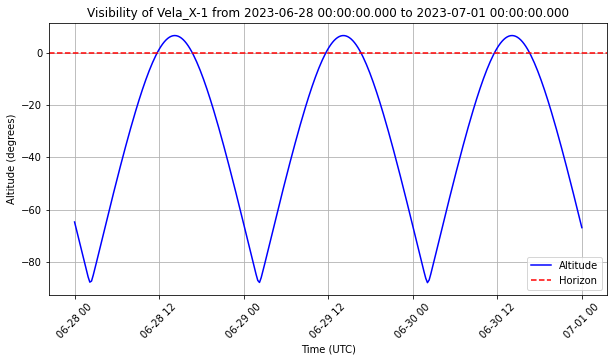

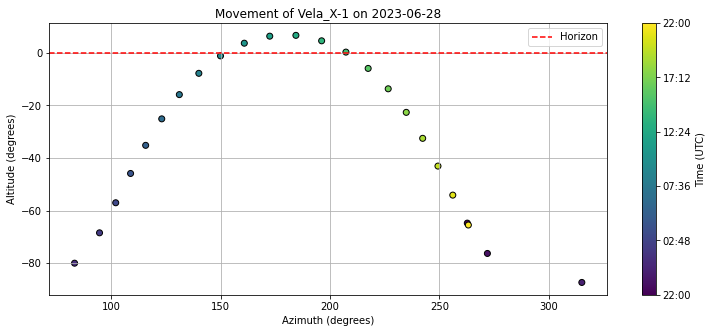

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import astropy.units as u
from h5py import File

def plot_source_visibility(source_file, detector_location, observation_date, num_days=1):
    """
    Plot the movement of a source over multiple days as seen from a given detector location.

    Parameters:
    - source_file: Path to the HDF5 file containing source information.
    - detector_location: EarthLocation object representing the detector.
    - observation_date: Date string (e.g., '2023-06-28') for the observation start.
    - num_days: Number of days to visualize in the altitude-time plot.
    """
    # Load source coordinates
    with File(source_file, 'r') as f:
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
        source_name = f['source_name'][()].decode('utf-8')

    # Compute time range for altitude-time plot (spanning multiple days)
    start_time = Time(observation_date)
    end_time = start_time + num_days * u.day
    times_altitude = start_time + np.linspace(0, num_days * 24, 300) * u.hour  # 300 points over multiple days

    # Convert to AltAz frame for given detector location
    altaz_frame = AltAz(obstime=times_altitude, location=detector_location)
    source_altaz = source_coord.transform_to(altaz_frame)

    # Plot altitude vs. time (multiple days)
    plt.figure(figsize=(10, 5))
    plt.plot(times_altitude.datetime, source_altaz.alt.deg, label="Altitude", c='b')
    plt.axhline(0, color='r', linestyle='--', label='Horizon')
    plt.xlabel("Time (UTC)")
    plt.ylabel("Altitude (degrees)")
    plt.legend()
    plt.title(f"Visibility of {source_name} from {start_time.iso} to {end_time.iso}")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

    # Compute time range for sky map (single day, hourly points)
    times_sky = start_time + np.linspace(0, 24, 24) * u.hour
    mjd_times = times_sky.mjd  # Convert times to numerical format (Modified Julian Date)

    # Convert to AltAz frame
    altaz_frame_sky = AltAz(obstime=times_sky, location=detector_location)
    source_altaz_sky = source_coord.transform_to(altaz_frame_sky)

    # Plot source movement on a sky map (single day)
    plt.figure(figsize=(12.5, 5))
    scatter = plt.scatter(
        source_altaz_sky.az.deg,
        source_altaz_sky.alt.deg,
        c=mjd_times,  # Use numerical representation for colors
        cmap='viridis',
        edgecolors='k'
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label("Time (UTC)")
    
    # **Fix: Convert time labels properly**
    time_labels_timestamps = np.linspace(
        times_sky[0].datetime.timestamp(),
        times_sky[-1].datetime.timestamp(),
        6  # Number of ticks
    )
    time_labels = [Time(t, format='unix').datetime for t in time_labels_timestamps]

    cbar.set_ticks(np.linspace(mjd_times[0], mjd_times[-1], 6))
    cbar.set_ticklabels([t.strftime('%H:%M') for t in time_labels])

    plt.axhline(0, color='r', linestyle='--', label='Horizon')
    plt.xlabel("Azimuth (degrees)")
    plt.ylabel("Altitude (degrees)")
    plt.title(f"Movement of {source_name} on {observation_date}")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
detector_location = EarthLocation(lat=42.6*u.deg, lon=6.0*u.deg, height=-2475*u.m)  # Example for ARCA
observation_date = "2023-06-28"
num_days = 3  # Number of days for altitude-time plot

plot_source_visibility(source_file, detector_location, observation_date, num_days)



In [2]:
old_data_path = "/home/hpc/capn/mppi104h/wecapstor3/out/ARCA/KM3NeT_00000133/v8.1/reco/muon/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013318.jchain.aashower.30.root"
data_path = "/home/wecapstor3/capn/capn107h/datav8.1.1.jchain.aashower.00014081.root"
mc_path = "/home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root"

import numpy as np
import matplotlib.pyplot as plt
from km3astro.io import load_hdf5_tables, root_to_hdf5

root_to_hdf5(data_path)
root_to_hdf5(mc_path)
root_to_hdf5(old_data_path)

The file contains real data. Or at least doesn't have any entries in mc_trks.id ...
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
File written: datav8.1.1.jchain.aashower.00014081.h5
Total time: 22.628 seconds
The file contains MC-generated data.
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
is_mc_data == True
File written: mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5
Total time: 5.948 seconds
The file contains MC-generated data.
header_table created...
id_table created...
No jshower reconstructions for this file!
No dusjshower reconstructions for this file!
reco_table created...
is_mc_data == True
File written: mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013318.jchain.aashower.30.h5
Total time: 1.914 seconds


In [3]:
hdf5_data_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/datav8.1.1.jchain.aashower.00014081.h5"
hdf5_mc_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.h5"
hdf5_old_data_path = "/home/hpc/capn/capn107h/software/psr/src/notebooks/mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013318.jchain.aashower.30.h5"
data = load_hdf5_tables(hdf5_data_path)
mc = load_hdf5_tables(hdf5_mc_path)
old_data = load_hdf5_tables(hdf5_old_data_path)

RECO_EVENTS is present
MC_EVENTS is NOT present
RECO_EVENTS is present
MC_EVENTS is present
RECO_EVENTS is present
MC_EVENTS is present


In [4]:
import h5py
import numpy as np

def compare_hdf5_files(file1, file2):
    """
    Compare the structure and contents of two HDF5 files.

    Parameters
    ----------
    file1 : str
        Path to the first HDF5 file.
    file2 : str
        Path to the second HDF5 file.

    Returns
    -------
    None
    """
    def get_structure(h5file):
        """Extract dataset structure: shape and dtype."""
        structure = {}
        def visit_fn(name, obj):
            if isinstance(obj, h5py.Dataset):
                structure[name] = (obj.shape, obj.dtype)
        h5file.visititems(visit_fn)
        return structure

    def compare_datasets(dset1, dset2, name):
        """Compare basic statistics of two datasets."""
        if dset1.shape != dset2.shape or dset1.dtype != dset2.dtype:
            print(f"Mismatch in dataset '{name}': Shape {dset1.shape} vs {dset2.shape}, Type {dset1.dtype} vs {dset2.dtype}")
            return

        try:
            data1, data2 = dset1[:], dset2[:]
            if np.issubdtype(data1.dtype, np.number):
                stats1 = (np.mean(data1), np.min(data1), np.max(data1))
                stats2 = (np.mean(data2), np.min(data2), np.max(data2))
                if not np.allclose(stats1, stats2, equal_nan=True):
                    print(f"Data mismatch in '{name}': Mean/Min/Max {stats1} vs {stats2}")
        except:
            print(f"Could not compare data in '{name}'.")

    with h5py.File(file1, "r") as h5file1, h5py.File(file2, "r") as h5file2:
        structure1, structure2 = get_structure(h5file1), get_structure(h5file2)

        all_keys = set(structure1.keys()) | set(structure2.keys())

        for key in all_keys:
            if key not in structure1:
                print(f"'{key}' is missing in {file1}")
            elif key not in structure2:
                print(f"'{key}' is missing in {file2}")
            else:
                dset1, dset2 = h5file1[key], h5file2[key]
                if isinstance(dset1, h5py.Dataset) and isinstance(dset2, h5py.Dataset):
                    compare_datasets(dset1, dset2, key)
                else:
                    print(f"'{key}' is a group, skipping data comparison.")

# Example usage
compare_hdf5_files(hdf5_mc_path, hdf5_old_data_path)


Mismatch in dataset 'MC/MC_EVENTS': Shape (13274,) vs (8829,), Type [('event_id', '<i8'), ('energy', '<f8'), ('pdg_id', '<i4'), ('normalized_weight', '<f8'), ('theta_detectorframe', '<f8'), ('phi_detectorframe', '<f8'), ('pos_x', '<f8'), ('pos_y', '<f8'), ('pos_z', '<f8')] vs [('event_id', '<i8'), ('energy', '<f8'), ('pdg_id', '<i4'), ('normalized_weight', '<f8'), ('theta_detectorframe', '<f8'), ('phi_detectorframe', '<f8'), ('pos_x', '<f8'), ('pos_y', '<f8'), ('pos_z', '<f8')]
Mismatch in dataset 'ID': Shape (13274,) vs (8829,), Type [('event_id', '<i8'), ('timeslice_utc_time.jd1', '<f8'), ('timeslice_utc_time.jd2', '<f8')] vs [('event_id', '<i8'), ('timeslice_utc_time.jd1', '<f8'), ('timeslice_utc_time.jd2', '<f8')]
Mismatch in dataset 'RECO/RECO_EVENTS': Shape (24485,) vs (16641,), Type [('event_id', '<i8'), ('rec_type', '<i8'), ('rec_stage', '<i8'), ('tracktime_utc.jd1', '<f8'), ('tracktime_utc.jd2', '<f8'), ('tracktime_ns', '<f8'), ('energy', '<f8'), ('likelihood', '<f8'), ('theta

In [5]:
mc.__dict__

{'header_table': <Table length=24>
      Parameter       ...
       bytes20        ...
 -------------------- ...
                  DAQ ...
             GXMLPATH ...
             XSecFile ...
 aashowerfit_detector ...
           coord_site ...
               cut_nu ...
                depth ...
             detector ...
              drawing ...
             fixedcan ...
                  ... ...
            physics_2 ...
            physics_3 ...
              primary ...
                 seed ...
                simul ...
              simul_1 ...
          source_mode ...
             spectrum ...
            start_run ...
        time_interval ...,
 'id_table': <Table length=13274>
 event_id timeslice_utc_time
  int64         object      
 -------- ------------------
        0 1663858800.4554603
        1 1663858801.1950321
        2  1663858801.835368
        3  1663858803.255722
        4 1663858804.8484943
        5 1663858805.7450087
        6 1663858807.0216522
        7  16638

In [6]:
from km3io import OfflineReader

offline_mc = OfflineReader(mc_path)
offline_data = OfflineReader(data_path)
offline_old_data = OfflineReader(old_data_path)

In [7]:
offline_mc.__dict__

{'_fobj': <ReadOnlyDirectory '/' at 0x7fb4aed73940>,
 '_filepath': '/home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root',
 '_step_size': 2000,
 '_uuid': UUID('23d2d9e6-b9eb-11ed-9c7a-51aa9e86beef'),
 '_iterator_index': 0,
 '_keys': {'comment',
  'det_id',
  'flags',
  'frame_index',
  'hits',
  'id',
  'index',
  'mc_event_time_ns',
  'mc_event_time_sec',
  'mc_hits',
  'mc_id',
  'mc_run_id',
  'mc_t',
  'mc_tracks',
  'mc_trks',
  'n_hits',
  'n_mc_hits',
  'n_mc_tracks',
  'n_mc_trks',
  'n_tracks',
  'n_trks',
  'overlays',
  'run_id',
  't_ns',
  't_sec',
  'tracks',
  'trigger_counter',
  'trigger_mask',
  'trks',
  'usr',
  'usr_names',
  'w',
  'w2list',
  'w3list'},
 '_event_ctor': km3io.rootio.OfflineEvent,
 '_index_chain': [],
 'aliases': {'mc_event_time_sec': 'mc_event_time/mc_event_time.fSec',
  'mc_event_time_ns': 'mc_event_time/mc_event_time.fNanoSec',
  't_sec': 't/t.fSec',
  't_ns': 't/t.fNanoSec',
  'usr': 

In [8]:
offline_old_data.mc_tracks.__dict__

{'_branch': <TBranchElement 'mc_trks' (26 subbranches) at 0x7fb4aece54e0>,
 'fields': ['id',
  'pos_x',
  'pos_y',
  'pos_z',
  'dir_x',
  'dir_y',
  'dir_z',
  'E',
  't',
  'len',
  'status',
  'mother_id',
  'counter',
  'pdgid',
  'hit_ids',
  'usr',
  'usr_names'],
 '_aliases': {'id': 'mc_trks.id',
  'pos_x': 'mc_trks.pos.x',
  'pos_y': 'mc_trks.pos.y',
  'pos_z': 'mc_trks.pos.z',
  'dir_x': 'mc_trks.dir.x',
  'dir_y': 'mc_trks.dir.y',
  'dir_z': 'mc_trks.dir.z',
  'E': 'mc_trks.E',
  't': 'mc_trks.t',
  'len': 'mc_trks.len',
  'status': 'mc_trks.status',
  'mother_id': 'mc_trks.mother_id',
  'counter': 'mc_trks.counter',
  'pdgid': 'mc_trks.type',
  'hit_ids': 'mc_trks.hit_ids',
  'usr': 'mc_trks.usr',
  'usr_names': 'mc_trks.usr_names'},
 '_index_chain': []}

In [19]:
path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/concatenated_hitfeatures/extracthitfeatures_concatenated.h5"
#path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/extracted_hitfeatures/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root.h5"
import h5py
f = h5py.File(path,"r")
print(list(f.keys()))
print(f['summary'].__dict__)


['summary']
{'_id': <h5py.h5g.GroupID object at 0x7f910fddd0f8>}


In [20]:
import pandas as pd
df = pd.read_hdf(path, 'summary')
print(df['pdgid'].value_counts())  # or df['pdgid'].value_counts()


-12    264968
Name: pdgid, dtype: int64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


h5_file = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/concatenated_hitfeatures/extracthitfeatures_concatenated.h5"

df = pd.read_hdf(h5_file, "summary")

# Print available columns to verify where event type is stored
print("Columns in DataFrame:", df.columns)

# Check unique values in event type column
event_column = "pdgid"  # Adjust if needed
if event_column in df.columns:
    print("Unique event types:", df[event_column].unique())
else:
    print(f"Column '{event_column}' not found in file. Check column names!")
    exit()

# Display counts per event type
print("\nEvent counts before selection:")
print(df[event_column].value_counts())

Columns in DataFrame: Index(['AASHOWERFIT_ENERGY', 'AASHOWERFIT_NUMBER_OF_HITS', 'JCOPY_Z_M',
       'JENERGY_CHI2', 'JENERGY_ENERGY', 'JENERGY_MAXIMAL_ENERGY',
       'JENERGY_MINIMAL_ENERGY', 'JENERGY_MUON_RANGE_METRES', 'JENERGY_NDF',
       'JENERGY_NOISE_LIKELIHOOD', 'JENERGY_NUMBER_OF_HITS',
       'JGANDALF_BETA0_RAD', 'JGANDALF_BETA1_RAD', 'JGANDALF_CHI2',
       'JGANDALF_LAMBDA', 'JGANDALF_NUMBER_OF_HITS',
       'JGANDALF_NUMBER_OF_ITERATIONS', 'JMUONFEATURES_NUMBER_OF_DOMS',
       'JMUONFEATURES_NUMBER_OF_LINES', 'JPP_COVERAGE_ORIENTATION',
       'JPP_COVERAGE_POSITION', 'JSHOWERFIT_ENERGY', 'JSTART_LENGTH_METRES',
       'JSTART_NPE_MIP', 'JSTART_NPE_MIP_MISSED', 'JSTART_NPE_MIP_TOTAL',
       'JVETO_NPE', 'JVETO_NUMBER_OF_HITS', 'aashower_cos_zenith',
       'aashower_dir_x', 'aashower_dir_y', 'aashower_dir_z', 'aashower_energy',
       'aashower_is_good', 'aashower_lik', 'aashower_pos_x', 'aashower_pos_y',
       'aashower_pos_z', 'bjorken_y_true', 'cos_zenith_true', '

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


h5_file = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/concatenated_hitfeatures/extracthitfeatures_concatenated.h5"

df = pd.read_hdf(h5_file, "summary")

# Print available columns to verify where event type is stored
print("Columns in DataFrame:", df.columns)

# Check unique values in event type column
event_column = "pdgid"  # Adjust if needed
if event_column in df.columns:
    print("Unique event types:", df[event_column].unique())
else:
    print(f"Column '{event_column}' not found in file. Check column names!")
    exit()

# Display counts per event type
print("\nEvent counts before selection:")
print(df[event_column].value_counts())

Columns in DataFrame: Index(['AASHOWERFIT_ENERGY', 'AASHOWERFIT_NUMBER_OF_HITS', 'JCOPY_Z_M',
       'JENERGY_CHI2', 'JENERGY_ENERGY', 'JENERGY_MAXIMAL_ENERGY',
       'JENERGY_MINIMAL_ENERGY', 'JENERGY_MUON_RANGE_METRES', 'JENERGY_NDF',
       'JENERGY_NOISE_LIKELIHOOD', 'JENERGY_NUMBER_OF_HITS',
       'JGANDALF_BETA0_RAD', 'JGANDALF_BETA1_RAD', 'JGANDALF_CHI2',
       'JGANDALF_LAMBDA', 'JGANDALF_NUMBER_OF_HITS',
       'JGANDALF_NUMBER_OF_ITERATIONS', 'JMUONFEATURES_NUMBER_OF_DOMS',
       'JMUONFEATURES_NUMBER_OF_LINES', 'JPP_COVERAGE_ORIENTATION',
       'JPP_COVERAGE_POSITION', 'JSHOWERFIT_ENERGY', 'JSTART_LENGTH_METRES',
       'JSTART_NPE_MIP', 'JSTART_NPE_MIP_MISSED', 'JSTART_NPE_MIP_TOTAL',
       'JVETO_NPE', 'JVETO_NUMBER_OF_HITS', 'aashower_cos_zenith',
       'aashower_dir_x', 'aashower_dir_y', 'aashower_dir_z', 'aashower_energy',
       'aashower_is_good', 'aashower_lik', 'aashower_pos_x', 'aashower_pos_y',
       'aashower_pos_z', 'bjorken_y_true', 'cos_zenith_true', '

In [12]:
import pandas as pd

# Load Set 2
df_set2 = pd.read_hdf(h5_file, "summary")  # Change filename

# Check unique values of `is_cc`
print("Unique values in is_cc:", df_set2["is_cc"].unique())

# Count muon events by `is_cc`
print("\nMuon event breakdown by CC/NC:")
print(df_set2[df_set2["pdgid"] == 14]["is_cc"].value_counts())

# Check count of muon_cc
muon_cc_count = len(df_set2[(df_set2["pdgid"] == 14) & (df_set2["is_cc"] == 1)])
muon_nc_count = len(df_set2[(df_set2["pdgid"] == 14) & (df_set2["is_cc"] == 0)])

print(f"\nmuon_cc count: {muon_cc_count}")
print(f"muon_nc count: {muon_nc_count}")


Unique values in is_cc: [0 1]

Muon event breakdown by CC/NC:
0    84478
Name: is_cc, dtype: int64

muon_cc count: 0
muon_nc count: 84478


In [15]:
import uproot

# Load ROOT file
root_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_parampid/work/9b/3bad176f14fb653e4bf0d433e8ada6/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013397.jchain.aashower.77.root"  # Replace with actual filename
#tree_name = "your_tree_name"  # Replace with actual tree name
#tree = uproot.open(f"{root_file}:{tree_name}")

#file = uproot.open(root_file)
#print(file.keys()) 
tree = file["E"]
#print(tree.keys()) 

# Print available branches
print("Available columns:", tree.keys())

# Load pdgid and is_cc from the ROOT file
root_df = tree.arrays(["pdgid", "is_cc"], library="pd")

# Check muon breakdown
print("\nMuon Event Breakdown in ROOT file:")
print(root_df[root_df["pdgid"] == 14]["is_cc"].value_counts())


Available columns: ['Evt', 'Evt/AAObject', 'Evt/AAObject/TObject', 'Evt/AAObject/TObject/fUniqueID', 'Evt/AAObject/TObject/fBits', 'Evt/AAObject/usr', 'Evt/AAObject/usr_names', 'Evt/AAObject/any', 'Evt/id', 'Evt/det_id', 'Evt/mc_id', 'Evt/run_id', 'Evt/mc_run_id', 'Evt/frame_index', 'Evt/trigger_mask', 'Evt/trigger_counter', 'Evt/overlays', 'Evt/t', 'Evt/t/t.fSec', 'Evt/t/t.fNanoSec', 'Evt/hits', 'Evt/hits/hits.fUniqueID', 'Evt/hits/hits.fBits', 'Evt/hits/hits.id', 'Evt/hits/hits.dom_id', 'Evt/hits/hits.channel_id', 'Evt/hits/hits.tdc', 'Evt/hits/hits.tot', 'Evt/hits/hits.trig', 'Evt/hits/hits.pmt_id', 'Evt/hits/hits.t', 'Evt/hits/hits.a', 'Evt/hits/hits.pos.x', 'Evt/hits/hits.pos.y', 'Evt/hits/hits.pos.z', 'Evt/hits/hits.dir.x', 'Evt/hits/hits.dir.y', 'Evt/hits/hits.dir.z', 'Evt/hits/hits.type', 'Evt/hits/hits.origin', 'Evt/hits/hits.pattern_flags', 'Evt/trks', 'Evt/trks/trks.fUniqueID', 'Evt/trks/trks.fBits', 'Evt/trks/trks.usr', 'Evt/trks/trks.usr_names', 'Evt/trks/trks.any', 'Evt/t

KeyInFileError: not found: 'pdgid'
in file /home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_parampid/work/9b/3bad176f14fb653e4bf0d433e8ada6/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013397.jchain.aashower.77.root
in object /E;1

In [16]:
tree.arrays(["Evt/mc_trks/mc_trks.id", "Evt/mc_trks/mc_trks.type"], library="pd").head()


Evt/mc_trks/mc_trks.id  Evt/mc_trks/mc_trks.type
entry subentry                                                  
0     0                              0                       -12
      1                              1                1000080160
      2                              4                       -11
      3                             11                       111
      4                             12                       211

In [17]:
tree.keys(filter_name="*int*")
tree.keys(filter_name="*proc*")
tree.keys(filter_name="*type*")


['Evt/hits/hits.type',
 'Evt/trks/trks.type',
 'Evt/trks/trks.rec_type',
 'Evt/mc_hits/mc_hits.type',
 'Evt/mc_trks/mc_trks.type',
 'Evt/mc_trks/mc_trks.rec_type']

In [1]:
import pandas as pd
h5_file = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/classified_files/datav8.1.1.jchain.aashower.00014081.root_scored.h5"
# Load Set 2
df_set2 = pd.read_hdf(h5_file, "summary")  # Change filename

In [4]:
df_set2['track_score']

0        0.675173
1        0.752658
2        0.733328
3        0.996963
4        0.992034
           ...   
88482    0.995878
88483    0.962138
88484    0.426513
88485    0.291534
88486    0.998083
Name: track_score, Length: 88487, dtype: float32

In [9]:
from km3io import OfflineReader

atm_mu_path = "/home/wecapstor3/capn/capn107h/atm_muons/mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.1.root"
atm_mu_file = OfflineReader(atm_mu_path)

In [38]:
atm_mu_file.mc_tracks[:,0].E

<Array [918, 2.02e+03, 391, ... 557, 5.13e+03] type='11412 * float64'>

In [34]:
import numpy as np
from astropy.time import Time

def get_utc_timeslice(OfflineObject):

    """
    Calculate UTC time of the timeslices where the events were put based on input data.

    Parameters:
    ----------
    OfflineObject : km3io.offline.OfflineReader
        Input data. Offline data runs: km3io.offline.OfflineReader Object.

    Returns:
    ----------
    tuple
        Tuple containing:N
        - times : list
            List of UTC timeslices in seconds
        - astropy_times : list
            List of astropy.time.Time objects of times
    """
    tsec = OfflineObject.t_sec
    tns = OfflineObject.t_ns
    S_TO_NS = np.uint64(1e9)

    # print("calculating timesclices ...")

    times = (
        tsec + tns / S_TO_NS
    )  # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(tsec, tns / S_TO_NS, format="unix")

    return times, astropy_times



In [ ]:
times, astropy_times = get_utc_timeslice(atm_mu_file)

print(astropy_times)

[1.6638588e+09 1.6638588e+09 1.6638588e+09 ... 1.6638696e+09 1.6638696e+09
 1.6638696e+09]


[1.6638588e+09 1.6638588e+09 1.6638588e+09 ... 1.6638696e+09 1.6638696e+09
 1.6638696e+09]


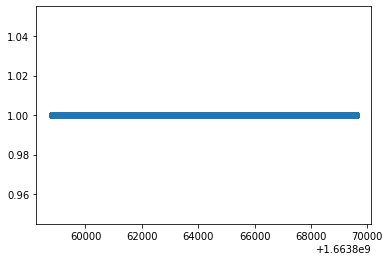

In [24]:
import matplotlib.pyplot as plt

print(np.array(times))

plt.scatter(np.array(times),np.ones_like(np.array(times)))


## Investigating Atmospheric Muon Flux

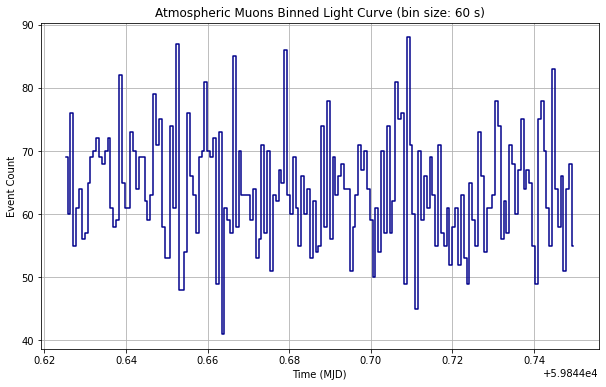

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from km3io import OfflineReader
from astropy.time import Time

def get_utc_timeslice(offline_object):
    """
    Calculate UTC time of the timeslices where the events were put based on input data.
    """
    tsec = offline_object.t_sec
    tns = offline_object.t_ns
    S_TO_NS = np.uint64(1e9)
    times = tsec + tns / S_TO_NS
    astropy_times = Time(tsec, tns / S_TO_NS, format="unix")
    return times, astropy_times

def load_multiple_files(folder_path, filenames):
    """Load multiple ROOT files and extract event times."""
    all_times = []
    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        offline_file = OfflineReader(file_path)
        times, _ = get_utc_timeslice(offline_file)
        all_times.extend(times)
    return np.array(all_times)

def plot_binned_light_curve(mjd_times, title_prefix, bin_size_seconds=60):
    """Plot a binned light curve for the given event times."""
    if len(mjd_times) == 0:
        print("No events to plot.")
        return
    
    start_time, end_time = np.min(mjd_times), np.max(mjd_times)
    bin_size_days = bin_size_seconds / (24 * 3600)  # Convert seconds to days
    num_bins = int((end_time - start_time) / bin_size_days)
    
    event_counts, bin_edges = np.histogram(mjd_times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    
    plt.figure(figsize=(10, 6))
    plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue')
    plt.xlabel("Time (MJD)")
    plt.ylabel("Event Count")
    plt.title(f"{title_prefix} Binned Light Curve (bin size: {bin_size_seconds} s)")
    plt.grid()
    plt.show()

# Example usage
folder_path = "/home/wecapstor3/capn/capn107h/atm_muons"
filenames = ["mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.1.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.2.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.3.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.4.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.5.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.6.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.7.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.8.root"
             ]  # Add more files as needed
filenames = ["mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aanet.1.root"]
#filenames = ["mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.1.root","mcv8.1.mupage_tuned_100G.sirene.jterbr00013289.jchain.aashower.12.root","mcv8.1.mupage_tuned_100G.sirene.jterbr00013290.jchain.aashower.23.root"]

event_times = load_multiple_files(folder_path, filenames)
astropy_event_times = Time(event_times, format="unix")
mjd_times = astropy_event_times.mjd

plot_binned_light_curve(mjd_times, "Atmospheric Muons", bin_size_seconds=60)


[59921.00248345 59921.00254025 59921.00254486 ... 59932.2509325
 59932.25102641 59932.25153655]


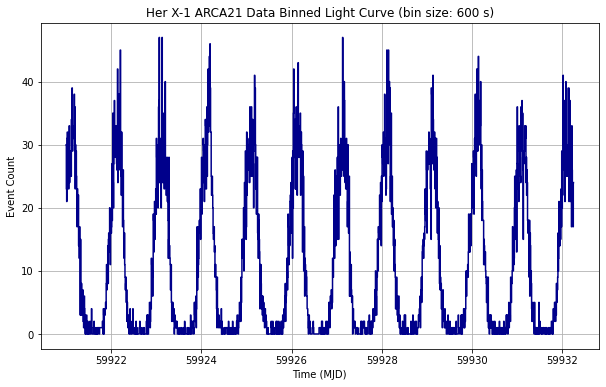

In [14]:
from astropy.io.misc.hdf5 import read_table_hdf5

h5_path = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/datav8.1.1.jchain.aashower.00014_combined_eventlist_126174events.hdf5"
h5_path = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/datav8.1.1.jchain.aashower.00014_combined_eventlist_18024events.hdf5"
file = read_table_hdf5(h5_path)
event_times = file['time']
astropy_event_times = Time(event_times, format="unix")
mjd_times = astropy_event_times.mjd

print(mjd_times)
plot_binned_light_curve(mjd_times, "Her X-1 ARCA21 Data", bin_size_seconds=600)



In [7]:
print(astropy_event_times.min())
print(astropy_event_times.max())
print(astropy_event_times.max()-astropy_event_times.min())

1663858800.1056628
1663869599.7715294
0.12499613271543275


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from km3io import OfflineReader
from km3io import tools
from astropy.time import Time

def dir_to_spherical(tracks):
    """
    Convert directional coordinates (x, y, z) to spherical coordinates (theta, phi).

    Parameters
    ----------
    tracks : numpy.array
        Array containing track information, OfflineReader.tracks object

    Returns
    -------
    tuple
        Tuple containing spherical coordinates (theta, phi).
    """
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def neutrino_to_source_direction(phi, theta, radian=True):
    """Flip the direction.

    Parameters
    ----------
    phi, theta: neutrino direction
    radian: bool [default=True]
        receive + return angles in radian? (if false, use degree)

    """
    phi = np.atleast_1d(phi).copy()
    theta = np.atleast_1d(theta).copy()
    if not radian:
        phi *= np.pi / 180
        theta *= np.pi / 180
    assert np.all(phi <= 2 * np.pi)
    assert np.all(theta <= np.pi)
    azimuth = (phi + np.pi) % (2 * np.pi)
    zenith = np.pi - theta
    if not radian:
        azimuth *= 180 / np.pi
        zenith *= 180 / np.pi
    return azimuth, zenith

def get_utc_timeslice(offline_object):
    """
    Calculate UTC time of the timeslices where the events were put based on input data.
    """
    tsec = offline_object.t_sec
    tns = offline_object.t_ns
    S_TO_NS = np.uint64(1e9)
    times = tsec + tns / S_TO_NS
    astropy_times = Time(tsec, tns / S_TO_NS, format="unix")
    return times, astropy_times

def load_multiple_files(folder_path, filenames): 
    """Load multiple ROOT files and extract event times, energies, and directions."""
    all_times = []
    all_energies = []
    all_thetas = []
    all_phis = []
    all_zeniths = []
    all_azimuths = []

    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        offline_file = OfflineReader(file_path)

        # Get event times
        times, _ = get_utc_timeslice(offline_file)
        all_times.extend(times)

        # Get energy and directional data
        mu = offline_file.mc_trks[:, 0]  # First track for each event
        theta, phi = dir_to_spherical(mu)
        energy = mu.E # Assuming the energy attribute exists

        all_energies.extend(energy)
        all_thetas.extend(theta)
        all_phis.extend(phi)

        all_azimuths, all_zeniths = neutrino_to_source_direction(all_phis, all_thetas, radian=True)

    return np.array(all_times), np.array(all_energies),np.array(all_thetas), np.array(all_phis), np.array(all_zeniths), np.array(all_azimuths)


In [27]:
folder_path = "/home/wecapstor3/capn/capn107h/atm_muons"
filenames = ["mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.1.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.2.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.3.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.4.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.5.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.6.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.7.root",  
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00013288.jchain.aashower.8.root",

             ]  # Add more files as needed

filenames = ["mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6034.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6035.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6036.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6037.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6038.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6039.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6040.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6041.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6042.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014177.jchain.aanet.6043.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6045.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6046.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6047.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6048.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6049.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6050.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6051.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6052.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6053.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014178.jchain.aanet.6054.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6056.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6057.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6058.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6059.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6060.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6061.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6062.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6063.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6064.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014179.jchain.aanet.6065.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6067.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6068.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6069.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6070.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6071.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6072.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6073.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6074.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6075.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014180.jchain.aanet.6076.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6078.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6079.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6080.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6081.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6082.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6083.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6084.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6085.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6086.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014181.jchain.aanet.6087.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6089.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6090.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6091.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6092.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6093.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6094.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6095.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6096.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6097.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014182.jchain.aanet.6098.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6100.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6101.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6102.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6103.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6104.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6105.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6106.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6107.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6108.root",
             "mcv8.1.mupage_tuned_100G.sirene.jterbr00014183.jchain.aanet.6109.root"
             ]

time, energy, theta, phi, zenith, azimuth = load_multiple_files(folder_path,filenames)

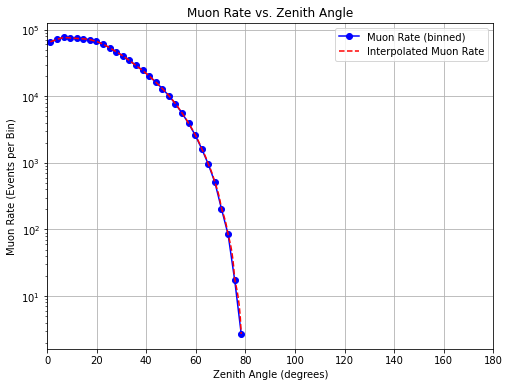

14887.814321739215


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_muon_rate_vs_zenith(zeniths, num_bins=30, normalize=True):
    zenith_degrees = np.degrees(zeniths)

    # Create histogram
    counts, bin_edges = np.histogram(zenith_degrees, bins=num_bins, density=False)

    # Compute bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Apply solid angle correction if needed
    if normalize:
        bin_widths = np.diff(bin_edges)
        solid_angle_correction = np.sin(np.radians(bin_centers)) * bin_widths
        counts = counts / solid_angle_correction

    # Handle zero values to avoid log(0) issues
    counts[counts == 0] = np.nan

    # Interpolation function
    valid_indices = ~np.isnan(counts)  # Exclude NaN values
    #interp_func = interp1d(bin_centers[valid_indices], counts[valid_indices], kind='cubic', fill_value="extrapolate")
    interp_func = interp1d(bin_centers[valid_indices], counts[valid_indices], kind='linear', fill_value="extrapolate")

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, counts, marker='o', linestyle='-', label="Muon Rate (binned)", color='blue')
    
    # Smooth interpolated curve
    fine_zeniths = np.linspace(bin_centers.min(), bin_centers.max(), 200)
    plt.plot(fine_zeniths, interp_func(fine_zeniths), linestyle='--', color='red', label="Interpolated Muon Rate")

    plt.xlabel("Zenith Angle (degrees)")
    plt.ylabel("Muon Rate (Events per Bin)")
    plt.title("Muon Rate vs. Zenith Angle")
    plt.xlim([0, 180])
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.show()

    return interp_func  # Return the interpolation function for future use

# Example Usage:
interp_muon_rate = plot_muon_rate_vs_zenith(zenith)
print(interp_muon_rate(45))  # Get interpolated muon rate at 45 degrees


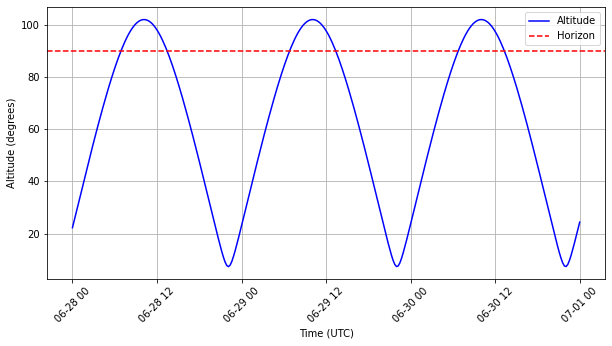

Times: ['2023-06-28 00:00:00.000' '2023-06-28 00:14:26.890'
 '2023-06-28 00:28:53.779' '2023-06-28 00:43:20.669'
 '2023-06-28 00:57:47.559']
Zenith Angles: [22.22991158 24.86743048 27.52223021 30.18572161 32.8516043 ]


In [46]:
import numpy as np
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import astropy.units as u
from h5py import File

def get_source_zenith_over_time(source_file, detector_location, observation_date, num_days=1, num_points=300):

    # Load source coordinates
    with File(source_file, 'r') as f:
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    # Compute time range for multiple days
    start_time = Time(observation_date)
    times = start_time + np.linspace(0, num_days * 24, num_points) * u.hour  # Sampling over multiple days

    # Convert to AltAz frame
    altaz_frame = AltAz(obstime=times, location=detector_location)
    source_altaz = source_coord.transform_to(altaz_frame)

    # Compute zenith angle (zenith = 90° - altitude)
    zenith_angles = 90 - source_altaz.alt.deg


    # Plot altitude vs. time (multiple days)
    plt.figure(figsize=(10, 5))
    plt.plot(times.datetime, zenith_angles, label="Altitude", c='b')
    plt.axhline(90, color='r', linestyle='--', label='Horizon')
    plt.xlabel("Time (UTC)")
    plt.ylabel("Altitude (degrees)")
    plt.legend()
    #plt.title(f"Visibility of {source_name} from {start_time.iso} to {end_time.iso}")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()


    return times, zenith_angles

# Example usage
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Her_X-1.h5"
detector_location = EarthLocation(lat=42.6*u.deg, lon=6.0*u.deg, height=-2475*u.m)  # Example for ARCA
observation_date = "2023-06-28"
num_days = 3

times, zenith_angles = get_source_zenith_over_time(source_file, detector_location, observation_date, num_days)

# Print first few values
print("Times:", times[:5])
print("Zenith Angles:", zenith_angles[:5])


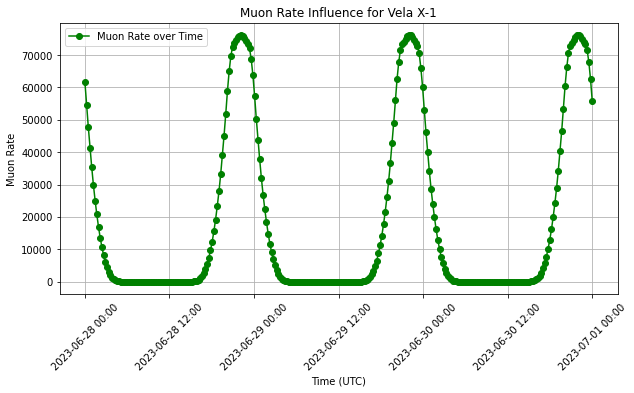

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates

def plot_muon_rate_over_time(zenith_angles, timestamps, interp_func, source_name):
    """
    Plots muon rate over time using UTC timestamps on the x-axis.

    Parameters:
    - zenith_angles: Array of zenith angles over time.
    - timestamps: Array of timestamps corresponding to each zenith angle (in UTC).
    - interp_func: Interpolated muon rate function.
    """

    # Convert timestamps to Astropy Time object for UTC handling
    time_utc = Time(timestamps, format='unix').datetime  # Convert UNIX timestamps to datetime

    # Calculate muon rates
    muon_rates = interp_func(zenith_angles)

    

    # Plot muon rate over time
    plt.figure(figsize=(10, 5))
    plt.plot(time_utc, muon_rates, marker='o', linestyle='-', color='green', label="Muon Rate over Time")

    # Formatting x-axis for UTC timestamps
    plt.xlabel("Time (UTC)")
    plt.ylabel("Muon Rate")
    plt.title(f"Muon Rate Influence for {source_name}")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))  # Format x-axis labels
    plt.xticks(rotation=45)  # Rotate labels for readability
    plt.grid(True)
    plt.legend()
    plt.show()

    return muon_rates

# Example Usage:
# Assuming `zenith_angles` is given, and `timestamps` contains corresponding UNIX timestamps
muon_rates_over_time = plot_muon_rate_over_time(zenith_angles, times, interp_muon_rate, "Vela X-1")


In [16]:
T = 24*3600
f = 1/T
f


1.1574074074074073e-05

## Visualizing Injected Signal

In [10]:
import h5py as h5py
import re
import numpy as np
from astropy.time import Time, TimeDelta
from astropy.timeseries import TimeSeries
import astropy.units as u
from plens.PulseModel import MVMD, sinusoid

# PLENS Imports
import plens.EventList as EL
import plens.antares_hdf5
import plens.antares_hdf5 as antares_hdf5

from stingray import EventList, Lightcurve
import warnings
import matplotlib.pyplot as plt

plt.style.use('default')


def plot_simulated_signal(lc_original, new_event_times, frequency, num_cycles=5):
    """
    Plots the pure simulated signal and overlays the actual injected event times.
    
    Parameters:
        lc_original : Lightcurve
            Light curve of the pure simulated signal.
        new_event_times : np.array
            Injected event times (overlaid as vertical lines).
        num_cycles : int, optional
            Number of signal periods to display (default is 5).
    """


    plt.figure(figsize=(10, 5))

    # Calculate period from frequency
    # frequency = 1 / np.median(np.diff(lc_original.time))  # Approximate frequency
    period = 1 / frequency  # Period of the signal

    # Define the time range to plot
    t_min = lc_original.time[0]
    t_max = t_min + num_cycles * period

    # Mask to select data in the desired time range
    mask = (lc_original.time >= t_min) & (lc_original.time <= t_max)

    plt.plot(lc_original.time[mask], lc_original.counts[mask], drawstyle='steps-mid', lw=3, label="Simulated Signal", color='darkorange')

    # Overlay injected event times within the time range
    for event in new_event_times:
        if t_min <= event <= t_max:
            plt.axvline(event, color='k', linestyle='--', alpha=0.6, label='Injected Events' if event == new_event_times[0] else None)

    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.title(f"Simulated Signal with Injected Event Times ({num_cycles} cycles)")
    plt.legend(['Simulated Signal', 'Injected Events'])
    plt.grid(alpha=0.5)
    plt.show()


def plot_data_comparison(lc_initial, lc_injected):
    """
    Plots a comparison between the initial dataset and the injected light curve.
    
    Parameters:
        lc_initial : Lightcurve
            Light curve of the original data before injection.
        lc_injected : Lightcurve
            Light curve of the dataset after injection.
    """
    plt.figure(figsize=(10, 5))
    
    plt.plot(lc_initial.time, lc_initial.counts, label="Initial Data", color='g', alpha = 0.5)
    plt.plot(lc_injected.time, lc_injected.counts, label="Injected Data", color='b', alpha = 0.5)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.title("Initial vs Injected Light Curve")
    plt.legend()
    plt.show()

def plot_data_comparison(lc_initial, lc_injected, frequency, num_cycles=5):
    """
    Plots a comparison between the initial dataset and the injected light curve.
    
    Parameters:
        lc_initial : Lightcurve
            Light curve of the original data before injection.
        lc_injected : Lightcurve
            Light curve of the dataset after injection.
        frequency : float
            The frequency of the signal (used to calculate the period).
        num_cycles : int, optional
            Number of signal periods to display (default is 5).
    """
    plt.figure(figsize=(10, 5))

    
    
    # Calculate period from frequency
    period = 1 / frequency  # Period of the signal

    # Define the time range to plot
    t_min = lc_initial.time[0]
    t_max = t_min + num_cycles * period

    # Mask to select data in the desired time range for both initial and injected light curves
    mask_initial = (lc_initial.time >= t_min) & (lc_initial.time <= t_max)
    mask_injected = (lc_injected.time >= t_min) & (lc_injected.time <= t_max)

    # Plot both initial and injected light curves within the specified time range
    plt.plot(lc_initial.time[mask_initial], lc_initial.counts[mask_initial], drawstyle='steps-mid', label="Initial Data", color='g', alpha=0.5)
    plt.plot(lc_injected.time[mask_injected], lc_injected.counts[mask_injected], drawstyle='steps-mid', label="Injected Data", color='b', alpha=0.5)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.title(f"Initial vs Injected Light Curve ({num_cycles} cycles)")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()



def injectSignalRedistribute(time, ratio, bin_time, pulseshape, frequency, baseline, a, phi, kappa=None, plot=False):
    """
    Injects a signal with a given pulseshape into an event list.
    
    Parameters:
        time : np.array
            Original event times.
        ratio : float
            Fraction of injected signal.
        bin_time : float
            Time bin width.
        pulseshape : str
            Type of pulse shape ('sine' or 'mvm').
        frequency : float
            Frequency of the pulse train.
        baseline : float
            Y-axis offset.
        a : float
            Amplitude.
        phi : float
            Phase.
        kappa : float, optional
            Shape parameter for MVM.
        plot : bool
            Whether to plot results.

    Returns:
        If plot=True:
            tuple: (lc_original, lc_injected, new_event_times, combined_events)
        Else:
            np.array: combined event times.
    """
    if pulseshape == 'mvm':
        counts = MVMD(time, frequency, phi, kappa, a, baseline=baseline)
    elif pulseshape == 'sine':
        counts = sinusoid(time, frequency, baseline, a, phi)

    lc_original = Lightcurve(time, counts, dt=bin_time, skip_checks=True)
    ev = EventList()
    ev.simulate_times(lc_original)
    new_event_times = ev.time

    total_events = len(time)
    num_new_events = int(round(ratio * total_events))
    num_original_events_to_keep = total_events - num_new_events

    if num_original_events_to_keep < 0:
        raise ValueError("Number of original events to keep is negative. Ensure that ratio is between 0 and 1.")

    if len(new_event_times) >= num_new_events:
        indices_to_keep_new = np.random.choice(len(new_event_times), num_new_events, replace=False)
        new_event_times = new_event_times[indices_to_keep_new]
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), num_new_events, replace=True)
        new_event_times = new_event_times[indices_to_keep_new]

    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_events = time[indices_to_keep_original]
    combined_events = np.sort(np.concatenate((remaining_original_events, new_event_times)))

    lc_injected = Lightcurve(combined_events, np.ones_like(combined_events), dt=bin_time, skip_checks=True)

    if plot:
        return lc_original, lc_injected, new_event_times, combined_events
    else:
        return combined_events
    

def injectSignalRedistributeHighRes(time, ratio, bin_time, pulseshape, frequency, baseline, a, phi, kappa=None, plot=False):
    """
    Injects a signal with a given pulseshape into an event list.

    Parameters:
        time : np.array
            Original event times.
        ratio : float
            Fraction of injected signal.
        bin_time : float
            Time bin width.
        pulseshape : str
            Type of pulse shape ('sine' or 'mvm').
        frequency : float
            Frequency of the pulse train.
        baseline : float
            Y-axis offset.
        a : float
            Amplitude.
        phi : float
            Phase.
        kappa : float, optional
            Shape parameter for MVM.
        plot : bool
            Whether to plot results.

    Returns:
        If plot=True:
            tuple: (lc_original, lc_injected, new_event_times, combined_events)
        Else:
            np.array: combined event times.
    """
    # Create a high-resolution time grid independent of `time`
    high_res_time = np.arange(time.min(), time.max(), bin_time / 10)  # 10x finer resolution

    # Generate smooth signal counts
    if pulseshape == 'mvm':
        counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
    elif pulseshape == 'sine':
        counts = sinusoid(high_res_time, frequency, baseline, a, phi)

    # Generate a smooth light curve
    lc_original = Lightcurve(high_res_time, counts, dt=bin_time / 10, skip_checks=True)

    # Simulate event times from the smooth light curve
    ev = EventList()
    ev.simulate_times(lc_original)
    new_event_times = ev.time

    # Determine how many events to keep
    total_events = len(time)
    num_new_events = int(round(ratio * total_events))
    num_original_events_to_keep = total_events - num_new_events

    if num_original_events_to_keep < 0:
        raise ValueError("Number of original events to keep is negative. Ensure that ratio is between 0 and 1.")

    # Randomly sample the desired number of injected events
    if len(new_event_times) >= num_new_events:
        indices_to_keep_new = np.random.choice(len(new_event_times), num_new_events, replace=False)
        new_event_times = new_event_times[indices_to_keep_new]
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), num_new_events, replace=True)
        new_event_times = new_event_times[indices_to_keep_new]

    # Keep a subset of original events
    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_events = time[indices_to_keep_original]

    # Combine original and injected event times
    combined_events = np.sort(np.concatenate((remaining_original_events, new_event_times)))

    # Generate light curve for injected event list
    time_bins = np.arange(time.min(), time.max(), bin_time)
    
    counts_combined, _ = np.histogram(combined_events, bins=time_bins)
    time_centers = (time_bins[:-1] + time_bins[1:]) / 2
    lc_injected = Lightcurve(time_centers, counts_combined, dt=bin_time*100, skip_checks=True)

    if plot:
        return lc_original, lc_injected, new_event_times, combined_events
    else:
        return combined_events


In [11]:
def create_binned_light_curve(mjd_times, bin_size_seconds=60):
    """Plot a binned light curve for the given event times."""
    if len(mjd_times) == 0:
        print("No events to plot.")
        return
    
    start_time, end_time = np.min(mjd_times), np.max(mjd_times)
    bin_size_days = bin_size_seconds / (24 * 3600)  # Convert seconds to days
    num_bins = int((end_time - start_time) / bin_size_days)
    
    event_counts, bin_edges = np.histogram(mjd_times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    
    return bin_centers, event_counts


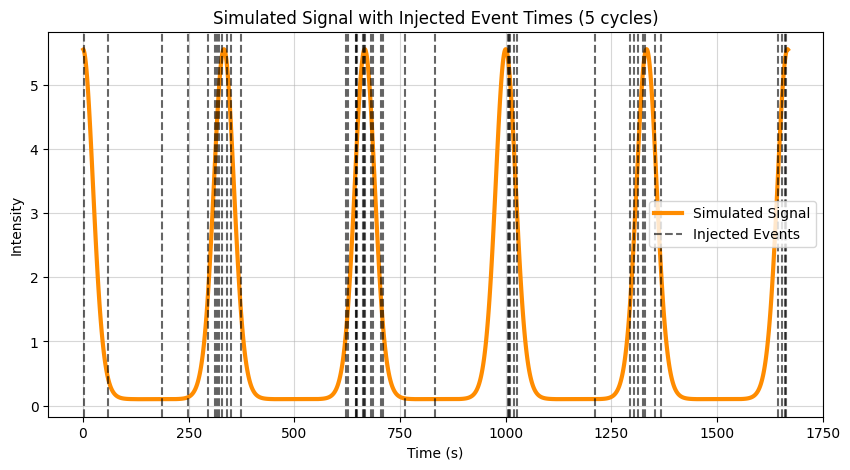

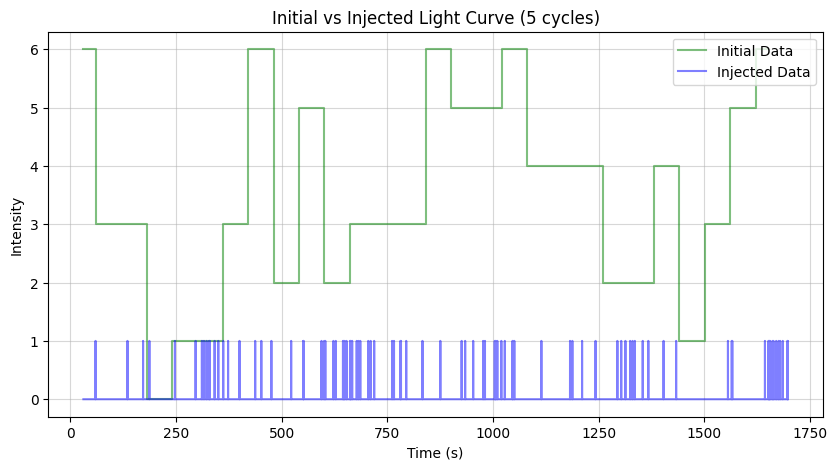

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import Lightcurve
from astropy.time import Time
bin_time = 60
# Generate random event times over one day
np.random.seed(42)  # For reproducibility
num_events = 5000  # Adjust this to simulate different densities
random_times = np.sort(np.random.uniform(0, 86400, num_events))  # 86400 seconds in a day

# Define time bins
time_bins = np.arange(random_times.min(), random_times.max(), bin_time)

# Create histogram to count events per bin
counts, bin_edges = np.histogram(random_times, bins=time_bins)

# Compute time bin centers
time_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Now create the light curve
lc_initial = Lightcurve(time=time_centers, counts=counts, dt=50, skip_checks=True)


# Define injection parameters
frequency = 3e-3  # Hz (one cycle every ~333 seconds)
ratio = 0.5  # Signal-to-noise ratio
bin_time = 0.1  # Bin width in seconds
pulseshape = 'mvm'  # Use a sine signal
baseline = 0.1  # No vertical offset
a = 1.  # Amplitude
phi = 0.  # Initial phase
plot = True  # Enable plotting
kappa = 5.0

# Inject signal
lc_original, lc_injected, new_event_times, combined_events = injectSignalRedistributeHighRes(
    random_times, ratio, bin_time, pulseshape, frequency, baseline, a, phi, plot=plot, kappa = kappa
)
plot_simulated_signal(lc_original, new_event_times, frequency)#
plot_data_comparison(lc_initial, lc_injected, frequency)

bin_center, event_counts = create_binned_light_curve(random_times)